# DIAMOND CRISTAL CLEAN | Final Scientific Decision Notebook for AAD

Este notebook é o tribunal final do artigo de Detecção de Anomalias Acústicas (AAD) em chão de fábrica.

Ele foi desenhado com postura DCASE: prevenção rígida de vazamento, avaliação multi-fonte, ablação explícita, métricas industriais, custo Edge/TinyML e relatório final auditável.

**Hipótese central testada**

> O Canal DWT-RPCA aplicado à componente esparsa de transientes pode capturar assinaturas acústicas impulsivas com menor custo computacional que CWT/HHT isolados, preservando robustez para Edge Computing quando validado por ablação, SNR, LOSO, teste cego e pAUC@0.1.

**Pipeline candidato**

`áudio bruto -> HHT+UKF -> janelas -> Mel/MFCC/RPCA/NMF/DWT -> Tiny-AST auxiliar -> XGBoost/GMM/Mahalanobis/Isolation Forest -> calibração -> XAI`

**Saídas obrigatórias**

Todos os CSVs, gráficos e relatórios são salvos em `outputs/diamond_cristal_clean`.

## Leitura do protocolo

O notebook tem 27 passos numerados, alinhados às técnicas exigidas no protocolo.

As células são defensivas: quando uma biblioteca ou dataset não está disponível, o notebook registra o problema, usa fallback funcional ou exporta uma tabela vazia com schema conhecido. Isso evita quebrar a cadeia inteira e preserva auditabilidade.

Para uma execução completa, configure os caminhos via variáveis de ambiente ou ajuste a célula de configuração:

- `AAD_PROJECT_ROOT`
- `AAD_DRIVE_AUDIO_ROOT`
- `AAD_KAGGLE_ROOT`
- `AAD_DCASE_ROOT`
- `AAD_MIMII_ROOT`
- `AAD_BLIND_ROOTS`
- `AAD_OE_ROOTS`

**Preset de velocidade**

Por padrão o notebook roda em `AAD_EXECUTION_PRESET=fast_complete`: mantém os áudios descobertos de DCASE, MIMII, Kaggle e próprios, preserva o protocolo de ablação, LOSO, multi-fonte, SNR e CSVs finais, mas acelera as últimas células limitando grades repetitivas, modelos por suite e macro-janelas. Para a execução final do artigo, use `AAD_EXECUTION_PRESET=full`.

In [ ]:
# ============================================================
# Configuração central, reprodutibilidade e saídas
# ============================================================
from __future__ import annotations

import gc
import json
import math
import os
import random
import time
import zipfile
import warnings
from collections import OrderedDict, defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Callable, Iterable, Optional

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

RANDOM_STATE = int(os.getenv("AAD_RANDOM_STATE", "42"))
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

EXECUTION_PRESET = os.getenv("AAD_EXECUTION_PRESET", "fast_complete").strip().lower()
FAST_COMPLETE = EXECUTION_PRESET in {"fast", "fast_complete", "quick", "dev", "smoke"}


def preset_value(fast_value: Any, full_value: Any) -> str:
    return str(fast_value if FAST_COMPLETE else full_value)


def env_bool(name: str, default: bool) -> bool:
    return os.getenv(name, "1" if default else "0").strip().lower() in {"1", "true", "yes", "sim"}


@dataclass
class DiamondConfig:
    execution_preset: str = EXECUTION_PRESET  # fast_complete | full
    project_root: Path = Path(os.getenv("AAD_PROJECT_ROOT", Path.cwd()))
    output_root_name: str = "outputs/diamond_cristal_clean"
    target_sr: int = int(os.getenv("AAD_TARGET_SR", "16000"))
    mono: bool = True
    window_sec: float = float(os.getenv("AAD_WINDOW_SEC", "1.0"))
    hop_sec: float = float(os.getenv("AAD_HOP_SEC", "0.5"))
    use_all_available_audio: bool = os.getenv("AAD_USE_ALL_AVAILABLE_AUDIO", "1").strip().lower() in {"1", "true", "yes", "sim"}
    max_files_per_source_label: int = int(os.getenv("AAD_MAX_FILES_PER_SOURCE_LABEL", "0"))  # 0 = sem cap
    max_windows_per_file: int = int(os.getenv("AAD_MAX_WINDOWS_PER_FILE", "0"))  # 0 = sem cap
    max_blind_files_per_source_label: int = int(os.getenv("AAD_MAX_BLIND_FILES_PER_SOURCE_LABEL", "0"))
    supervised_test_size: float = float(os.getenv("AAD_SUPERVISED_TEST_SIZE", "0.25"))
    unsup_eval_size: float = float(os.getenv("AAD_UNSUP_EVAL_SIZE", "0.30"))
    pauc_max_fpr: float = float(os.getenv("AAD_PAUC_MAX_FPR", "0.10"))
    score_w_f1: float = float(os.getenv("AAD_SCORE_W_F1", "0.30"))
    score_w_auc: float = float(os.getenv("AAD_SCORE_W_AUC", "0.25"))
    score_w_pauc: float = float(os.getenv("AAD_SCORE_W_PAUC", "0.45"))
    score_cost_weight: float = float(os.getenv("AAD_SCORE_COST_WEIGHT", "0.20"))
    score_latency_ref_ms: float = float(os.getenv("AAD_SCORE_LATENCY_REF_MS", "5.0"))
    score_memory_ref_mb: float = float(os.getenv("AAD_SCORE_MEMORY_REF_MB", "32.0"))
    n_mels: int = int(os.getenv("AAD_N_MELS", "64"))
    n_mfcc: int = int(os.getenv("AAD_N_MFCC", "13"))
    stft_n_fft: int = int(os.getenv("AAD_STFT_N_FFT", "1024"))
    stft_hop: int = int(os.getenv("AAD_STFT_HOP", "256"))
    rpca_max_iter: int = int(os.getenv("AAD_RPCA_MAX_ITER", "8"))
    rpca_lambda_scale: float = float(os.getenv("AAD_RPCA_LAMBDA_SCALE", "1.0"))
    nmf_components: int = int(os.getenv("AAD_NMF_COMPONENTS", "8"))
    nmf_max_iter: int = int(os.getenv("AAD_NMF_MAX_ITER", "400"))
    dwt_wavelet: str = os.getenv("AAD_DWT_WAVELET", "db4")
    dwt_level: int = int(os.getenv("AAD_DWT_LEVEL", "4"))
    mixup_ratio: float = float(os.getenv("AAD_MIXUP_RATIO", "0.25"))
    mixup_lambda: float = float(os.getenv("AAD_MIXUP_LAMBDA", "0.35"))
    mixup_weight: float = float(os.getenv("AAD_MIXUP_WEIGHT", "0.55"))
    domain_mixup_ratio: float = float(os.getenv("AAD_DOMAIN_MIXUP_RATIO", "0.25"))
    domain_mixup_weight: float = float(os.getenv("AAD_DOMAIN_MIXUP_WEIGHT", "0.45"))
    oe_weight: float = float(os.getenv("AAD_OE_WEIGHT", "0.35"))
    snr_grid: tuple[int, ...] = (-6, 0, 6)
    run_snr_grid: bool = env_bool("AAD_RUN_SNR_GRID", True)
    snr_max_files_per_source_label: int = int(os.getenv("AAD_SNR_MAX_FILES_PER_SOURCE_LABEL", preset_value(6, 0)))  # 0 = todos
    enable_tiny_ast: bool = os.getenv("AAD_ENABLE_TINY_AST", "0").strip().lower() in {"1", "true", "yes", "sim"}
    tiny_ast_aux_mode: str = os.getenv("AAD_TINY_AST_AUX_MODE", "proxy").strip().lower()  # precomputed | proxy | off
    tiny_ast_embeddings_csv: str = os.getenv("AAD_TINY_AST_EMBEDDINGS_CSV", "")
    tiny_ast_freq_patches: int = int(os.getenv("AAD_TINY_AST_FREQ_PATCHES", "8"))
    tiny_ast_time_patches: int = int(os.getenv("AAD_TINY_AST_TIME_PATCHES", "4"))
    enable_optional_heavy: bool = env_bool("AAD_ENABLE_OPTIONAL_HEAVY", False)
    include_cwt_features: bool = env_bool("AAD_INCLUDE_CWT_FEATURES", True)
    supervised_model_set: str = os.getenv("AAD_SUPERVISED_MODEL_SET", "core" if FAST_COMPLETE else "all").strip().lower()
    unsup_model_set: str = os.getenv("AAD_UNSUP_MODEL_SET", "core" if FAST_COMPLETE else "all").strip().lower()
    max_train_rows_per_suite: int = int(os.getenv("AAD_MAX_TRAIN_ROWS_PER_SUITE", preset_value(900, 0)))
    max_test_rows_per_suite: int = int(os.getenv("AAD_MAX_TEST_ROWS_PER_SUITE", preset_value(450, 0)))
    domain_arena_max_configs: int = int(os.getenv("AAD_DOMAIN_ARENA_MAX_CONFIGS", preset_value(14, 0)))
    run_macro_window_grid: bool = env_bool("AAD_RUN_MACRO_WINDOW_GRID", not FAST_COMPLETE)


CFG = DiamondConfig()

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    drive = None
    IN_COLAB = False

if IN_COLAB and os.getenv("AAD_MOUNT_DRIVE", "1").strip().lower() in {"1", "true", "yes", "sim"}:
    drive.mount("/content/drive", force_remount=False)

if os.getenv("AAD_PROJECT_ROOT", "").strip():
    PROJECT_ROOT = Path(os.getenv("AAD_PROJECT_ROOT", "")).expanduser().resolve()
elif IN_COLAB:
    PROJECT_ROOT = Path("/content/aad_arquitetura_campea").resolve()
else:
    local_root_27 = Path("/Users/emanoelspanhol/Downloads/V2 benchmarking 2")
    PROJECT_ROOT = (local_root_27 if local_root_27.exists() else Path.cwd()).resolve()

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
CFG.project_root = PROJECT_ROOT
OUTPUT_DIR = PROJECT_ROOT / CFG.output_root_name
PLOT_DIR = OUTPUT_DIR / "plots"
CACHE_DIR = OUTPUT_DIR / "cache"
for p in [OUTPUT_DIR, PLOT_DIR, CACHE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("RANDOM_STATE:", RANDOM_STATE)
print(json.dumps({k: str(v) for k, v in asdict(CFG).items()}, indent=2, ensure_ascii=False))

Mounted at /content/drive
PROJECT_ROOT: /content/aad_arquitetura_campea
OUTPUT_DIR: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean
RANDOM_STATE: 42
{
  "execution_preset": "fast_complete",
  "project_root": "/content/aad_arquitetura_campea",
  "output_root_name": "outputs/diamond_cristal_clean",
  "target_sr": "16000",
  "mono": "True",
  "window_sec": "1.0",
  "hop_sec": "0.5",
  "use_all_available_audio": "True",
  "max_files_per_source_label": "0",
  "max_windows_per_file": "0",
  "max_blind_files_per_source_label": "0",
  "supervised_test_size": "0.25",
  "unsup_eval_size": "0.3",
  "pauc_max_fpr": "0.1",
  "score_w_f1": "0.3",
  "score_w_auc": "0.25",
  "score_w_pauc": "0.45",
  "score_cost_weight": "0.2",
  "score_latency_ref_ms": "5.0",
  "score_memory_ref_mb": "32.0",
  "n_mels": "64",
  "n_mfcc": "13",
  "stft_n_fft": "1024",
  "stft_hop": "256",
  "rpca_max_iter": "8",
  "rpca_lambda_scale": "1.0",
  "nmf_components": "8",
  "nmf_max_iter": "400",
  "dwt_wavele

In [ ]:
# ============================================================
# Imports opcionais, fallbacks e utilitários globais
# ============================================================
import importlib.util

try:
    from IPython.display import Markdown, display
except Exception:
    Markdown = lambda text: text
    def display(obj):
        print(obj)

def has_module(name: str) -> bool:
    return importlib.util.find_spec(name) is not None

MISSING_PACKAGES: list[str] = []

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="talk")
    plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 220})
except Exception as exc:
    MISSING_PACKAGES.append(f"matplotlib/seaborn: {exc}")
    plt = None
    sns = None

try:
    import soundfile as sf
except Exception as exc:
    sf = None
    MISSING_PACKAGES.append(f"soundfile: {exc}")

try:
    import librosa
    import librosa.display
except Exception as exc:
    librosa = None
    MISSING_PACKAGES.append(f"librosa: {exc}")

try:
    from scipy import signal as scipy_signal
    from scipy import stats
except Exception as exc:
    scipy_signal = None
    stats = None
    MISSING_PACKAGES.append(f"scipy: {exc}")

try:
    import pywt
except Exception as exc:
    pywt = None
    MISSING_PACKAGES.append(f"pywt: {exc}")

try:
    from PyEMD import EMD
except Exception as exc:
    EMD = None
    MISSING_PACKAGES.append(f"PyEMD/EMD-signal: {exc}")

try:
    from filterpy.kalman import MerweScaledSigmaPoints
    from filterpy.kalman import UnscentedKalmanFilter as UKF
except Exception as exc:
    MerweScaledSigmaPoints = None
    UKF = None
    MISSING_PACKAGES.append(f"filterpy: {exc}")

try:
    from sklearn.base import BaseEstimator, clone
    from sklearn.covariance import LedoitWolf
    from sklearn.decomposition import NMF
    from sklearn.ensemble import IsolationForest, RandomForestClassifier
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (
        accuracy_score,
        average_precision_score,
        confusion_matrix,
        f1_score,
        precision_score,
        recall_score,
        roc_auc_score,
        roc_curve,
    )
    from sklearn.mixture import GaussianMixture
    from sklearn.model_selection import GroupShuffleSplit
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import MinMaxScaler, StandardScaler
    from sklearn.svm import OneClassSVM
except Exception as exc:
    raise RuntimeError("scikit-learn é obrigatório para este notebook de decisão.") from exc

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception as exc:
    XGBClassifier = None
    HAS_XGBOOST = False
    MISSING_PACKAGES.append(f"xgboost: {exc}")

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    HAS_TORCH = True
except Exception as exc:
    torch = None
    nn = None
    optim = None
    DataLoader = None
    TensorDataset = None
    HAS_TORCH = False
    MISSING_PACKAGES.append(f"torch: {exc}")

if MISSING_PACKAGES:
    print("Pacotes ausentes ou opcionais indisponíveis:")
    for item in MISSING_PACKAGES:
        print(" -", item)
else:
    print("Todos os pacotes opcionais principais foram importados.")


def log_step(msg: str) -> None:
    print(f"[DIAMOND] {time.strftime('%H:%M:%S')} | {msg}")


def safe_stat(fn: Callable, values: np.ndarray, default: float = 0.0) -> float:
    try:
        arr = np.asarray(values, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            return float(default)
        out = fn(arr)
        if np.asarray(out).size != 1:
            return float(default)
        out = float(out)
        return out if np.isfinite(out) else float(default)
    except Exception:
        return float(default)


def entropy_safe(values: np.ndarray, bins: int = 32) -> float:
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return 0.0
    hist, _ = np.histogram(arr, bins=bins, density=False)
    p = hist.astype(float)
    p = p / max(p.sum(), 1.0)
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum()) if p.size else 0.0


def ensure_csv(path: Path, columns: list[str]) -> None:
    if not path.exists():
        pd.DataFrame(columns=columns).to_csv(path, index=False)


def save_df(df: pd.DataFrame, name: str) -> Path:
    path = OUTPUT_DIR / name
    df.to_csv(path, index=False)
    print(f"CSV salvo: {path}")
    return path


def save_plot(name: str) -> Optional[Path]:
    if plt is None:
        return None
    path = PLOT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print(f"Figura salva: {path}")
    return path

Pacotes ausentes ou opcionais indisponíveis:
 - PyEMD/EMD-signal: No module named 'PyEMD'
 - filterpy: No module named 'filterpy'


## 1. Carregamento dos áudios multi-fonte

Fontes esperadas: áudios próprios, Kaggle, DCASE, MIMII, Drive cego ou pastas equivalentes.

O carregamento não decide treino/teste. Ele apenas cria um catálogo auditável com rótulo, domínio, máquina, origem e flags candidatas.

In [ ]:
AUDIO_EXTS = {".wav", ".flac", ".ogg", ".mp3", ".aiff", ".aif"}
SIGNAL_EXTS = AUDIO_EXTS | {".csv", ".npy"}


def parse_path_list(value: str) -> list[Path]:
    return [Path(item.strip()).expanduser() for item in value.split(",") if item.strip()]


def existing_or_default_paths(env_name: str, defaults: list[Path]) -> list[Path]:
    raw = os.getenv(env_name, "").strip()
    return parse_path_list(raw) if raw else defaults


DEFAULT_DRIVE_AUDIO_ROOT = (
    Path("/content/drive/MyDrive/PROJETO APLICADO - Acoustic Anomaly Detection (AAD)/Arquivos de audio")
    if IN_COLAB else
    PROJECT_ROOT / "PROJETO APLICADO - Acoustic Anomaly Detection (AAD)" / "Arquivos de audio"
)
DRIVE_AUDIO_ROOT = Path(os.getenv("AAD_DRIVE_AUDIO_ROOT", str(DEFAULT_DRIVE_AUDIO_ROOT))).expanduser()

# Mesma convenção do notebook 27.
OWN_DATA_DIRS = existing_or_default_paths("AAD_OWN_DATA_DIRS", [
    DRIVE_AUDIO_ROOT / "normal",
    DRIVE_AUDIO_ROOT / "anomaly",
    DRIVE_AUDIO_ROOT / "anomalia",
    DRIVE_AUDIO_ROOT / "audios_proprios",
    DRIVE_AUDIO_ROOT / "proprios",
    DRIVE_AUDIO_ROOT / "meus_audios",
])
BLIND_TEST_DIRS = existing_or_default_paths("AAD_BLIND_TEST_DIRS", [
    DRIVE_AUDIO_ROOT / "teste",
    DRIVE_AUDIO_ROOT / "teste_cego",
])
OE_ROOTS = existing_or_default_paths("AAD_OE_ROOTS", [
    PROJECT_ROOT / "datasets" / "oe",
    PROJECT_ROOT / "datasets" / "external_outliers",
])

DATASETS_ROOT = Path(os.getenv("AAD_DATASETS_ROOT", str(PROJECT_ROOT / "datasets"))).expanduser()
DATASETS_ROOT.mkdir(parents=True, exist_ok=True)

KAGGLE_ZIP = Path(os.getenv("AAD_KAGGLE_ZIP", str(DRIVE_AUDIO_ROOT / "archive.zip"))).expanduser()
KAGGLE_EXTRACT_ROOT = Path(os.getenv("AAD_KAGGLE_EXTRACT_ROOT", "/content/kaggle_data" if IN_COLAB else str(DRIVE_AUDIO_ROOT / "kaggle_data"))).expanduser()
KAGGLE_ROOT = Path(os.getenv("AAD_KAGGLE_ROOT", str(DRIVE_AUDIO_ROOT / "kaggle_data" / "Dataset"))).expanduser()

DCASE_EXTRACT_ROOT = Path(os.getenv("AAD_DCASE_EXTRACT_ROOT", str(DATASETS_ROOT / "dcase2025_task2" / "dev_data"))).expanduser()
DCASE_RAW_ROOT = Path(os.getenv("AAD_DCASE_RAW_ROOT", str(DCASE_EXTRACT_ROOT / "raw"))).expanduser()
DCASE_EXTRA_ROOTS = existing_or_default_paths("AAD_DCASE_ROOTS", [
    DCASE_EXTRACT_ROOT,
    DCASE_RAW_ROOT,
    DATASETS_ROOT / "dcase2025_task2",
    DRIVE_AUDIO_ROOT / "dcase2025_task2",
    DRIVE_AUDIO_ROOT / "dcase",
])

MIMII_ROOT = Path(os.getenv("AAD_MIMII_ROOT", str(DATASETS_ROOT / "mimii"))).expanduser()
MIMII_EXTRA_ROOTS = existing_or_default_paths("AAD_MIMII_ROOTS", [
    MIMII_ROOT,
    DATASETS_ROOT / "MIMII",
    DRIVE_AUDIO_ROOT / "mimii",
    DRIVE_AUDIO_ROOT / "MIMII",
    PROJECT_ROOT / "mimii",
])
ENABLE_MIMII_SCAN = os.getenv("AAD_ENABLE_MIMII_SCAN", "1").strip().lower() in {"1", "true", "yes", "sim"}
DCASE_RECORD_ID = "15097779"
MIMII_RECORD_ID = "3384388"
DCASE_DOWNLOAD_ROOT = DATASETS_ROOT / "dcase2025_task2" / "zips"
DCASE_DOWNLOAD_ROOT.mkdir(parents=True, exist_ok=True)
DCASE_PACKAGES = [p.strip() for p in os.getenv("AAD_DCASE_PACKAGES", "dev_valve.zip,dev_bearing.zip").split(",") if p.strip()]
AUTO_DOWNLOAD_DCASE = env_bool("AAD_AUTO_DOWNLOAD_DCASE", True)
AUTO_DOWNLOAD_MIMII = env_bool("AAD_AUTO_DOWNLOAD_MIMII", True)
MIMII_PACKAGES = [p.strip() for p in os.getenv("AAD_MIMII_PACKAGES", "-6_dB_valve.zip,0_dB_valve.zip,6_dB_valve.zip").split(",") if p.strip()]
MIMII_REMOTE_SAMPLE_ENABLED = env_bool("AAD_MIMII_REMOTE_SAMPLE_ENABLED", True)
MIMII_REMOTE_SAMPLE_SIZE = int(os.getenv("AAD_MIMII_REMOTE_SAMPLE_SIZE", "500"))

PUBLIC_BENCHMARK_SOURCES = [
    item.strip() for item in os.getenv("AAD_PUBLIC_BENCHMARK_SOURCES", "Kaggle,DCASE,MIMII").split(",") if item.strip()
]

MAX_OWN_PER_LABEL = int(os.getenv("AAD_MAX_OWN_PER_LABEL", "80"))
MAX_BLIND_FILES = int(os.getenv("AAD_MAX_BLIND_FILES", "80"))
MAX_KAGGLE_PER_CLASS = int(os.getenv("AAD_MAX_KAGGLE_PER_CLASS", "120"))
MAX_DCASE_TRAIN_PER_MACHINE = int(os.getenv("AAD_MAX_DCASE_TRAIN_PER_MACHINE", "90"))
MAX_DCASE_TEST_PER_MACHINE_LABEL = int(os.getenv("AAD_MAX_DCASE_TEST_PER_MACHINE_LABEL", "60"))
MAX_MIMII_PER_LABEL = int(os.getenv("AAD_MAX_MIMII_PER_LABEL", "250"))
MAX_MIMII_TOTAL_FILES = int(os.getenv("AAD_MAX_MIMII_TOTAL_FILES", "500"))
CSV_SIGNAL_SR = int(os.getenv("AAD_CSV_SIGNAL_SR", str(CFG.target_sr)))
SUP_TARGET_NORMAL_PER_SOURCE = int(os.getenv("AAD_SUP_TARGET_NORMAL_PER_SOURCE", "1000"))
SUP_TARGET_ANOM_PER_SOURCE = int(os.getenv("AAD_SUP_TARGET_ANOM_PER_SOURCE", "500"))
UNSUP_TARGET_NORMAL_PER_SOURCE = int(os.getenv("AAD_UNSUP_TARGET_NORMAL_PER_SOURCE", "1000"))
UNSUP_TARGET_ANOM_PER_SOURCE = int(os.getenv("AAD_UNSUP_TARGET_ANOM_PER_SOURCE", "500"))
SUP_TEST_SIZE = float(os.getenv("AAD_SUP_TEST_SIZE", str(CFG.supervised_test_size)))
UNSUP_TEST_SIZE = float(os.getenv("AAD_UNSUP_TEST_SIZE", str(CFG.unsup_eval_size)))
INCLUDE_KAGGLE_BLIND = os.getenv("AAD_INCLUDE_KAGGLE_BLIND", "1").strip().lower() in {"1", "true", "yes", "sim"}
INCLUDE_DCASE_BLIND = os.getenv("AAD_INCLUDE_DCASE_BLIND", "1").strip().lower() in {"1", "true", "yes", "sim"}
INCLUDE_MIMII_BLIND = os.getenv("AAD_INCLUDE_MIMII_BLIND", "1").strip().lower() in {"1", "true", "yes", "sim"}
MAX_KAGGLE_BLIND_PER_CLASS = int(os.getenv("AAD_MAX_KAGGLE_BLIND_PER_CLASS", "16"))
MAX_DCASE_BLIND_PER_MACHINE_LABEL = int(os.getenv("AAD_MAX_DCASE_BLIND_PER_MACHINE_LABEL", "16"))
MAX_MIMII_BLIND_PER_LABEL = int(os.getenv("AAD_MAX_MIMII_BLIND_PER_LABEL", "20"))


def sample_df(df: pd.DataFrame, n: int, group_cols: list[str], seed: int = RANDOM_STATE) -> pd.DataFrame:
    if df.empty or n <= 0:
        return df
    parts = []
    for _, part in df.groupby(group_cols, dropna=False):
        parts.append(part.sample(n=min(n, len(part)), random_state=seed))
    return pd.concat(parts, ignore_index=True) if parts else df.iloc[0:0]


def label_from_text(text: str) -> Optional[int]:
    t = text.lower()
    anomaly_tokens = ["anomaly", "anomalous", "abnormal", "fault", "broken", "damage", "falha", "anomalia", "anormal", "defeito"]
    normal_tokens = ["normal", "healthy", "ok", "saudavel", "saudável", "bom"]
    if any(tok in t for tok in anomaly_tokens):
        return 1
    if any(tok in t for tok in normal_tokens):
        return 0
    return None


def mimii_snr_from_text(text: str) -> str:
    t = text.lower()
    if "-6_db" in t or "-6db" in t:
        return "-6 dB"
    if "0_db" in t or "0db" in t:
        return "0 dB"
    if "6_db" in t or "6db" in t:
        return "6 dB"
    return "outro"


def make_row(path: Path, dataset: str, source: str, machine: str, split_hint: str, label: Optional[int], group_prefix: str, is_blind: bool = False, is_oe: bool = False, snr_level: str = "natural") -> dict:
    label_value = -1 if label is None else int(label)
    return {
        "path": str(path.resolve()),
        "dataset": dataset,
        "source": source,
        "domain": source,
        "machine": machine,
        "split_hint": split_hint,
        "label": label_value,
        "label_name": "Sem rótulo" if label is None else ("Anômalo" if int(label) == 1 else "Normal"),
        "snr_level": snr_level,
        "file_name": path.name,
        "file_stem": path.stem,
        "group_id": f"{group_prefix}/{path.stem}",
        "is_blind_candidate": bool(is_blind),
        "is_oe_candidate": bool(is_oe),
    }


def kaggle_root_is_valid(root: Path) -> bool:
    root = Path(root)
    return root.exists() and all((root / folder).exists() for folder in ["Normal", "Inner Race Fault", "Outer Race Fault"])


def has_signal_files(root: Path, exts: set[str] = SIGNAL_EXTS) -> bool:
    return root.exists() and any(p.is_file() and p.suffix.lower() in exts for p in root.rglob("*"))


def zenodo_files(record_id: str) -> pd.DataFrame:
    try:
        import requests
        response = requests.get(f"https://zenodo.org/api/records/{record_id}", timeout=60)
        response.raise_for_status()
        data = response.json()
        rows = []
        for f in data.get("files", []):
            links = f.get("links", {})
            rows.append({
                "record_id": record_id,
                "key": f.get("key"),
                "size_mb": round(float(f.get("size", 0)) / 1024 / 1024, 2),
                "download_url": links.get("self") or links.get("content"),
                "checksum": f.get("checksum"),
            })
        return pd.DataFrame(rows)
    except Exception as exc:
        log_step(f"Zenodo indisponível para record {record_id}: {exc}")
        return pd.DataFrame()


def download_file(url: str, out_path: Path, chunk_size: int = 1024 * 1024) -> Optional[Path]:
    try:
        import requests
        try:
            from tqdm.auto import tqdm
        except Exception:
            tqdm = None
        out_path.parent.mkdir(parents=True, exist_ok=True)
        if out_path.exists() and out_path.stat().st_size > 0:
            log_step(f"Já existe, pulando download: {out_path.name}")
            return out_path
        with requests.get(url, stream=True, timeout=120) as r:
            r.raise_for_status()
            total = int(r.headers.get("content-length", 0))
            iterator = r.iter_content(chunk_size=chunk_size)
            if tqdm is not None:
                iterator = tqdm(iterator, total=max(1, total // chunk_size), desc=out_path.name)
            with open(out_path, "wb") as f:
                for chunk in iterator:
                    if chunk:
                        f.write(chunk)
        return out_path
    except Exception as exc:
        log_step(f"Download falhou para {out_path.name}: {exc}")
        return None


def extract_zip(zip_path: Path, extract_root: Path) -> None:
    try:
        marker = extract_root / f".extracted_{zip_path.stem}"
        if marker.exists():
            return
        extract_root.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_root)
        marker.write_text("ok")
    except Exception as exc:
        log_step(f"Extração falhou para {zip_path.name}: {exc}")


def extract_remote_zip_sample(url: str, sample_root: Path, max_files: int, seed: int = RANDOM_STATE) -> pd.DataFrame:
    try:
        from remotezip import RemoteZip
        import shutil
        try:
            from tqdm.auto import tqdm
        except Exception:
            tqdm = lambda x, **_: x
    except Exception as exc:
        if os.getenv("AAD_AUTO_INSTALL_REMOTEZIP", "1").strip().lower() in {"1", "true", "yes", "sim"}:
            try:
                import sys
                import subprocess
                log_step("Instalando `remotezip` para amostragem remota do MIMII.")
                subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "remotezip"])
                from remotezip import RemoteZip
                import shutil
                try:
                    from tqdm.auto import tqdm
                except Exception:
                    tqdm = lambda x, **_: x
            except Exception as exc2:
                log_step(f"`remotezip` indisponível; MIMII remoto não será amostrado automaticamente: {exc2}")
                return pd.DataFrame()
        else:
            log_step(f"`remotezip` indisponível; MIMII remoto não será amostrado automaticamente: {exc}")
            return pd.DataFrame()
    sample_root.mkdir(parents=True, exist_ok=True)
    manifest_path = sample_root / "_manifest.csv"
    if manifest_path.exists():
        try:
            manifest = pd.read_csv(manifest_path)
            if not manifest.empty:
                return manifest
        except Exception:
            pass
    try:
        with RemoteZip(url, initial_buffer_size=256 * 1024) as zf:
            names = [name for name in zf.namelist() if (not name.endswith("/")) and Path(name).suffix.lower() in AUDIO_EXTS]
            if not names:
                return pd.DataFrame()
            rng_local = np.random.default_rng(seed)
            picked = sorted(rng_local.choice(np.asarray(names, dtype=object), size=min(max_files, len(names)), replace=False).tolist())
            rows = []
            for member in tqdm(picked, desc=f"MIMII sample {sample_root.name}"):
                out_path = sample_root / member
                out_path.parent.mkdir(parents=True, exist_ok=True)
                if not out_path.exists():
                    with zf.open(member) as src, open(out_path, "wb") as dst:
                        shutil.copyfileobj(src, dst, length=1024 * 1024)
                rows.append({"member": member, "local_path": str(out_path), "size_bytes": out_path.stat().st_size if out_path.exists() else 0})
            manifest = pd.DataFrame(rows)
            if not manifest.empty:
                manifest.to_csv(manifest_path, index=False)
            return manifest
    except Exception as exc:
        log_step(f"Amostragem remota do MIMII falhou: {exc}")
        return pd.DataFrame()


def prepare_public_datasets_like_notebook_27() -> None:
    # DCASE: mesmo caminho e pacotes do notebook 27. Só baixa se não houver áudio local.
    if AUTO_DOWNLOAD_DCASE and not any(has_signal_files(root, AUDIO_EXTS) for root in DCASE_EXTRA_ROOTS):
        table = zenodo_files(DCASE_RECORD_ID)
        if not table.empty:
            selected = table[table["key"].isin(DCASE_PACKAGES)]
            for _, row in selected.iterrows():
                zip_path = DCASE_DOWNLOAD_ROOT / row["key"]
                got = download_file(row["download_url"], zip_path)
                if got is not None:
                    extract_zip(got, DCASE_EXTRACT_ROOT)
    # MIMII: trinca -6/0/+6 dB, preferindo amostra remota para não puxar dezenas de GB.
    if AUTO_DOWNLOAD_MIMII and ENABLE_MIMII_SCAN and not any(has_signal_files(root, AUDIO_EXTS) for root in MIMII_EXTRA_ROOTS):
        table = zenodo_files(MIMII_RECORD_ID)
        if not table.empty:
            selected = table[table["key"].isin(MIMII_PACKAGES)].copy()
            if MIMII_REMOTE_SAMPLE_ENABLED:
                manifests = []
                for package_idx, (_, row) in enumerate(selected.iterrows(), start=1):
                    sample_root = MIMII_ROOT / "remote_samples" / Path(row["key"]).stem
                    manifest = extract_remote_zip_sample(row["download_url"], sample_root, MIMII_REMOTE_SAMPLE_SIZE, seed=RANDOM_STATE + package_idx)
                    if not manifest.empty:
                        manifest["package"] = row["key"]
                        manifests.append(manifest)
                if manifests:
                    pd.concat(manifests, ignore_index=True).to_csv(MIMII_ROOT / "remote_samples_manifest.csv", index=False)
            else:
                for _, row in selected.iterrows():
                    zip_path = MIMII_ROOT / "zips" / row["key"]
                    got = download_file(row["download_url"], zip_path)
                    if got is not None:
                        extract_zip(got, MIMII_ROOT)


prepare_public_datasets_like_notebook_27()


if not kaggle_root_is_valid(KAGGLE_ROOT):
    candidate = KAGGLE_EXTRACT_ROOT / "Dataset"
    if kaggle_root_is_valid(candidate):
        KAGGLE_ROOT = candidate
    elif KAGGLE_ZIP.exists():
        log_step("Extraindo Kaggle archive.zip no padrão do notebook 27.")
        KAGGLE_EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(KAGGLE_ZIP, "r") as zf:
            zf.extractall(KAGGLE_EXTRACT_ROOT)
        if kaggle_root_is_valid(candidate):
            KAGGLE_ROOT = candidate
        elif kaggle_root_is_valid(KAGGLE_EXTRACT_ROOT):
            KAGGLE_ROOT = KAGGLE_EXTRACT_ROOT


def discover_drive_audio(dirs: list[Path], is_blind: bool = False) -> pd.DataFrame:
    rows = []
    for root in dirs:
        if not root.exists():
            continue
        files = [p for p in sorted(root.rglob("*")) if p.is_file() and p.suffix.lower() in SIGNAL_EXTS]
        if is_blind and MAX_BLIND_FILES > 0 and len(files) > MAX_BLIND_FILES:
            files = list(pd.Series(files).sample(MAX_BLIND_FILES, random_state=RANDOM_STATE))
        for p in files:
            rel_text = str(p.relative_to(root)) if root in p.parents else str(p)
            label = label_from_text(rel_text)
            machine = p.parent.name if p.parent.name else "maquina_propria"
            rows.append(make_row(
                p,
                dataset="Teste cego próprio" if is_blind else "Áudios próprios do Drive",
                source="Drive cego" if is_blind else "Drive próprio",
                machine=machine,
                split_hint="blind_domain_shift" if is_blind else ("own_labeled" if label is not None else "own_unlabeled"),
                label=label,
                group_prefix=("blind_drive" if is_blind else "own_drive") + "/" + root.name,
                is_blind=is_blind,
            ))
    df = pd.DataFrame(rows)
    if not is_blind and not df.empty:
        labeled = df[df["label"] >= 0]
        unlabeled = df[df["label"] < 0]
        labeled = sample_df(labeled, MAX_OWN_PER_LABEL, ["label"]) if not labeled.empty else labeled
        df = pd.concat([labeled, unlabeled], ignore_index=True)
    return df


def discover_drive_root_files(root: Path) -> pd.DataFrame:
    rows = []
    if not root.exists():
        return pd.DataFrame(rows)
    for p in sorted(root.glob("*")):
        if not p.is_file() or p.suffix.lower() not in SIGNAL_EXTS:
            continue
        label = label_from_text(p.name)
        rows.append(make_row(
            p,
            dataset="Áudios próprios do Drive",
            source="Drive próprio",
            machine="maquina_propria",
            split_hint="own_labeled" if label is not None else "own_unlabeled",
            label=label,
            group_prefix="own_drive/root",
        ))
    return pd.DataFrame(rows)


def discover_kaggle(root: Path) -> pd.DataFrame:
    rows = []
    if not kaggle_root_is_valid(root):
        log_step(f"Kaggle não encontrado no padrão esperado do notebook 27: {root}")
        return pd.DataFrame(rows)
    folder_map = {"Normal": 0, "Inner Race Fault": 1, "Outer Race Fault": 1}
    for folder_name, label in folder_map.items():
        folder = root / folder_name
        for p in sorted(folder.glob("*.csv")):
            rows.append(make_row(p, "Kaggle Bearing", "Kaggle", "bearing", "kaggle_labeled", label, f"kaggle/{folder_name}"))
    df = pd.DataFrame(rows)
    return sample_df(df, MAX_KAGGLE_PER_CLASS, ["label"]) if not df.empty else df


def discover_dcase(root_candidates: Iterable[Path]) -> pd.DataFrame:
    rows = []
    machine_dirs = []
    for root in root_candidates:
        if root.exists():
            machine_dirs.extend([p for p in root.rglob("*") if p.is_dir() and ((p / "train").exists() or (p / "test").exists())])
    seen = set()
    for machine_dir in sorted(machine_dirs):
        resolved = machine_dir.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        machine = machine_dir.name.replace("dev_", "")
        train_dir = machine_dir / "train"
        test_dir = machine_dir / "test"
        if train_dir.exists():
            temp = []
            for p in sorted(train_dir.rglob("*")):
                if p.suffix.lower() in AUDIO_EXTS:
                    temp.append(make_row(p, "DCASE 2025 Task 2", "DCASE", machine, "dcase_train_normal", 0, f"dcase/{machine}/train"))
            if temp:
                rows.extend(sample_df(pd.DataFrame(temp), MAX_DCASE_TRAIN_PER_MACHINE, ["machine"]).to_dict("records"))
        if test_dir.exists():
            temp = []
            for p in sorted(test_dir.rglob("*")):
                if p.suffix.lower() not in AUDIO_EXTS:
                    continue
                label = label_from_text(p.name)
                if label is None:
                    continue
                temp.append(make_row(p, "DCASE 2025 Task 2", "DCASE", machine, "dcase_test_external", label, f"dcase/{machine}/test"))
            if temp:
                rows.extend(sample_df(pd.DataFrame(temp), MAX_DCASE_TEST_PER_MACHINE_LABEL, ["machine", "label"]).to_dict("records"))
    return pd.DataFrame(rows)


def discover_mimii(roots: Iterable[Path]) -> pd.DataFrame:
    rows = []
    roots = list(roots)
    if not ENABLE_MIMII_SCAN:
        log_step("MIMII varredura desativada.")
        return pd.DataFrame(rows)
    found_root = False
    for root in roots:
        if not root.exists():
            continue
        found_root = True
        for p in sorted(root.rglob("*")):
            if not p.is_file() or p.suffix.lower() not in AUDIO_EXTS:
                continue
            rel_text = "/".join(p.parts[-12:])
            label = label_from_text(rel_text)
            if label is None:
                continue
            machine = next((part for part in p.parts if part.lower() in {"fan", "pump", "slider", "valve"}), "machine")
            snr_level = mimii_snr_from_text(rel_text)
            rows.append(make_row(p, "MIMII pequena amostra", "MIMII", machine, "mimii_labeled_sample", label, f"mimii/{machine}/{snr_level}", snr_level=snr_level))
    if not found_root:
        log_step(f"MIMII não encontrado nos roots: {', '.join(str(r) for r in roots)}")
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    if MAX_MIMII_TOTAL_FILES > 0:
        group_cols = ["label", "snr_level"] if "snr_level" in df.columns else ["label"]
        n_groups = max(1, df[group_cols].drop_duplicates().shape[0])
        group_cap = max(1, min(MAX_MIMII_PER_LABEL, int(np.ceil(MAX_MIMII_TOTAL_FILES / n_groups))))
        df = sample_df(df, group_cap, group_cols)
        if len(df) > MAX_MIMII_TOTAL_FILES:
            final_cap = max(1, int(np.ceil(MAX_MIMII_TOTAL_FILES / n_groups)))
            df = sample_df(df, final_cap, group_cols)
    return df.reset_index(drop=True)


def discover_oe_audio(roots: list[Path]) -> pd.DataFrame:
    rows = []
    for root in roots:
        if not root.exists():
            continue
        for p in sorted(root.rglob("*")):
            if p.is_file() and p.suffix.lower() in SIGNAL_EXTS:
                rows.append(make_row(p, "Outlier Exposure externo", "OE externo", p.parent.name or "oe", "outlier_exposure", 1, f"oe/{root.name}", is_oe=True))
    return pd.DataFrame(rows)


def build_catalog() -> pd.DataFrame:
    parts = [
        discover_drive_root_files(DRIVE_AUDIO_ROOT),
        discover_drive_audio(OWN_DATA_DIRS, is_blind=False),
        discover_drive_audio(BLIND_TEST_DIRS, is_blind=True),
        discover_kaggle(KAGGLE_ROOT),
        discover_dcase(DCASE_EXTRA_ROOTS),
        discover_mimii(MIMII_EXTRA_ROOTS),
        discover_oe_audio(OE_ROOTS),
    ]
    non_empty = [df for df in parts if df is not None and not df.empty]
    if not non_empty:
        log_step("Nenhum arquivo encontrado. O notebook continuará com schemas vazios.")
        return pd.DataFrame(columns=[
            "path", "dataset", "source", "domain", "machine", "split_hint", "label", "label_name",
            "snr_level", "file_name", "file_stem", "group_id", "is_blind_candidate", "is_oe_candidate",
            "benchmark_publico", "source_id"
        ])
    df = pd.concat(non_empty, ignore_index=True)
    df = df.drop_duplicates("path").reset_index(drop=True)
    if CFG.max_files_per_source_label and CFG.max_files_per_source_label > 0:
        labeled = df[df["label"].isin([0, 1])].copy()
        other = df[~df["label"].isin([0, 1])].copy()
        labeled = sample_df(labeled, CFG.max_files_per_source_label, ["source", "label"]) if not labeled.empty else labeled
        df = pd.concat([labeled, other], ignore_index=True)
    df["source_id"] = np.arange(len(df), dtype=int)
    df["label"] = df["label"].astype(int)
    df["benchmark_publico"] = df["source"].isin(PUBLIC_BENCHMARK_SOURCES) & df["label"].isin([0, 1])
    return df


config_audio_df = pd.DataFrame([
    ["Ambiente", "Colab" if IN_COLAB else "Local", ""],
    ["Preset execução", CFG.execution_preset, "fast_complete mantém protocolo com orçamento; full roda tudo"],
    ["Uso dos áudios", f"arquivos/fonte/label={CFG.max_files_per_source_label} | janelas/arquivo={CFG.max_windows_per_file}", "0 = sem limite; fast_complete acelera as últimas grades, não remove DCASE/MIMII"],
    ["Raiz Drive/áudios", str(DRIVE_AUDIO_ROOT), DRIVE_AUDIO_ROOT.exists()],
    ["Kaggle root", str(KAGGLE_ROOT), kaggle_root_is_valid(KAGGLE_ROOT)],
    ["Kaggle zip", str(KAGGLE_ZIP), KAGGLE_ZIP.exists()],
    ["DCASE roots", "\n".join(str(p) for p in DCASE_EXTRA_ROOTS), ""],
    ["DCASE auto-download", AUTO_DOWNLOAD_DCASE, ", ".join(DCASE_PACKAGES)],
    ["MIMII roots", "\n".join(str(p) for p in MIMII_EXTRA_ROOTS), ""],
    ["MIMII auto/sample", f"download={AUTO_DOWNLOAD_MIMII} | remote_sample={MIMII_REMOTE_SAMPLE_ENABLED}", ", ".join(MIMII_PACKAGES)],
    ["Fontes públicas", ", ".join(PUBLIC_BENCHMARK_SOURCES), "igual ao notebook 27"],
])
config_audio_df.columns = ["Item", "Valor", "Existe?"]
display(config_audio_df)

catalog = build_catalog()
save_df(catalog, "catalog.csv")
source_discovery_audit = (
    catalog.groupby(["source", "dataset", "split_hint", "label_name"], dropna=False)
    .size().reset_index(name="arquivos")
    if not catalog.empty else pd.DataFrame(columns=["source", "dataset", "split_hint", "label_name", "arquivos"])
)
save_df(source_discovery_audit, "source_discovery_audit.csv")
display(catalog.groupby(["dataset", "source", "split_hint", "label_name"]).size().reset_index(name="arquivos") if not catalog.empty else catalog)
if not catalog.empty and "snr_level" in catalog.columns and (catalog["source"] == "MIMII").any():
    display(catalog[catalog["source"] == "MIMII"].groupby(["snr_level", "label_name"]).size().reset_index(name="arquivos"))

dev_valve.zip:   0%|          | 0/249 [00:00<?, ?it/s]

dev_bearing.zip:   0%|          | 0/260 [00:00<?, ?it/s]

[DIAMOND] 20:23:36 | Instalando `remotezip` para amostragem remota do MIMII.


MIMII sample -6_dB_valve:   0%|          | 0/500 [00:00<?, ?it/s]

MIMII sample 6_dB_valve:   0%|          | 0/500 [00:00<?, ?it/s]

MIMII sample 0_dB_valve:   0%|          | 0/500 [00:00<?, ?it/s]

,Item,Valor,Existe?
0,Ambiente,Colab,
1,Preset execução,fast_complete,fast_complete mantém protocolo com orçamento; ...
2,Uso dos áudios,arquivos/fonte/label=0 | janelas/arquivo=0,0 = sem limite; fast_complete acelera as últim...
3,Raiz Drive/áudios,/content/drive/MyDrive/PROJETO APLICADO - Acou...,True
4,Kaggle root,/content/drive/MyDrive/PROJETO APLICADO - Acou...,True
5,Kaggle zip,/content/drive/MyDrive/PROJETO APLICADO - Acou...,True
6,DCASE roots,/content/aad_arquitetura_campea/datasets/dcase...,
7,DCASE auto-download,True,"dev_valve.zip, dev_bearing.zip"
8,MIMII roots,/content/aad_arquitetura_campea/datasets/mimii...,
9,MIMII auto/sample,download=True | remote_sample=True,"-6_dB_valve.zip, 0_dB_valve.zip, 6_dB_valve.zip"


CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/catalog.csv
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/source_discovery_audit.csv


,dataset,source,split_hint,label_name,arquivos
0,DCASE 2025 Task 2,DCASE,dcase_test_external,Anômalo,120
1,DCASE 2025 Task 2,DCASE,dcase_test_external,Normal,120
2,DCASE 2025 Task 2,DCASE,dcase_train_normal,Normal,180
3,Kaggle Bearing,Kaggle,kaggle_labeled,Anômalo,120
4,Kaggle Bearing,Kaggle,kaggle_labeled,Normal,120
5,MIMII pequena amostra,MIMII,mimii_labeled_sample,Anômalo,191
6,MIMII pequena amostra,MIMII,mimii_labeled_sample,Normal,252
7,Teste cego próprio,Drive cego,blind_domain_shift,Anômalo,9
8,Teste cego próprio,Drive cego,blind_domain_shift,Normal,16
9,Áudios próprios do Drive,Drive próprio,own_labeled,Normal,8


,snr_level,label_name,arquivos
0,-6 dB,Anômalo,62
1,-6 dB,Normal,84
2,0 dB,Anômalo,69
3,0 dB,Normal,84
4,6 dB,Anômalo,60
5,6 dB,Normal,84


## 2. Padronização de sampling rate, mono, normalização e janelas deslizantes

Todas as representações passam por leitura padronizada. Arquivos `.csv` e `.npy` são tratados como sinais 1D sempre que possível.

In [ ]:
def normalize_signal(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=np.float32).reshape(-1)
    y = np.nan_to_num(y)
    y = y - float(np.mean(y)) if y.size else y
    peak = float(np.max(np.abs(y))) if y.size else 0.0
    if peak > 1e-9:
        y = y / peak
    return y.astype(np.float32)


def read_signal(path: str, target_sr: int = CFG.target_sr) -> tuple[np.ndarray, int]:
    p = Path(path)
    suffix = p.suffix.lower()
    try:
        if suffix in AUDIO_EXTS:
            if librosa is not None:
                y, sr = librosa.load(str(p), sr=target_sr, mono=True)
            elif sf is not None:
                y, sr = sf.read(str(p), always_2d=False)
                if np.ndim(y) > 1:
                    y = np.mean(y, axis=1)
                if sr != target_sr and scipy_signal is not None:
                    n = int(round(len(y) * target_sr / sr))
                    y = scipy_signal.resample(y, n)
                    sr = target_sr
            else:
                raise RuntimeError("Sem librosa/soundfile para áudio.")
        elif suffix == ".csv":
            arr = pd.read_csv(p, header=None).select_dtypes(include=[np.number]).to_numpy().reshape(-1)
            y = arr.astype(np.float32)
            sr = CSV_SIGNAL_SR
            if sr != target_sr and scipy_signal is not None:
                n = int(round(len(y) * target_sr / sr))
                y = scipy_signal.resample(y, n)
                sr = target_sr
        elif suffix == ".npy":
            y, sr = np.load(p).reshape(-1).astype(np.float32), target_sr
        else:
            raise ValueError(f"Extensão não suportada: {suffix}")
        return normalize_signal(y), int(sr)
    except Exception as exc:
        log_step(f"Falha ao ler {p.name}: {exc}")
        return np.zeros(target_sr, dtype=np.float32), target_sr


def sliding_windows(y: np.ndarray, sr: int, window_sec: float = CFG.window_sec, hop_sec: float = CFG.hop_sec) -> list[np.ndarray]:
    y = normalize_signal(y)
    win = max(8, int(round(window_sec * sr)))
    hop = max(1, int(round(hop_sec * sr)))
    if y.size < win:
        pad = win - y.size
        y = np.pad(y, (0, pad))
    windows = [y[start:start + win] for start in range(0, max(1, y.size - win + 1), hop)]
    if not windows:
        windows = [np.pad(y, (0, max(0, win - y.size)))[:win]]
    if CFG.max_windows_per_file and CFG.max_windows_per_file > 0:
        windows = windows[:CFG.max_windows_per_file]
    return [normalize_signal(w) for w in windows]


def add_noise_at_snr(y: np.ndarray, snr_db: float, rng: np.random.Generator) -> np.ndarray:
    y = normalize_signal(y)
    signal_power = float(np.mean(y ** 2)) + 1e-12
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = rng.normal(0, math.sqrt(noise_power), size=y.shape).astype(np.float32)
    return normalize_signal(y + noise)

## 3. Proteção contra vazamento por arquivo, grupo, fonte e domínio

Cada arquivo recebe uma chave de grupo. Janelas irmãs herdam a mesma chave, logo nunca podem cruzar treino e teste.

In [ ]:
def build_group_key(df: pd.DataFrame) -> pd.Series:
    if df.empty:
        return pd.Series(dtype=str)
    return (
        df["source"].astype(str) + "::" +
        df["machine"].astype(str) + "::" +
        df["group_id"].astype(str)
    )


catalog = catalog.copy()
if not catalog.empty:
    catalog["_group_key"] = build_group_key(catalog)
else:
    catalog["_group_key"] = []


def assert_no_overlap(df: pd.DataFrame, left_mask: pd.Series, right_mask: pd.Series, left_name: str, right_name: str) -> dict:
    left = set(df.loc[left_mask, "_group_key"]) if not df.empty else set()
    right = set(df.loc[right_mask, "_group_key"]) if not df.empty else set()
    overlap = sorted(left & right)
    status = "OK" if not overlap else "FALHA"
    msg = f"{status} | {left_name} vs {right_name}: {len(left)} x {len(right)} grupos | overlap={len(overlap)}"
    print(msg)
    return {"left": left_name, "right": right_name, "left_groups": len(left), "right_groups": len(right), "overlap": len(overlap), "status": status}

## 4. Split supervisionado e não supervisionado

O split supervisionado usa normal e anômalo rotulados. O não supervisionado treina apenas com normalidade e avalia em normal + anômalo.

In [ ]:
def assign_protocol_roles(catalog: pd.DataFrame) -> pd.DataFrame:
    df = catalog.copy()
    for col, default in [
        ("role_supervised", "nao_usado"),
        ("role_unsup_train", False),
        ("role_external_eval", False),
        ("role_blind_test", False),
        ("role_oe_train", False),
        ("blind_origin", "Não se aplica"),
    ]:
        df[col] = default
    if df.empty:
        return df

    df.loc[df["is_blind_candidate"], "role_blind_test"] = True
    df.loc[df["is_blind_candidate"], "blind_origin"] = df.loc[df["is_blind_candidate"], "source"].astype(str) + " cego"
    df.loc[df["is_oe_candidate"] & ~df["role_blind_test"], "role_oe_train"] = True

    def cap_per_source_label(pool: pd.DataFrame, normal_cap: int, anomaly_cap: int) -> pd.DataFrame:
        parts = []
        sources = PUBLIC_BENCHMARK_SOURCES if PUBLIC_BENCHMARK_SOURCES else sorted(pool["source"].dropna().unique())
        for source_name in sources:
            part = pool[pool["source"].eq(source_name)].copy()
            if part.empty:
                continue
            normal = sample_df(part[part["label"].eq(0)], normal_cap, ["source", "label"])
            anomaly = sample_df(part[part["label"].eq(1)], anomaly_cap, ["source", "label"])
            keep = pd.concat([normal, anomaly], ignore_index=True)
            if not keep.empty:
                parts.append(keep)
        return pd.concat(parts, ignore_index=True) if parts else pool.iloc[0:0].copy()

    def mark_blind_subset(mask: pd.Series, n_per_group: int, group_cols: list[str], origin: str, seed: int) -> None:
        candidates = df[mask & (~df["role_blind_test"])].copy()
        if candidates.empty or n_per_group <= 0:
            return
        picked = sample_df(candidates, n_per_group, group_cols, seed=seed)
        if picked.empty:
            return
        picked_groups = set(picked["_group_key"])
        full_mask = df["_group_key"].isin(picked_groups)
        df.loc[full_mask, "role_blind_test"] = True
        df.loc[full_mask, "blind_origin"] = origin

    # Mesmo desenho do notebook 27: além do Drive cego, separa pequenas fatias cegas de Kaggle/DCASE/MIMII.
    if INCLUDE_KAGGLE_BLIND:
        mark_blind_subset(df["source"].eq("Kaggle") & df["label"].isin([0, 1]), MAX_KAGGLE_BLIND_PER_CLASS, ["source", "label"], "Kaggle cego", RANDOM_STATE + 17)
    if INCLUDE_DCASE_BLIND:
        mark_blind_subset(df["source"].eq("DCASE") & df["label"].isin([0, 1]), MAX_DCASE_BLIND_PER_MACHINE_LABEL, ["source", "machine", "label"], "DCASE cego", RANDOM_STATE + 23)
    if INCLUDE_MIMII_BLIND:
        mark_blind_subset(df["source"].eq("MIMII") & df["label"].isin([0, 1]), MAX_MIMII_BLIND_PER_LABEL, ["source", "machine", "label"], "MIMII cego", RANDOM_STATE + 31)

    base_usable = df[
        (df["label"].isin([0, 1])) &
        (~df["role_blind_test"]) &
        (~df["role_oe_train"]) &
        (df.get("benchmark_publico", True))
    ].copy()
    if base_usable.empty:
        base_usable = df[(df["label"].isin([0, 1])) & (~df["role_blind_test"]) & (~df["role_oe_train"])].copy()

    usable = cap_per_source_label(base_usable, SUP_TARGET_NORMAL_PER_SOURCE, SUP_TARGET_ANOM_PER_SOURCE)
    train_ids, test_ids = set(), set()
    if not usable.empty:
        for _, part in usable.groupby("source", dropna=False):
            if part["label"].nunique() < 2 or part["_group_key"].nunique() < 3:
                continue
            splitter = GroupShuffleSplit(n_splits=1, test_size=SUP_TEST_SIZE, random_state=RANDOM_STATE)
            groups = part["_group_key"].to_numpy()
            idx = np.arange(len(part))
            tr, te = next(splitter.split(idx, part["label"].to_numpy(), groups))
            train_ids |= set(part.iloc[tr]["source_id"])
            test_ids |= set(part.iloc[te]["source_id"])
    df.loc[df["source_id"].isin(train_ids), "role_supervised"] = "train"
    df.loc[df["source_id"].isin(test_ids), "role_supervised"] = "test_interno"

    unsup_pool = cap_per_source_label(base_usable, UNSUP_TARGET_NORMAL_PER_SOURCE, UNSUP_TARGET_ANOM_PER_SOURCE)
    normal = unsup_pool[unsup_pool["label"].eq(0)].copy()
    unsup_train_ids, unsup_eval_ids = set(), set()
    if not normal.empty:
        for _, part in normal.groupby("source", dropna=False):
            if part["_group_key"].nunique() < 3:
                unsup_train_ids |= set(part["source_id"])
                continue
            splitter = GroupShuffleSplit(n_splits=1, test_size=UNSUP_TEST_SIZE, random_state=RANDOM_STATE + 7)
            idx = np.arange(len(part))
            tr, te = next(splitter.split(idx, groups=part["_group_key"].to_numpy()))
            unsup_train_ids |= set(part.iloc[tr]["source_id"])
            unsup_eval_ids |= set(part.iloc[te]["source_id"])
    anomaly_eval_ids = set(unsup_pool[unsup_pool["label"].eq(1)]["source_id"]) - train_ids
    df.loc[df["source_id"].isin(unsup_train_ids), "role_unsup_train"] = True
    df.loc[df["source_id"].isin(unsup_eval_ids | anomaly_eval_ids), "role_external_eval"] = True
    return df


catalog = assign_protocol_roles(catalog)
leakage_checks = []
if not catalog.empty:
    leakage_checks.append(assert_no_overlap(catalog, catalog["role_supervised"].eq("train"), catalog["role_supervised"].eq("test_interno"), "supervisionado treino", "supervisionado teste"))
    leakage_checks.append(assert_no_overlap(catalog, catalog["role_supervised"].eq("train"), catalog["role_blind_test"], "supervisionado treino", "teste cego"))
    leakage_checks.append(assert_no_overlap(catalog, catalog["role_unsup_train"], catalog["role_external_eval"], "não supervisionado treino", "não supervisionado avaliação"))
    leakage_checks.append(assert_no_overlap(catalog, catalog["role_unsup_train"], catalog["role_blind_test"], "não supervisionado treino", "teste cego"))
    leakage_checks.append(assert_no_overlap(catalog, catalog["role_oe_train"], catalog["role_blind_test"], "OE", "teste cego"))
leakage_audit = pd.DataFrame(leakage_checks)
save_df(leakage_audit, "leakage_audit.csv")
save_df(catalog, "catalog_with_roles.csv")
display(catalog.groupby(["source", "label_name", "role_supervised", "role_unsup_train", "role_external_eval", "role_blind_test"]).size().reset_index(name="arquivos") if not catalog.empty else catalog)

OK | supervisionado treino vs supervisionado teste: 684 x 229 grupos | overlap=0
OK | supervisionado treino vs teste cego: 684 x 161 grupos | overlap=0
FALHA | não supervisionado treino vs não supervisionado avaliação: 413 x 258 grupos | overlap=1
OK | não supervisionado treino vs teste cego: 413 x 161 grupos | overlap=0
OK | OE vs teste cego: 0 x 161 grupos | overlap=0
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/leakage_audit.csv
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/catalog_with_roles.csv


,source,label_name,role_supervised,role_unsup_train,role_external_eval,role_blind_test,arquivos
0,DCASE,Anômalo,nao_usado,False,False,True,32
1,DCASE,Anômalo,test_interno,False,True,False,25
2,DCASE,Anômalo,train,False,False,False,63
3,DCASE,Normal,nao_usado,False,False,True,32
4,DCASE,Normal,test_interno,False,True,False,17
5,DCASE,Normal,test_interno,True,False,False,47
6,DCASE,Normal,train,False,True,False,64
7,DCASE,Normal,train,True,False,False,140
8,Drive cego,Anômalo,nao_usado,False,False,True,9
9,Drive cego,Normal,nao_usado,False,False,True,16


## 5. Split LOSO por domínio/fonte/máquina

LOSO mede o quanto o pipeline sofre quando uma fonte/domínio/máquina inteira fica fora do treino.

In [ ]:
def build_loso_folds(catalog: pd.DataFrame, by: str = "source") -> list[dict]:
    folds = []
    if catalog.empty or by not in catalog.columns:
        return folds
    usable = catalog[(catalog["label"].isin([0, 1])) & (~catalog["role_blind_test"]) & (~catalog["role_oe_train"])].copy()
    for holdout in sorted(usable[by].dropna().unique()):
        test_mask = usable[by].eq(holdout)
        train_mask = ~test_mask
        if usable.loc[test_mask, "label"].nunique() < 2 or usable.loc[train_mask, "label"].nunique() < 2:
            continue
        folds.append({
            "fold_name": f"LOSO_{by}_{holdout}",
            "holdout_type": by,
            "holdout_value": holdout,
            "train_source_ids": usable.loc[train_mask, "source_id"].tolist(),
            "test_source_ids": usable.loc[test_mask, "source_id"].tolist(),
        })
    return folds


LOSO_SOURCE_FOLDS = build_loso_folds(catalog, "source")
LOSO_MACHINE_FOLDS = build_loso_folds(catalog, "machine")
loso_index = pd.DataFrame([
    {"fold_name": f["fold_name"], "holdout_type": f["holdout_type"], "holdout_value": f["holdout_value"], "n_train": len(f["train_source_ids"]), "n_test": len(f["test_source_ids"])}
    for f in LOSO_SOURCE_FOLDS + LOSO_MACHINE_FOLDS
])
save_df(loso_index, "loso_folds.csv")
display(loso_index)

CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/loso_folds.csv


,fold_name,holdout_type,holdout_value,n_train,n_test
0,LOSO_source_DCASE,source,DCASE,609,356
1,LOSO_source_Kaggle,source,Kaggle,757,208
2,LOSO_source_MIMII,source,MIMII,572,393
3,LOSO_machine_bearing,machine,bearing,579,386
4,LOSO_machine_valve,machine,valve,394,571


## 6. Teste cego final separado

O teste cego nunca entra em tuning, seleção de limiar, NMF, RPCA supervisionada, Mixup, Domain Mixup ou OE.

In [ ]:
blind_catalog = catalog[catalog["role_blind_test"]].copy() if not catalog.empty else catalog.copy()
blind_summary = (
    blind_catalog.groupby(["blind_origin", "source", "label_name"]).size().reset_index(name="arquivos_cegos")
    if not blind_catalog.empty else pd.DataFrame(columns=["blind_origin", "source", "label_name", "arquivos_cegos"])
)
save_df(blind_summary, "blind_catalog_summary.csv")
display(blind_summary)

CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/blind_catalog_summary.csv


,blind_origin,source,label_name,arquivos_cegos
0,DCASE cego,DCASE,Anômalo,32
1,DCASE cego,DCASE,Normal,32
2,Drive cego cego,Drive cego,Anômalo,9
3,Drive cego cego,Drive cego,Normal,16
4,Kaggle cego,Kaggle,Anômalo,16
5,Kaggle cego,Kaggle,Normal,16
6,MIMII cego,MIMII,Anômalo,28
7,MIMII cego,MIMII,Normal,22


## 7. STFT baseline

STFT é a referência espectral clássica. Aqui ela entra como baseline de representação, com custo medido.

In [ ]:
def summarize_matrix(mat: np.ndarray, prefix: str, max_bands: int = 24) -> dict[str, float]:
    mat = np.nan_to_num(np.asarray(mat, dtype=np.float32))
    if mat.ndim == 1:
        mat = mat[None, :]
    feats = {
        f"{prefix}_mean": safe_stat(np.mean, mat),
        f"{prefix}_std": safe_stat(np.std, mat),
        f"{prefix}_p95": safe_stat(lambda x: np.percentile(x, 95), mat.ravel()),
        f"{prefix}_max": safe_stat(np.max, mat),
        f"{prefix}_entropy": entropy_safe(mat.ravel()),
    }
    band_profile = np.mean(mat, axis=1)
    if band_profile.size:
        idx = np.linspace(0, band_profile.size - 1, min(max_bands, band_profile.size)).astype(int)
        for k, i in enumerate(idx, 1):
            feats[f"{prefix}_band_{k:02d}"] = float(band_profile[i])
    return feats


def stft_features(y: np.ndarray, sr: int) -> dict[str, float]:
    if librosa is not None:
        S = np.abs(librosa.stft(y, n_fft=CFG.stft_n_fft, hop_length=CFG.stft_hop))
    elif scipy_signal is not None:
        _, _, Z = scipy_signal.stft(y, fs=sr, nperseg=CFG.stft_n_fft, noverlap=CFG.stft_n_fft - CFG.stft_hop)
        S = np.abs(Z)
    else:
        S = np.abs(np.fft.rfft(y))[None, :]
    return summarize_matrix(np.log1p(S), "stft")

## 8. Mel/log-Mel baseline

Mel/log-Mel é tratado como base principal por compactação, integração com MFCC/NMF e custo Edge mais previsível.

In [ ]:
def mel_matrix(y: np.ndarray, sr: int, n_mels: int = CFG.n_mels) -> np.ndarray:
    if librosa is not None:
        M = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=n_mels, n_fft=CFG.stft_n_fft,
            hop_length=CFG.stft_hop, power=2.0
        )
        return librosa.power_to_db(M + 1e-10, ref=np.max).astype(np.float32)
    S = np.abs(np.fft.rfft(y))[:n_mels]
    return np.log1p(np.tile(S[:, None], (1, 8))).astype(np.float32)


def mel_features(y: np.ndarray, sr: int) -> tuple[dict[str, float], np.ndarray]:
    M = mel_matrix(y, sr)
    return summarize_matrix(M, "mel", max_bands=min(32, CFG.n_mels)), M

## 9. MFCC

MFCC representa timbre e dinâmica. É o núcleo do Canal B.

In [ ]:
def mfcc_features(y: np.ndarray, sr: int) -> dict[str, float]:
    feats = {}
    if librosa is not None:
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=CFG.n_mfcc, n_fft=CFG.stft_n_fft, hop_length=CFG.stft_hop)
        delta = librosa.feature.delta(mfcc)
    else:
        coeff = np.real(np.fft.rfft(y))[:CFG.n_mfcc]
        mfcc = coeff[:, None]
        delta = np.zeros_like(mfcc)
    for i in range(mfcc.shape[0]):
        feats[f"mfcc_{i+1:02d}_mean"] = safe_stat(np.mean, mfcc[i])
        feats[f"mfcc_{i+1:02d}_std"] = safe_stat(np.std, mfcc[i])
        feats[f"delta_mfcc_{i+1:02d}_mean"] = safe_stat(np.mean, delta[i])
        feats[f"delta_mfcc_{i+1:02d}_std"] = safe_stat(np.std, delta[i])
    return feats

## 10. CWT apenas como referência exploratória

CWT foi importante historicamente para transientes, mas não deve ser a prova final forte. Se `scipy.signal.cwt` não existir, o notebook usa fallback com PyWavelets ou registra indisponibilidade.

In [ ]:
def cwt_features(y: np.ndarray, sr: int, widths: Optional[np.ndarray] = None) -> dict[str, float]:
    widths = widths if widths is not None else np.arange(1, 33)
    try:
        if scipy_signal is not None and hasattr(scipy_signal, "cwt") and hasattr(scipy_signal, "ricker"):
            C = np.abs(scipy_signal.cwt(y, scipy_signal.ricker, widths)).astype(np.float32)
            return summarize_matrix(np.log1p(C), "cwt")
        if pywt is not None:
            C, _ = pywt.cwt(y, widths, "morl")
            return summarize_matrix(np.log1p(np.abs(C)), "cwt")
        raise RuntimeError("CWT indisponível.")
    except Exception as exc:
        return {"cwt_available": 0.0, "cwt_error_flag": 1.0, "cwt_fallback_note": 0.0}

## 11. HHT

HHT/EMD destaca modos oscilatórios e transientes. Se PyEMD não existir, usamos fallback high-pass robusto documentado.

In [ ]:
def apply_hht(y: np.ndarray, sr: int) -> np.ndarray:
    y = normalize_signal(y)
    try:
        if EMD is not None and y.size >= 32:
            imfs = EMD().emd(y)
            if imfs is None or len(imfs) == 0:
                return y
            # Transientes costumam aparecer nos primeiros IMFs. Mantemos energia alta sem perder forma temporal.
            k = min(3, len(imfs))
            return normalize_signal(np.sum(imfs[:k], axis=0))
        if scipy_signal is not None:
            b, a = scipy_signal.butter(4, 80 / (sr / 2), btype="highpass")
            return normalize_signal(scipy_signal.filtfilt(b, a, y))
    except Exception as exc:
        log_step(f"HHT fallback acionado: {exc}")
    return y

## 12. UKF

UKF estabiliza ruído estocástico. Se FilterPy não estiver disponível, usamos suavização robusta como fallback.

In [ ]:
def apply_ukf(y: np.ndarray) -> np.ndarray:
    y = normalize_signal(y)
    try:
        if UKF is not None and MerweScaledSigmaPoints is not None and y.size > 8 and CFG.enable_optional_heavy:
            def fx(x, dt):
                return x
            def hx(x):
                return x
            points = MerweScaledSigmaPoints(n=1, alpha=0.1, beta=2.0, kappa=0)
            ukf = UKF(dim_x=1, dim_z=1, dt=1.0, fx=fx, hx=hx, points=points)
            ukf.x = np.array([float(y[0])])
            ukf.P *= 0.1
            ukf.R *= 0.05
            ukf.Q *= 0.001
            out = []
            for v in y:
                ukf.predict()
                ukf.update(np.array([float(v)]))
                out.append(float(ukf.x[0]))
            return normalize_signal(np.asarray(out, dtype=np.float32))
    except Exception as exc:
        log_step(f"UKF fallback acionado: {exc}")
    if scipy_signal is not None and y.size >= 9:
        return normalize_signal(scipy_signal.savgol_filter(y, window_length=9, polyorder=2, mode="interp"))
    # Fallback EMA
    alpha = 0.15
    out = np.zeros_like(y)
    if y.size:
        out[0] = y[0]
    for i in range(1, len(y)):
        out[i] = alpha * y[i] + (1 - alpha) * out[i - 1]
    return normalize_signal(out)

## 13. HHT+UKF

Backbone DSP candidato: realça transientes e estabiliza ruído antes das janelas.

In [ ]:
def apply_dsp(y: np.ndarray, sr: int, variant: str = "hht_ukf") -> np.ndarray:
    variant = variant.lower()
    if variant in {"raw", "sem_hht_ukf", "none"}:
        return normalize_signal(y)
    if variant == "hht":
        return apply_hht(y, sr)
    if variant == "ukf":
        return apply_ukf(y)
    if variant == "hht_ukf":
        return normalize_signal(apply_ukf(apply_hht(y, sr)))
    raise ValueError(f"Variant DSP desconhecida: {variant}")

## 14. RPCA: separar L e S

RPCA separa estrutura dominante (`L`) e componente esparsa (`S`). O Canal A e o Canal DWT-RPCA usam principalmente `S`.

In [ ]:
def soft_threshold(X: np.ndarray, tau: float) -> np.ndarray:
    return np.sign(X) * np.maximum(np.abs(X) - tau, 0.0)


def robust_pca(M: np.ndarray, max_iter: int = CFG.rpca_max_iter) -> tuple[np.ndarray, np.ndarray]:
    M = np.nan_to_num(np.asarray(M, dtype=np.float32))
    if M.ndim != 2 or min(M.shape) < 2:
        return M, np.zeros_like(M)
    lam = CFG.rpca_lambda_scale / math.sqrt(max(M.shape))
    norm_M = np.linalg.norm(M, ord="fro") + 1e-9
    L = np.zeros_like(M)
    S = np.zeros_like(M)
    Y = M / max(np.linalg.norm(M, 2), np.linalg.norm(M.ravel(), np.inf) / max(lam, 1e-9), 1e-9)
    mu = 1.25 / (np.linalg.norm(M, 2) + 1e-9)
    mu_bar = mu * 1e7
    rho = 1.5
    try:
        for _ in range(max_iter):
            U, sigma, VT = np.linalg.svd(M - S + (1 / mu) * Y, full_matrices=False)
            sigma_t = np.maximum(sigma - 1 / mu, 0)
            L = (U * sigma_t) @ VT
            S = soft_threshold(M - L + (1 / mu) * Y, lam / mu)
            Z = M - L - S
            Y = Y + mu * Z
            mu = min(mu * rho, mu_bar)
            if np.linalg.norm(Z, ord="fro") / norm_M < 1e-5:
                break
    except Exception as exc:
        log_step(f"RPCA fallback acionado: {exc}")
        L = np.tile(np.median(M, axis=1, keepdims=True), (1, M.shape[1]))
        S = M - L
    return L.astype(np.float32), S.astype(np.float32)

## 15. Canal A: features impulsivas/físicas da componente S

Canal A mede agressividade mecânica: RMS, curtose, skewness, crest factor, energia, entropia e bandas da componente esparsa.

In [ ]:
def physical_features(values: np.ndarray, prefix: str) -> dict[str, float]:
    x = np.asarray(values, dtype=np.float32).reshape(-1)
    x = np.nan_to_num(x)
    rms = math.sqrt(float(np.mean(x ** 2))) if x.size else 0.0
    peak = float(np.max(np.abs(x))) if x.size else 0.0
    feats = {
        f"{prefix}_rms": rms,
        f"{prefix}_mean_abs": safe_stat(lambda v: np.mean(np.abs(v)), x),
        f"{prefix}_std": safe_stat(np.std, x),
        f"{prefix}_kurtosis": safe_stat(stats.kurtosis if stats is not None else lambda v: 0, x),
        f"{prefix}_skewness": safe_stat(stats.skew if stats is not None else lambda v: 0, x),
        f"{prefix}_crest_factor": peak / (rms + 1e-9),
        f"{prefix}_energy": float(np.sum(x ** 2)),
        f"{prefix}_entropy": entropy_safe(x),
        f"{prefix}_p95": safe_stat(lambda v: np.percentile(np.abs(v), 95), x),
        f"{prefix}_max_abs": peak,
    }
    return feats


def channel_a_features(S: np.ndarray) -> dict[str, float]:
    feats = physical_features(S, "A_sparse")
    if S.ndim == 2 and S.size:
        bands = np.array_split(S, 4, axis=0)
        for i, band in enumerate(bands, 1):
            feats.update(physical_features(band, f"A_sparse_band_{i}"))
    return feats


def channel_l_features(L: np.ndarray) -> dict[str, float]:
    feats = physical_features(L, "L_low_rank")
    if L.ndim == 2 and L.size:
        bands = np.array_split(L, 4, axis=0)
        for i, band in enumerate(bands, 1):
            feats.update(physical_features(band, f"L_low_rank_band_{i}"))
    return feats

## 16. Canal B: MFCC/Mel/log-Mel

Canal B representa timbre, forma espectral e dinâmica. É o canal que historicamente se mostrou mais estável em multi-fonte.

In [ ]:
def channel_b_features(y: np.ndarray, sr: int) -> tuple[dict[str, float], np.ndarray]:
    feats = {}
    mel_feats, M = mel_features(y, sr)
    feats.update(mel_feats)
    feats.update(mfcc_features(y, sr))
    if librosa is not None:
        try:
            feats["spectral_centroid"] = safe_stat(np.mean, librosa.feature.spectral_centroid(y=y, sr=sr)[0])
            feats["spectral_bandwidth"] = safe_stat(np.mean, librosa.feature.spectral_bandwidth(y=y, sr=sr)[0])
            feats["spectral_rolloff"] = safe_stat(np.mean, librosa.feature.spectral_rolloff(y=y, sr=sr)[0])
            feats["spectral_flatness"] = safe_stat(np.mean, librosa.feature.spectral_flatness(y=y)[0])
            feats["zcr_mean"] = safe_stat(np.mean, librosa.feature.zero_crossing_rate(y)[0])
        except Exception:
            pass
    return feats, M

## 17. Canal C: erro de reconstrução NMF

NMF é ajustado apenas com janelas normais de treino não supervisionado. Ele mede quebra estrutural da normalidade.

In [ ]:
nmf_model = None
nmf_scaler = None


def fit_nmf_from_mel(feature_df: pd.DataFrame, mel_vectors: list[np.ndarray]) -> tuple[Any, Any]:
    global nmf_model, nmf_scaler
    if feature_df.empty or not mel_vectors or len(feature_df) != len(mel_vectors):
        nmf_model = None
        nmf_scaler = None
        return None, None
    train_mask = (feature_df["role_unsup_train"].astype(bool)) & (feature_df["label"].eq(0))
    if train_mask.sum() < max(8, CFG.nmf_components + 1):
        nmf_model = None
        nmf_scaler = None
        return None, None
    X = np.vstack([m.reshape(-1) for m in mel_vectors]).astype(np.float32)
    nmf_scaler = MinMaxScaler()
    X_train = nmf_scaler.fit_transform(X[train_mask.values])
    n_comp = min(CFG.nmf_components, max(2, X_train.shape[0] - 1), X_train.shape[1])
    nmf_model = NMF(n_components=n_comp, init="nndsvda", max_iter=CFG.nmf_max_iter, random_state=RANDOM_STATE)
    nmf_model.fit(np.clip(X_train, 0, None))
    return nmf_model, nmf_scaler


def nmf_reconstruction_errors(mel_vectors: list[np.ndarray]) -> np.ndarray:
    if nmf_model is None or nmf_scaler is None or not mel_vectors:
        return np.zeros(len(mel_vectors), dtype=np.float32)
    X = np.vstack([m.reshape(-1) for m in mel_vectors]).astype(np.float32)
    Xs = np.clip(nmf_scaler.transform(X), 0, None)
    recon = nmf_model.inverse_transform(nmf_model.transform(Xs))
    return np.mean((Xs - recon) ** 2, axis=1).astype(np.float32)


def channel_c_features(nmf_error: float) -> dict[str, float]:
    return {"C_nmf_reconstruction_error": float(nmf_error)}

## 18. Canal D novo: DWT-RPCA aplicado à componente esparsa S

Este é o canal científico novo a ser testado: DWT no resíduo esparso da RPCA para capturar transientes impulsivos com custo menor que CWT/HHT isolados.

In [ ]:
def haar_fallback_levels(x: np.ndarray, level: int) -> list[np.ndarray]:
    coeffs = []
    a = np.asarray(x, dtype=np.float32).reshape(-1)
    for _ in range(level):
        if a.size < 2:
            break
        if a.size % 2:
            a = a[:-1]
        approx = (a[0::2] + a[1::2]) / math.sqrt(2)
        detail = (a[0::2] - a[1::2]) / math.sqrt(2)
        coeffs.append(detail)
        a = approx
    coeffs.append(a)
    return coeffs


def dwt_coefficients(x: np.ndarray, wavelet: str = CFG.dwt_wavelet, level: int = CFG.dwt_level) -> list[np.ndarray]:
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    try:
        if pywt is not None:
            max_level = pywt.dwt_max_level(len(x), pywt.Wavelet(wavelet).dec_len)
            lev = max(1, min(level, max_level)) if max_level else 1
            return [np.asarray(c, dtype=np.float32) for c in pywt.wavedec(x, wavelet, level=lev)]
    except Exception as exc:
        log_step(f"DWT fallback acionado: {exc}")
    return haar_fallback_levels(x, level)


def dwt_level_features(x: np.ndarray, prefix: str = "D_dwt_rpca") -> dict[str, float]:
    coeffs = dwt_coefficients(x)
    feats = {}
    for i, c in enumerate(coeffs):
        feats.update(physical_features(c, f"{prefix}_level_{i}"))
    total_energy = sum(float(np.sum(np.asarray(c) ** 2)) for c in coeffs) + 1e-12
    for i, c in enumerate(coeffs):
        feats[f"{prefix}_energy_ratio_level_{i}"] = float(np.sum(np.asarray(c) ** 2) / total_energy)
    return feats


def channel_d_features(S: np.ndarray) -> dict[str, float]:
    return dwt_level_features(S.reshape(-1), "D_dwt_rpca_sparse")

## 19. DWT bruto: energia, entropia, RMS, curtose e estatísticas por nível

Além do DWT-RPCA, o protocolo inclui DWT bruto para comparação direta.

In [ ]:
def dwt_raw_features(y: np.ndarray) -> dict[str, float]:
    return dwt_level_features(y.reshape(-1), "dwt_raw")

## 20. Super-Vector híbrido com combinações dos canais A/B/C/D e Tiny-AST auxiliar

Esta célula constrói o feature store por janela, ajusta NMF sem vazamento e define famílias de features.

O Tiny-AST entra como **Canal E auxiliar**:

- modo `precomputed`: usa embeddings externos auditáveis por arquivo/janela;
- modo `proxy`: usa um descritor leve inspirado em patches de log-Mel quando não houver Tiny-AST real disponível;
- modo `off`: remove o canal auxiliar.

No artigo, o Canal E só deve ser defendido como Tiny-AST real quando `AAD_TINY_AST_EMBEDDINGS_CSV` apontar para embeddings calculados por um modelo documentado. O modo `proxy` é controle operacional leve, não prova forte de Tiny-AST.

In [ ]:
NON_FEATURE_COLUMNS = {
    "source_id", "window_id", "path", "file_name", "group_id", "_group_key",
    "source", "domain", "machine", "dataset", "label", "label_name",
    "role_supervised", "role_unsup_train", "role_external_eval", "role_blind_test",
    "role_oe_train", "blind_origin", "snr_level"
}


def numeric_feature_cols(df: pd.DataFrame) -> list[str]:
    if df.empty:
        return []
    return [c for c in df.columns if c not in NON_FEATURE_COLUMNS and pd.api.types.is_numeric_dtype(df[c])]


REQUIRED_SPLIT_COLUMNS = ["role_supervised", "role_unsup_train", "role_external_eval", "role_blind_test", "label"]


def missing_columns(df: pd.DataFrame, columns: list[str]) -> list[str]:
    return [c for c in columns if c not in df.columns]


def has_split_schema(df: pd.DataFrame) -> bool:
    return not bool(missing_columns(df, REQUIRED_SPLIT_COLUMNS))


def load_tiny_ast_embeddings() -> pd.DataFrame:
    path = Path(CFG.tiny_ast_embeddings_csv).expanduser() if CFG.tiny_ast_embeddings_csv else None
    if path is None or not path.exists():
        return pd.DataFrame()
    try:
        df = pd.read_csv(path)
        value_cols = [c for c in df.columns if c.startswith("E_tiny_ast") or c.startswith("tiny_ast")]
        rename = {c: f"E_{c}" for c in value_cols if c.startswith("tiny_ast")}
        df = df.rename(columns=rename)
        value_cols = [rename.get(c, c) for c in value_cols]
        keep_cols = [c for c in ["path", "file_name", "file_stem", "window_id", "source_id"] if c in df.columns] + value_cols
        out = df[keep_cols].copy()
        log_step(f"Tiny-AST precomputed carregado: {path} | embeddings={len(out)} | cols={len(value_cols)}")
        return out
    except Exception as exc:
        log_step(f"Falha ao carregar Tiny-AST precomputed: {exc}")
        return pd.DataFrame()


TINY_AST_EMBEDDINGS = load_tiny_ast_embeddings()


def tiny_ast_precomputed_features(path: str, file_name: str, file_stem: str, window_id: int) -> dict[str, float]:
    if TINY_AST_EMBEDDINGS.empty:
        return {}
    df = TINY_AST_EMBEDDINGS
    mask = pd.Series(True, index=df.index)
    if "path" in df.columns:
        mask &= df["path"].astype(str).eq(str(path))
    elif "file_name" in df.columns:
        mask &= df["file_name"].astype(str).eq(str(file_name))
    elif "file_stem" in df.columns:
        mask &= df["file_stem"].astype(str).eq(str(file_stem))
    if "window_id" in df.columns:
        mask &= df["window_id"].astype(int).eq(int(window_id))
    hit = df[mask]
    if hit.empty:
        return {}
    row = hit.iloc[0]
    feats = {c if c.startswith("E_") else f"E_{c}": float(row[c]) for c in hit.columns if (c.startswith("E_tiny_ast") or c.startswith("tiny_ast")) and pd.notna(row[c])}
    feats["E_tiny_ast_source_precomputed"] = 1.0
    feats["E_tiny_ast_source_proxy"] = 0.0
    return feats


def tiny_ast_proxy_features(M: np.ndarray) -> dict[str, float]:
    if CFG.tiny_ast_aux_mode == "off":
        return {}
    X = np.asarray(M, dtype=float)
    X = np.nan_to_num(X)
    if X.size == 0:
        return {}
    lo, hi = np.percentile(X, [5, 95])
    Xn = np.clip((X - lo) / (hi - lo + 1e-9), 0, 1)
    f_splits = np.array_split(np.arange(Xn.shape[0]), max(1, min(CFG.tiny_ast_freq_patches, Xn.shape[0])))
    t_splits = np.array_split(np.arange(Xn.shape[1]), max(1, min(CFG.tiny_ast_time_patches, Xn.shape[1])))
    patches = []
    feats = {
        "E_tiny_ast_proxy_global_mean": float(np.mean(Xn)),
        "E_tiny_ast_proxy_global_std": float(np.std(Xn)),
        "E_tiny_ast_proxy_global_max": float(np.max(Xn)),
        "E_tiny_ast_source_precomputed": 0.0,
        "E_tiny_ast_source_proxy": 1.0,
    }
    for fi, fs in enumerate(f_splits):
        for ti, ts in enumerate(t_splits):
            patch = Xn[np.ix_(fs, ts)]
            value = float(np.mean(patch))
            patches.append(value)
            feats[f"E_tiny_ast_patch_f{fi:02d}_t{ti:02d}_mean"] = value
    p = np.asarray(patches, dtype=float)
    p = p / (p.sum() + 1e-12)
    feats["E_tiny_ast_proxy_patch_entropy"] = float(-(p[p > 0] * np.log2(p[p > 0])).sum()) if p.size else 0.0
    feats["E_tiny_ast_proxy_top_patch"] = float(np.max(patches)) if patches else 0.0
    feats["E_tiny_ast_proxy_temporal_concentration"] = float(np.max(np.mean(Xn, axis=0)) / (np.mean(Xn) + 1e-9))
    feats["E_tiny_ast_proxy_frequency_concentration"] = float(np.max(np.mean(Xn, axis=1)) / (np.mean(Xn) + 1e-9))
    return feats


def tiny_ast_aux_features(path: str, file_name: str, file_stem: str, window_id: int, M: np.ndarray, allow_precomputed: bool = True) -> dict[str, float]:
    if CFG.tiny_ast_aux_mode == "off":
        return {}
    if allow_precomputed:
        pre = tiny_ast_precomputed_features(path, file_name, file_stem, window_id)
        if pre:
            return pre
    return tiny_ast_proxy_features(M)


def extract_window_features(
    y: np.ndarray,
    sr: int,
    dsp_variant: str = "hht_ukf",
    include_cwt: bool = True,
    path: str = "",
    file_name: str = "",
    file_stem: str = "",
    window_id: int = 0,
    allow_precomputed_tiny_ast: bool = True,
) -> tuple[dict[str, float], np.ndarray]:
    t0 = time.perf_counter()
    y_dsp = apply_dsp(y, sr, dsp_variant)
    dsp_time = time.perf_counter() - t0

    feats = {
        "edge_dsp_time_ms": dsp_time * 1000,
        "raw_duration_sec": len(y) / max(sr, 1),
    }
    feats.update(stft_features(y_dsp, sr))
    channel_b, M = channel_b_features(y_dsp, sr)
    feats.update(channel_b)
    L, S = robust_pca(M)
    feats.update(channel_a_features(S))
    feats.update(channel_l_features(L))
    feats.update(channel_d_features(S))
    feats.update(dwt_raw_features(y_dsp))
    feats.update({"rpca_sparse_energy_total": float(np.sum(S ** 2)), "rpca_low_rank_energy_total": float(np.sum(L ** 2))})
    feats.update(tiny_ast_aux_features(path, file_name, file_stem, window_id, M, allow_precomputed=allow_precomputed_tiny_ast))
    if include_cwt:
        feats.update(cwt_features(y_dsp, sr))
    return feats, M


def build_feature_store(
    catalog: pd.DataFrame,
    dsp_variant: str = "hht_ukf",
    cache_name: Optional[str] = None,
    window_sec: Optional[float] = None,
    hop_sec: Optional[float] = None,
) -> tuple[pd.DataFrame, list[np.ndarray]]:
    if cache_name:
        cache_path = CACHE_DIR / f"{cache_name}.parquet"
        mel_cache_path = CACHE_DIR / f"{cache_name}_mel.npy"
        if cache_path.exists() and mel_cache_path.exists():
            try:
                df = pd.read_parquet(cache_path)
                missing = missing_columns(df, REQUIRED_SPLIT_COLUMNS)
                missing_tiny = CFG.tiny_ast_aux_mode != "off" and not any(c.startswith("E_tiny_ast") for c in df.columns)
                cache_paths = set(df["path"].astype(str)) if "path" in df.columns else set()
                catalog_paths = set(catalog["path"].astype(str)) if "path" in catalog.columns else set()
                catalog_changed = cache_paths != catalog_paths
                if missing or missing_tiny:
                    reason = f"faltam colunas {missing}" if missing else "faltam features do Canal E Tiny-AST"
                    log_step(f"Cache ignorado ({cache_name}): {reason}. Reextraindo features.")
                    raise ValueError("cache_schema_mismatch")
                if catalog_changed:
                    log_step(f"Cache ignorado ({cache_name}): catálogo mudou ({len(cache_paths)} -> {len(catalog_paths)} arquivos). Reextraindo features.")
                    raise ValueError("cache_catalog_mismatch")
                mel_arr = np.load(mel_cache_path, allow_pickle=True)
                return df, list(mel_arr)
            except Exception:
                pass
    rows, mel_vectors = [], []
    if catalog.empty:
        return pd.DataFrame(), []
    use_window_sec = CFG.window_sec if window_sec is None else float(window_sec)
    use_hop_sec = CFG.hop_sec if hop_sec is None else float(hop_sec)
    for _, row in catalog.iterrows():
        y, sr = read_signal(row["path"])
        windows = sliding_windows(y, sr, window_sec=use_window_sec, hop_sec=use_hop_sec)
        for w_idx, win in enumerate(windows):
            t0 = time.perf_counter()
            feats, mel_vec = extract_window_features(
                win, sr, dsp_variant=dsp_variant,
                path=row.get("path", ""), file_name=row.get("file_name", ""),
                file_stem=row.get("file_stem", ""), window_id=w_idx,
                include_cwt=CFG.include_cwt_features,
            )
            extraction_ms = (time.perf_counter() - t0) * 1000
            base = {col: row.get(col) for col in catalog.columns if col in NON_FEATURE_COLUMNS or col == "_group_key"}
            base.update({
                "source_id": int(row["source_id"]),
                "window_id": int(w_idx),
                "feature_extraction_time_ms": extraction_ms,
            })
            base.update(feats)
            rows.append(base)
            mel_vectors.append(mel_vec.reshape(-1).astype(np.float32))
    df = pd.DataFrame(rows)
    fit_nmf_from_mel(df, mel_vectors)
    nmf_err = nmf_reconstruction_errors(mel_vectors)
    df["C_nmf_reconstruction_error"] = nmf_err
    if cache_name and not df.empty:
        try:
            df.to_parquet(CACHE_DIR / f"{cache_name}.parquet", index=False)
            np.save(CACHE_DIR / f"{cache_name}_mel.npy", np.asarray(mel_vectors, dtype=object), allow_pickle=True)
        except Exception as exc:
            log_step(f"Cache não salvo: {exc}")
    return df, mel_vectors


log_step("Extraindo feature store principal. Em bases grandes, esta célula pode demorar.")
feature_df, MEL_VECTORS = build_feature_store(catalog, dsp_variant="hht_ukf", cache_name="feature_store_hht_ukf")
FEATURE_COLUMNS = numeric_feature_cols(feature_df)

FEATURE_FAMILIES = OrderedDict({
    "A": [c for c in FEATURE_COLUMNS if c.startswith("A_sparse") or c.startswith("rpca_sparse")],
    "L": [c for c in FEATURE_COLUMNS if c.startswith("L_low_rank") or c.startswith("rpca_low_rank")],
    "B": [c for c in FEATURE_COLUMNS if c.startswith("mel") or c.startswith("mfcc") or c.startswith("delta_mfcc") or c.startswith("spectral") or c == "zcr_mean"],
    "C": [c for c in FEATURE_COLUMNS if c.startswith("C_nmf")],
    "D": [c for c in FEATURE_COLUMNS if c.startswith("D_dwt_rpca")],
    "E": [c for c in FEATURE_COLUMNS if c.startswith("E_tiny_ast")],
})
FEATURE_FAMILIES["E_TINY_AST"] = FEATURE_FAMILIES["E"]
FEATURE_FAMILIES["DWT_RAW"] = [c for c in FEATURE_COLUMNS if c.startswith("dwt_raw")]
FEATURE_FAMILIES["STFT"] = [c for c in FEATURE_COLUMNS if c.startswith("stft")]
FEATURE_FAMILIES["CWT"] = [c for c in FEATURE_COLUMNS if c.startswith("cwt")]

family_rows = [{"family": k, "n_features": len(v), "examples": ", ".join(v[:6])} for k, v in FEATURE_FAMILIES.items()]
feature_family_grid = pd.DataFrame(family_rows)
save_df(feature_family_grid, "feature_family_grid.csv")
tiny_ast_aux_grid = pd.DataFrame([{
    "mode": CFG.tiny_ast_aux_mode,
    "precomputed_csv": CFG.tiny_ast_embeddings_csv,
    "precomputed_rows": len(TINY_AST_EMBEDDINGS),
    "n_features": len(FEATURE_FAMILIES.get("E", [])),
    "scientific_status": "prova forte se precomputed vier de modelo Tiny-AST documentado; proxy é controle auxiliar leve",
}])
save_df(tiny_ast_aux_grid, "tiny_ast_aux_grid.csv")
save_df(feature_df, "feature_store_window_level.csv")
display(feature_family_grid)

[DIAMOND] 21:05:59 | Extraindo feature store principal. Em bases grandes, esta célula pode demorar.
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/feature_family_grid.csv
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/tiny_ast_aux_grid.csv
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/feature_store_window_level.csv


,family,n_features,examples
0,A,51,"A_sparse_rms, A_sparse_mean_abs, A_sparse_std,..."
1,L,51,"L_low_rank_rms, L_low_rank_mean_abs, L_low_ran..."
2,B,94,"mel_mean, mel_std, mel_p95, mel_max, mel_entro..."
3,C,1,C_nmf_reconstruction_error
4,D,55,"D_dwt_rpca_sparse_level_0_rms, D_dwt_rpca_spar..."
5,E,41,"E_tiny_ast_proxy_global_mean, E_tiny_ast_proxy..."
6,E_TINY_AST,41,"E_tiny_ast_proxy_global_mean, E_tiny_ast_proxy..."
7,DWT_RAW,55,"dwt_raw_level_0_rms, dwt_raw_level_0_mean_abs,..."
8,STFT,29,"stft_mean, stft_std, stft_p95, stft_max, stft_..."
9,CWT,29,"cwt_mean, cwt_std, cwt_p95, cwt_max, cwt_entro..."


## 21. Mixup normal/anômalo para regularização supervisionada

Mixup cria pseudo-amostras de fronteira entre normal e anômalo, com peso reduzido.

In [ ]:
def mixup_supervised(df: pd.DataFrame, feature_cols: list[str], ratio: float = CFG.mixup_ratio) -> tuple[pd.DataFrame, np.ndarray]:
    if df.empty or not feature_cols:
        return pd.DataFrame(columns=df.columns), np.array([])
    normals = df[df["label"].eq(0)]
    anoms = df[df["label"].eq(1)]
    n = int(min(len(normals), len(anoms)) * ratio)
    if n <= 0:
        return pd.DataFrame(columns=df.columns), np.array([])
    n_df = normals.sample(n=n, replace=len(normals) < n, random_state=RANDOM_STATE)
    a_df = anoms.sample(n=n, replace=len(anoms) < n, random_state=RANDOM_STATE + 1)
    lam = CFG.mixup_lambda
    X = lam * n_df[feature_cols].to_numpy(float) + (1 - lam) * a_df[feature_cols].to_numpy(float)
    out = pd.DataFrame(X, columns=feature_cols)
    out["label"] = 1
    out["label_name"] = "Anômalo"
    out["source"] = "mixup_supervised"
    out["domain"] = "mixup_supervised"
    out["machine"] = "mixup"
    out["group_id"] = [f"mixup_supervised_{i}" for i in range(n)]
    out["_group_key"] = out["group_id"]
    out["sample_weight"] = CFG.mixup_weight
    return out, np.full(n, CFG.mixup_weight)

## 22. Domain Mixup entre normais de domínios diferentes

Domain Mixup é separado de Mixup: ele mistura apenas normais de domínios diferentes para reduzir falso alarme por mudança de fonte.

In [ ]:
def domain_mixup_normals(df: pd.DataFrame, feature_cols: list[str], ratio: float = CFG.domain_mixup_ratio) -> tuple[pd.DataFrame, np.ndarray]:
    if df.empty or not feature_cols or "source" not in df.columns:
        return pd.DataFrame(columns=df.columns), np.array([])
    normals = df[df["label"].eq(0)].copy()
    sources = normals["source"].dropna().unique()
    if len(sources) < 2:
        return pd.DataFrame(columns=df.columns), np.array([])
    n = int(len(normals) * ratio)
    rng = np.random.default_rng(RANDOM_STATE + 22)
    rows = []
    for i in range(n):
        s1, s2 = rng.choice(sources, size=2, replace=False)
        a = normals[normals["source"].eq(s1)].sample(1, random_state=RANDOM_STATE + i)
        b = normals[normals["source"].eq(s2)].sample(1, random_state=RANDOM_STATE + i + 99)
        lam = 0.5
        x = lam * a[feature_cols].to_numpy(float)[0] + (1 - lam) * b[feature_cols].to_numpy(float)[0]
        row = dict(zip(feature_cols, x))
        row.update({"label": 0, "label_name": "Normal", "source": "domain_mixup", "domain": "domain_mixup", "machine": "mixup", "group_id": f"domain_mixup_{i}", "_group_key": f"domain_mixup_{i}", "sample_weight": CFG.domain_mixup_weight})
        rows.append(row)
    out = pd.DataFrame(rows)
    return out, np.full(len(out), CFG.domain_mixup_weight)

## 23. Outlier Exposure sem contaminar teste

OE usa sons externos apenas como endurecimento supervisionado. Arquivos de teste, blind e avaliação externa nunca entram em OE.

In [ ]:
def oe_samples(df: pd.DataFrame, feature_cols: list[str]) -> tuple[pd.DataFrame, np.ndarray]:
    if df.empty or not feature_cols or "role_oe_train" not in df.columns:
        return pd.DataFrame(columns=df.columns), np.array([])
    oe = df[df["role_oe_train"].astype(bool)].copy()
    if oe.empty:
        return pd.DataFrame(columns=df.columns), np.array([])
    out = oe.copy()
    out["label"] = 1
    out["label_name"] = "Anômalo"
    out["sample_weight"] = CFG.oe_weight
    return out, np.full(len(out), CFG.oe_weight)

## Métricas, Score DCASE Proxy e custo Edge

Esta célula prepara a régua usada em todos os testes posteriores.

`Score Proxy = qualidade ponderada(F1, AUC, pAUC@0.1) penalizada por latência e memória.`

In [ ]:
def safe_auc_metric(y_true: Iterable[int], scores: Iterable[float], max_fpr: Optional[float] = None) -> float:
    y = np.asarray(list(y_true), dtype=int)
    s = np.asarray(list(scores), dtype=float)
    if y.size == 0 or len(np.unique(y)) < 2:
        return np.nan
    try:
        if max_fpr is not None:
            return float(roc_auc_score(y, s, max_fpr=max_fpr))
        return float(roc_auc_score(y, s))
    except Exception:
        return np.nan


def dcase_proxy_score(row: dict | pd.Series) -> float:
    f1 = float(row.get("f1", 0) or 0)
    auc = float(row.get("auc", 0) or 0)
    pauc = float(row.get("pauc_0_1", 0) or 0)
    latency = max(float(row.get("latency_ms_per_window", 0) or 0), 0)
    memory = max(float(row.get("memory_mb", 0) or 0), 0)
    quality = CFG.score_w_f1 * f1 + CFG.score_w_auc * auc + CFG.score_w_pauc * pauc
    latency_factor = 1 / (1 + latency / max(CFG.score_latency_ref_ms, 1e-9))
    memory_factor = 1 / (1 + memory / max(CFG.score_memory_ref_mb, 1e-9))
    cost_factor = (latency_factor + memory_factor) / 2
    return float((1 - CFG.score_cost_weight) * quality + CFG.score_cost_weight * quality * cost_factor)


def metric_row(y_true, scores, preds, label: str, latency_ms: float = 0.0, memory_mb: float = 0.0, n_features: int = 0) -> dict:
    y = np.asarray(y_true, dtype=int)
    s = np.asarray(scores, dtype=float)
    p = np.asarray(preds, dtype=int)
    row = {
        "label": label,
        "n_samples": int(len(y)),
        "accuracy": float(accuracy_score(y, p)) if y.size else np.nan,
        "precision": float(precision_score(y, p, zero_division=0)) if y.size else np.nan,
        "recall": float(recall_score(y, p, zero_division=0)) if y.size else np.nan,
        "f1": float(f1_score(y, p, zero_division=0)) if y.size else np.nan,
        "auc": safe_auc_metric(y, s),
        "pauc_0_1": safe_auc_metric(y, s, max_fpr=CFG.pauc_max_fpr),
        "latency_ms_per_window": float(latency_ms),
        "memory_mb": float(memory_mb),
        "n_features": int(n_features),
    }
    row["score_dcase_proxy"] = dcase_proxy_score(row)
    return row


def aggregate_by_file(df: pd.DataFrame, score_col: str, threshold: Optional[float] = None) -> pd.DataFrame:
    if df.empty or score_col not in df.columns:
        return pd.DataFrame()
    gcols = ["source_id", "file_name", "group_id", "source", "domain", "machine", "label", "label_name"]
    out = df.groupby(gcols, dropna=False).agg(
        score_mean=(score_col, "mean"),
        score_p90=(score_col, lambda x: float(np.percentile(x, 90))),
        score_max=(score_col, "max"),
        n_windows=(score_col, "size"),
    ).reset_index()
    if threshold is not None:
        out["pred"] = (out["score_p90"] >= threshold).astype(int)
    return out

## 24. Modelos supervisionados

Compara XGBoost, RandomForest, LogisticRegression/Linear baseline e Tiny-AST/CNN apenas se viável.

In [ ]:
def budget_frame(df: pd.DataFrame, max_rows: int, seed: int = RANDOM_STATE) -> pd.DataFrame:
    if df.empty or max_rows <= 0 or len(df) <= max_rows:
        return df
    group_cols = [c for c in ["source", "label"] if c in df.columns]
    if not group_cols:
        return df.sample(n=max_rows, random_state=seed).reset_index(drop=True)
    n_groups = max(1, df[group_cols].drop_duplicates().shape[0])
    per_group = max(1, int(np.ceil(max_rows / n_groups)))
    sampled = sample_df(df, per_group, group_cols, seed=seed)
    if len(sampled) > max_rows:
        sampled = sampled.sample(n=max_rows, random_state=seed)
    return sampled.reset_index(drop=True)


def budget_frame_with_weights(df: pd.DataFrame, weights: Optional[np.ndarray], max_rows: int, seed: int = RANDOM_STATE) -> tuple[pd.DataFrame, Optional[np.ndarray]]:
    if df.empty or max_rows <= 0 or len(df) <= max_rows:
        return df, weights
    work = df.reset_index(drop=True).copy()
    work["_budget_row_id"] = np.arange(len(work))
    sampled = budget_frame(work, max_rows, seed=seed)
    if weights is None or len(weights) != len(work):
        return sampled.drop(columns=["_budget_row_id"], errors="ignore"), weights
    idx = sampled["_budget_row_id"].to_numpy(dtype=int)
    return sampled.drop(columns=["_budget_row_id"], errors="ignore"), np.asarray(weights)[idx]


def supervised_model_registry(model_set: Optional[str] = None) -> OrderedDict[str, Any]:
    model_set = (model_set or CFG.supervised_model_set or "all").lower()
    models = OrderedDict()
    xgb_estimators = 70 if FAST_COMPLETE else 260
    rf_estimators = 80 if FAST_COMPLETE else 260
    lr_max_iter = 400 if FAST_COMPLETE else 1000
    if HAS_XGBOOST:
        models["XGBoost"] = XGBClassifier(
            n_estimators=xgb_estimators, max_depth=3 if FAST_COMPLETE else 4, learning_rate=0.05 if FAST_COMPLETE else 0.035,
            reg_lambda=3.0, reg_alpha=0.10, subsample=0.90, colsample_bytree=0.90,
            random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=2
        )
    else:
        from sklearn.ensemble import HistGradientBoostingClassifier
        models["HistGradientBoosting_fallback"] = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
    if model_set in {"all", "full"}:
        models["RandomForest"] = RandomForestClassifier(n_estimators=rf_estimators, max_depth=12 if FAST_COMPLETE else None, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=2)
    if model_set in {"all", "full", "core", "light"}:
        models["LogisticRegression"] = LogisticRegression(max_iter=lr_max_iter, class_weight="balanced", random_state=RANDOM_STATE)
    return models


def prepare_supervised_training(df: pd.DataFrame, feature_cols: list[str], use_mixup: bool = True, use_domain_mixup: bool = True, use_oe: bool = True):
    if df.empty or not has_split_schema(df):
        log_step(f"Treino supervisionado pulado: feature store vazio ou sem schema de split ({missing_columns(df, REQUIRED_SPLIT_COLUMNS)}).")
        return pd.DataFrame(), pd.DataFrame(), np.array([])
    feature_cols = [c for c in feature_cols if c in df.columns]
    if not feature_cols:
        return pd.DataFrame(), pd.DataFrame(), np.array([])
    base = df[df["role_supervised"].eq("train") & df["label"].isin([0, 1])].copy()
    parts = [base]
    weights = [np.ones(len(base))]
    if use_mixup:
        mdf, mw = mixup_supervised(base, feature_cols)
        if not mdf.empty:
            parts.append(mdf); weights.append(mw)
    if use_domain_mixup:
        ddf, dw = domain_mixup_normals(pd.concat([base, df[df["role_unsup_train"].astype(bool)]], ignore_index=True), feature_cols)
        if not ddf.empty:
            parts.append(ddf); weights.append(dw)
    if use_oe:
        odf, ow = oe_samples(df, feature_cols)
        if not odf.empty:
            parts.append(odf); weights.append(ow)
    train = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    sample_weight = np.concatenate(weights) if weights else np.array([])
    test = df[df["role_supervised"].eq("test_interno") & df["label"].isin([0, 1])].copy()
    return train, test, sample_weight


def fit_predict_supervised(train: pd.DataFrame, test: pd.DataFrame, feature_cols: list[str], model_name: str, model: Any, sample_weight: Optional[np.ndarray] = None) -> tuple[Any, dict, pd.DataFrame]:
    feature_cols = [c for c in feature_cols if c in train.columns and c in test.columns]
    if train.empty or test.empty or len(feature_cols) == 0 or train["label"].nunique() < 2 or test["label"].nunique() < 2:
        return None, {}, pd.DataFrame()
    train, sample_weight = budget_frame_with_weights(train, sample_weight, CFG.max_train_rows_per_suite, seed=RANDOM_STATE + 101)
    test = budget_frame(test, CFG.max_test_rows_per_suite, seed=RANDOM_STATE + 102)
    if train.empty or test.empty or train["label"].nunique() < 2 or test["label"].nunique() < 2:
        return None, {}, pd.DataFrame()
    X_train = train[feature_cols].replace([np.inf, -np.inf], np.nan)
    y_train = train["label"].astype(int).to_numpy()
    X_test = test[feature_cols].replace([np.inf, -np.inf], np.nan)
    y_test = test["label"].astype(int).to_numpy()
    pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("clf", clone(model))])
    t0 = time.perf_counter()
    try:
        if sample_weight is not None and len(sample_weight) == len(train):
            pipe.fit(X_train, y_train, clf__sample_weight=sample_weight)
        else:
            pipe.fit(X_train, y_train)
    except TypeError:
        pipe.fit(X_train, y_train)
    train_time = time.perf_counter() - t0
    t1 = time.perf_counter()
    if hasattr(pipe.named_steps["clf"], "predict_proba"):
        scores = pipe.predict_proba(X_test)[:, 1]
    else:
        raw = pipe.decision_function(X_test)
        scores = (raw - np.min(raw)) / (np.ptp(raw) + 1e-9)
    infer_time = time.perf_counter() - t1
    preds = (scores >= 0.5).astype(int)
    memory_mb = float((X_train.shape[1] * 8 * max(len(X_train), 1)) / 1e6)
    row = metric_row(y_test, scores, preds, model_name, latency_ms=infer_time / max(len(test), 1) * 1000, memory_mb=memory_mb, n_features=len(feature_cols))
    row.update({"model": model_name, "regime": "supervisionado", "train_time_s": train_time})
    pred_df = test[["source_id", "file_name", "source", "machine", "label", "label_name", "group_id"]].copy()
    pred_df["score"] = scores
    pred_df["pred"] = preds
    pred_df["model"] = model_name
    return pipe, row, pred_df

## 25. Modelos não supervisionados

Treinam apenas em normalidade: Mahalanobis, GMM, Isolation Forest e One-Class SVM opcional.

In [ ]:
def fit_threshold_percentile(train_scores: np.ndarray, q: float = 95) -> float:
    return float(np.percentile(np.asarray(train_scores, dtype=float), q))


def fit_threshold_gamma(train_scores: np.ndarray, fpr: float = CFG.pauc_max_fpr) -> float:
    x = np.asarray(train_scores, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 5 or stats is None:
        return fit_threshold_percentile(x, 100 * (1 - fpr))
    try:
        x_shift = x - min(0, x.min()) + 1e-9
        shape, loc, scale = stats.gamma.fit(x_shift, floc=0)
        return float(stats.gamma.ppf(1 - fpr, shape, loc=loc, scale=scale) + min(0, x.min()) - 1e-9)
    except Exception:
        return fit_threshold_percentile(x, 100 * (1 - fpr))


def fit_threshold_evt_pot(train_scores: np.ndarray, fpr: float = CFG.pauc_max_fpr) -> float:
    x = np.asarray(train_scores, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 20 or stats is None:
        return fit_threshold_percentile(x, 100 * (1 - fpr))
    try:
        u = np.percentile(x, 90)
        excess = x[x > u] - u
        if excess.size < 5:
            return fit_threshold_percentile(x, 100 * (1 - fpr))
        c, loc, scale = stats.genpareto.fit(excess, floc=0)
        tail_prob = fpr / max((x > u).mean(), 1e-9)
        tail_prob = min(max(tail_prob, 1e-6), 0.999999)
        return float(u + stats.genpareto.ppf(1 - tail_prob, c, loc=loc, scale=scale))
    except Exception:
        return fit_threshold_percentile(x, 100 * (1 - fpr))


def unsup_scores(train: pd.DataFrame, eval_df: pd.DataFrame, feature_cols: list[str], model_name: str) -> tuple[np.ndarray, np.ndarray, float, Any]:
    feature_cols = [c for c in feature_cols if c in train.columns and c in eval_df.columns]
    X_train_raw = train[feature_cols].replace([np.inf, -np.inf], np.nan)
    X_eval_raw = eval_df[feature_cols].replace([np.inf, -np.inf], np.nan)
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(imputer.fit_transform(X_train_raw))
    X_eval = scaler.transform(imputer.transform(X_eval_raw))
    model = None
    t0 = time.perf_counter()
    if model_name == "Mahalanobis":
        cov = LedoitWolf().fit(X_train)
        mean = cov.location_
        precision = cov.precision_
        def mahal(X):
            diff = X - mean
            return np.einsum("ij,jk,ik->i", diff, precision, diff)
        train_scores = mahal(X_train)
        eval_scores = mahal(X_eval)
        model = (imputer, scaler, cov)
    elif model_name == "GMM":
        best = None
        best_bic = np.inf
        max_components = 3 if FAST_COMPLETE else 5
        for k in range(1, min(max_components, len(X_train))):
            g = GaussianMixture(n_components=k, covariance_type="full", random_state=RANDOM_STATE)
            g.fit(X_train)
            bic = g.bic(X_train)
            if bic < best_bic:
                best_bic = bic; best = g
        model = best
        train_scores = -model.score_samples(X_train)
        eval_scores = -model.score_samples(X_eval)
    elif model_name == "IsolationForest":
        model = IsolationForest(n_estimators=80 if FAST_COMPLETE else 300, contamination="auto", random_state=RANDOM_STATE, n_jobs=2)
        model.fit(X_train)
        train_scores = -model.score_samples(X_train)
        eval_scores = -model.score_samples(X_eval)
    elif model_name == "OneClassSVM":
        model = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)
        model.fit(X_train)
        train_scores = -model.score_samples(X_train)
        eval_scores = -model.score_samples(X_eval)
    else:
        raise ValueError(model_name)
    latency_ms = (time.perf_counter() - t0) / max(len(eval_df), 1) * 1000
    return train_scores, eval_scores, latency_ms, model


def evaluate_unsupervised(feature_df: pd.DataFrame, feature_cols: list[str], model_name: str, calibration: str = "gamma") -> tuple[Any, dict, pd.DataFrame]:
    if feature_df.empty or not has_split_schema(feature_df):
        log_step(f"Detector não supervisionado pulado: feature store vazio ou sem schema de split ({missing_columns(feature_df, REQUIRED_SPLIT_COLUMNS)}).")
        return None, {}, pd.DataFrame()
    feature_cols = [c for c in feature_cols if c in feature_df.columns]
    if not feature_cols:
        return None, {}, pd.DataFrame()
    train = feature_df[(feature_df["role_unsup_train"].astype(bool)) & (feature_df["label"].eq(0))].copy()
    eval_df = feature_df[(feature_df["role_external_eval"].astype(bool)) & (feature_df["label"].isin([0, 1]))].copy()
    train = budget_frame(train, CFG.max_train_rows_per_suite, seed=RANDOM_STATE + 201)
    eval_df = budget_frame(eval_df, CFG.max_test_rows_per_suite, seed=RANDOM_STATE + 202)
    if train.empty or eval_df.empty or len(feature_cols) == 0 or eval_df["label"].nunique() < 2:
        return None, {}, pd.DataFrame()
    train_scores, eval_scores, latency_ms, model = unsup_scores(train, eval_df, feature_cols, model_name)
    if calibration == "gamma":
        threshold = fit_threshold_gamma(train_scores)
    elif calibration.startswith("percentile_"):
        threshold = fit_threshold_percentile(train_scores, float(calibration.split("_")[1]))
    elif calibration == "evt_pot":
        threshold = fit_threshold_evt_pot(train_scores)
    else:
        threshold = fit_threshold_percentile(train_scores, 95)
    preds = (eval_scores >= threshold).astype(int)
    memory_mb = float((len(feature_cols) * 8 * max(len(train), 1)) / 1e6)
    row = metric_row(eval_df["label"], eval_scores, preds, f"{model_name}+{calibration}", latency_ms=latency_ms, memory_mb=memory_mb, n_features=len(feature_cols))
    row.update({"model": model_name, "regime": "não_supervisionado", "calibration": calibration, "threshold": threshold})
    pred_df = eval_df[["source_id", "file_name", "source", "machine", "label", "label_name", "group_id"]].copy()
    pred_df["score"] = eval_scores
    pred_df["pred"] = preds
    pred_df["model"] = model_name
    pred_df["calibration"] = calibration
    return model, row, pred_df

## 26. Calibração de limiar: Gamma vs Percentil vs EVT/POT

Todos os detectores não supervisionados são avaliados com Gamma, Percentil 95/97.5/99 e EVT/POT.

In [ ]:
CALIBRATIONS = ["gamma", "percentile_95", "percentile_97.5", "percentile_99", "evt_pot"]

threshold_rows = []
if not feature_df.empty and FEATURE_COLUMNS:
    for model_name in ["Mahalanobis", "GMM", "IsolationForest", "OneClassSVM"]:
        if model_name == "OneClassSVM" and not CFG.enable_optional_heavy:
            continue
        for cal in CALIBRATIONS:
            _, row, _ = evaluate_unsupervised(feature_df, FEATURE_COLUMNS, model_name, calibration=cal)
            if row:
                threshold_rows.append(row)
threshold_calibration_grid = pd.DataFrame(threshold_rows)
save_df(threshold_calibration_grid, "threshold_calibration_grid.csv")
display(threshold_calibration_grid.sort_values("score_dcase_proxy", ascending=False).head(20) if not threshold_calibration_grid.empty else threshold_calibration_grid)

CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/threshold_calibration_grid.csv


,label,n_samples,accuracy,precision,recall,f1,auc,pauc_0_1,latency_ms_per_window,memory_mb,n_features,score_dcase_proxy,model,regime,calibration,threshold
9,GMM+evt_pot,450,0.635556,0.593272,0.862222,0.702899,0.679822,0.502482,4.253923,2.9448,409,0.573927,GMM,não_supervisionado,evt_pot,-301.083180
7,GMM+percentile_97.5,450,0.628889,0.604317,0.746667,0.667992,0.679822,0.502482,3.454479,2.9448,409,0.567072,GMM,não_supervisionado,percentile_97.5,-235.666039
6,GMM+percentile_95,450,0.613333,0.583062,0.795556,0.672932,0.679822,0.502482,4.121915,2.9448,409,0.565894,GMM,não_supervisionado,percentile_95,-271.373878
8,GMM+percentile_99,450,0.631111,0.610487,0.724444,0.662602,0.679822,0.502482,3.554698,2.9448,409,0.565122,GMM,não_supervisionado,percentile_99,-205.555660
5,GMM+gamma,450,0.620000,0.589404,0.791111,0.675522,0.679822,0.502482,7.917643,2.9448,409,0.556986,GMM,não_supervisionado,gamma,-263.733229
0,Mahalanobis+gamma,450,0.586667,0.598985,0.524444,0.559242,0.641462,0.501806,2.371422,2.9448,409,0.531462,Mahalanobis,não_supervisionado,gamma,386.569945
4,Mahalanobis+evt_pot,450,0.593333,0.603960,0.542222,0.571429,0.641462,0.501806,3.586508,2.9448,409,0.529617,Mahalanobis,não_supervisionado,evt_pot,371.547436
1,Mahalanobis+percentile_95,450,0.571111,0.597561,0.435556,0.503856,0.641462,0.501806,1.398790,2.9448,409,0.521061,Mahalanobis,não_supervisionado,percentile_95,430.666715
2,Mahalanobis+percentile_97.5,450,0.535556,0.570175,0.288889,0.383481,0.641462,0.501806,1.829212,2.9448,409,0.483573,Mahalanobis,não_supervisionado,percentile_97.5,506.640236
3,Mahalanobis+percentile_99,450,0.520000,0.558442,0.191111,0.284768,0.641462,0.501806,1.669276,2.9448,409,0.455830,Mahalanobis,não_supervisionado,percentile_99,605.543304


## 27. XAI final, ablações, robustez, exportação e VEREDITO DIAMOND

Esta célula executa as grades de decisão: ablação, receitas, detectores, SNR, teste cego, custo Edge, gráficos, CSVs e veredito final.

CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/technique_confrontation_manifest.csv
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/ablation_protocol_grid.csv
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/training_recipe_grid.csv
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/supervised_joint_grid.csv
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/loso_protocol_grid.csv
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/intra_domain_grid.csv
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/domain_shift_loso_grid.csv
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/multisource_all_grid.csv
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/domain_confrontation_grid.csv
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/unsupervised_detector_grid.c

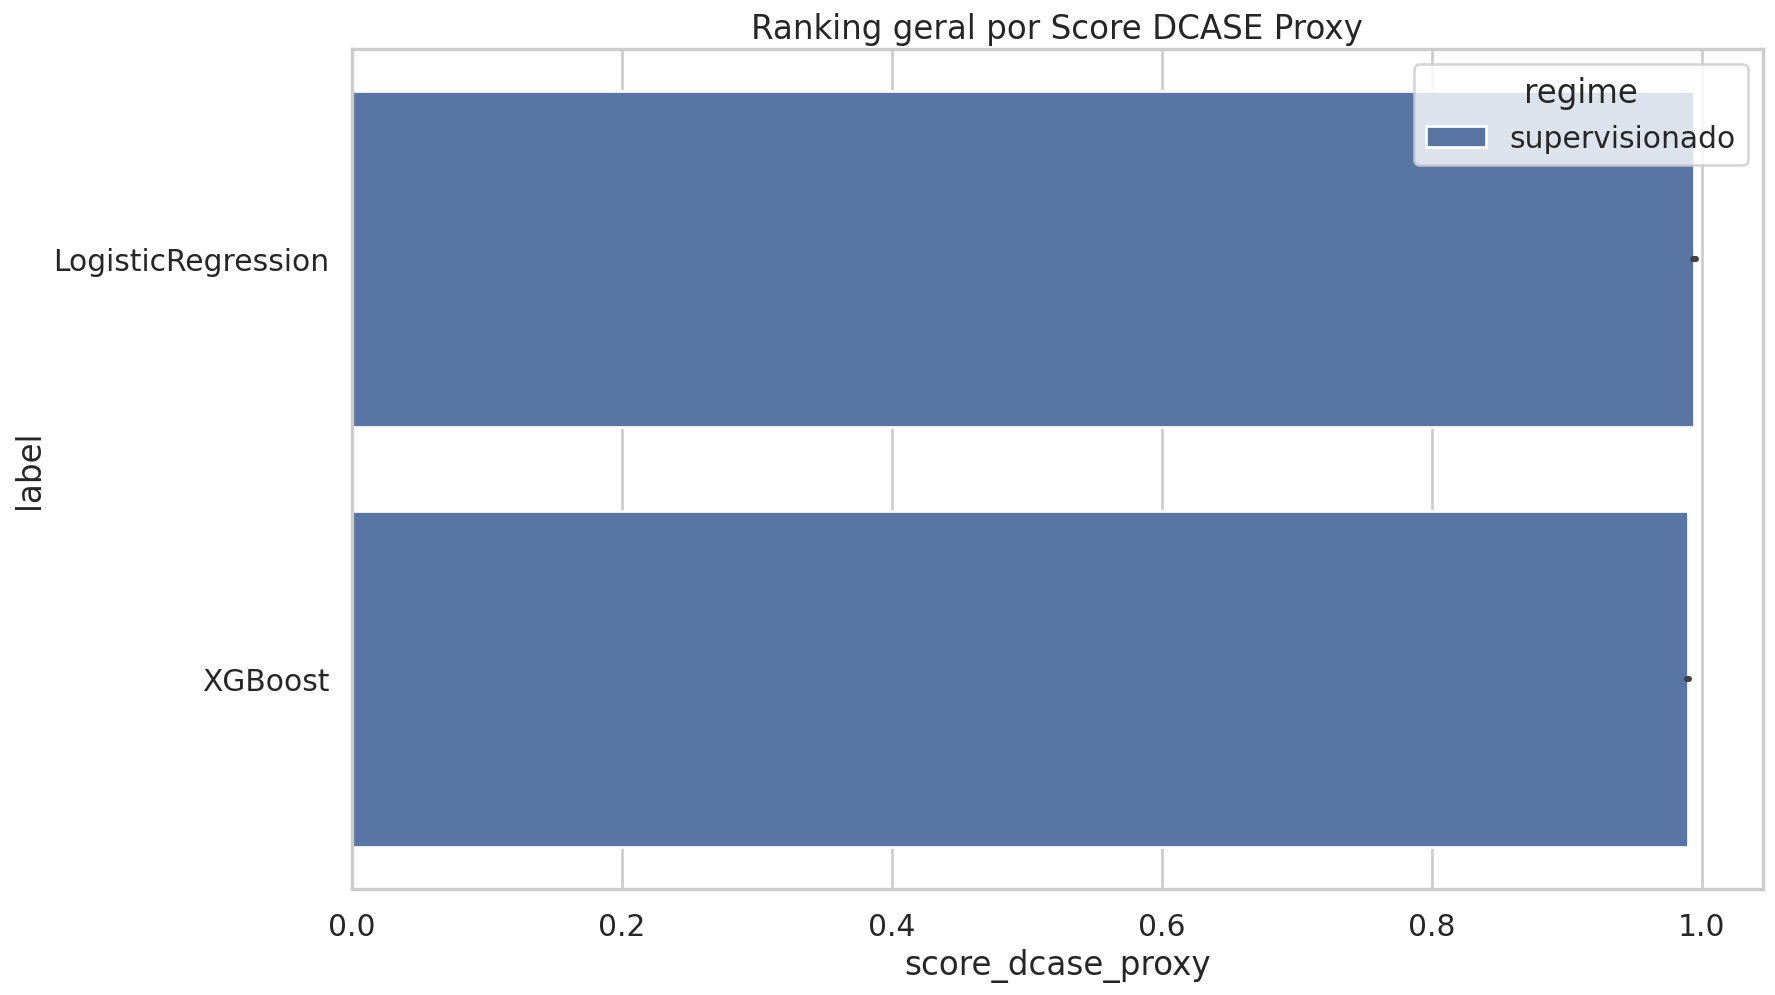

Figura salva: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/plots/pareto_f1_latency.png


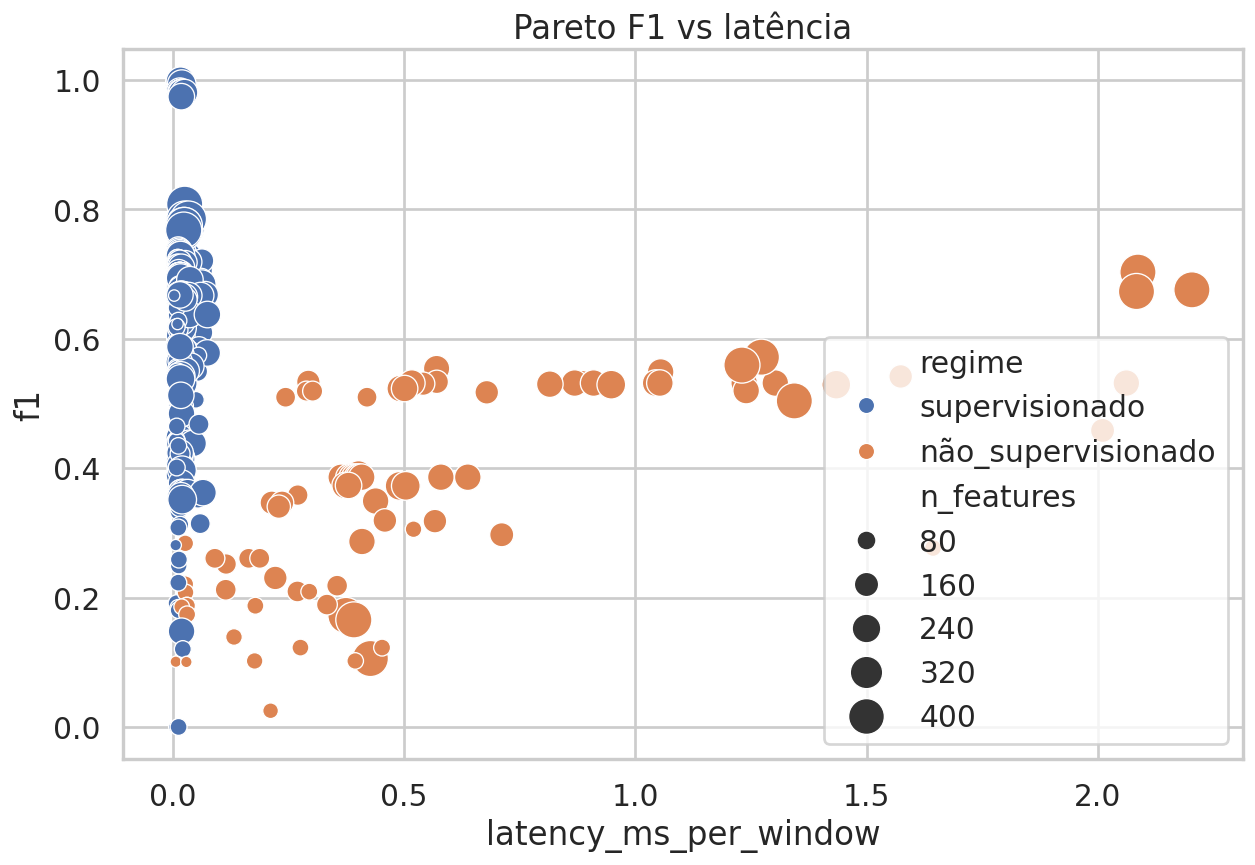

Figura salva: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/plots/pareto_pauc_memory.png


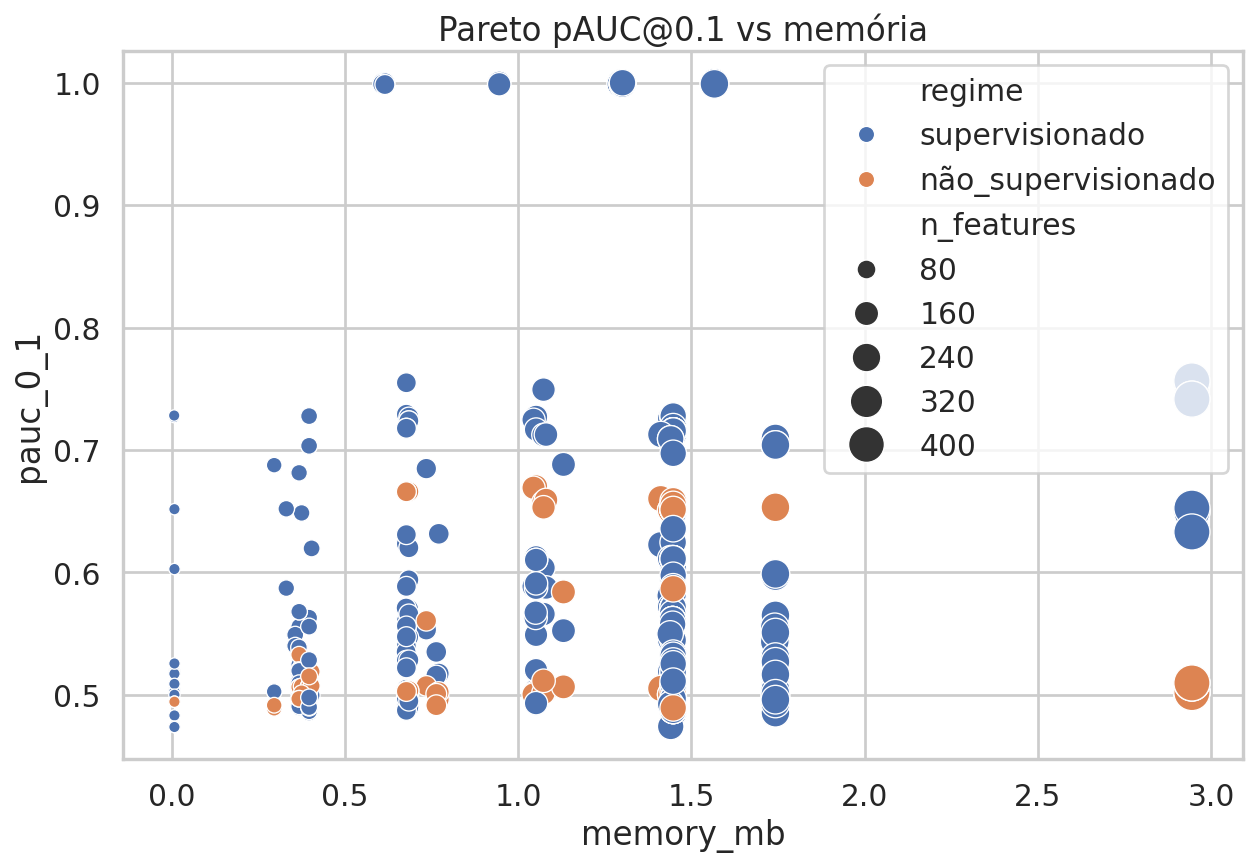

Figura salva: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/plots/robustness_snr_drop.png


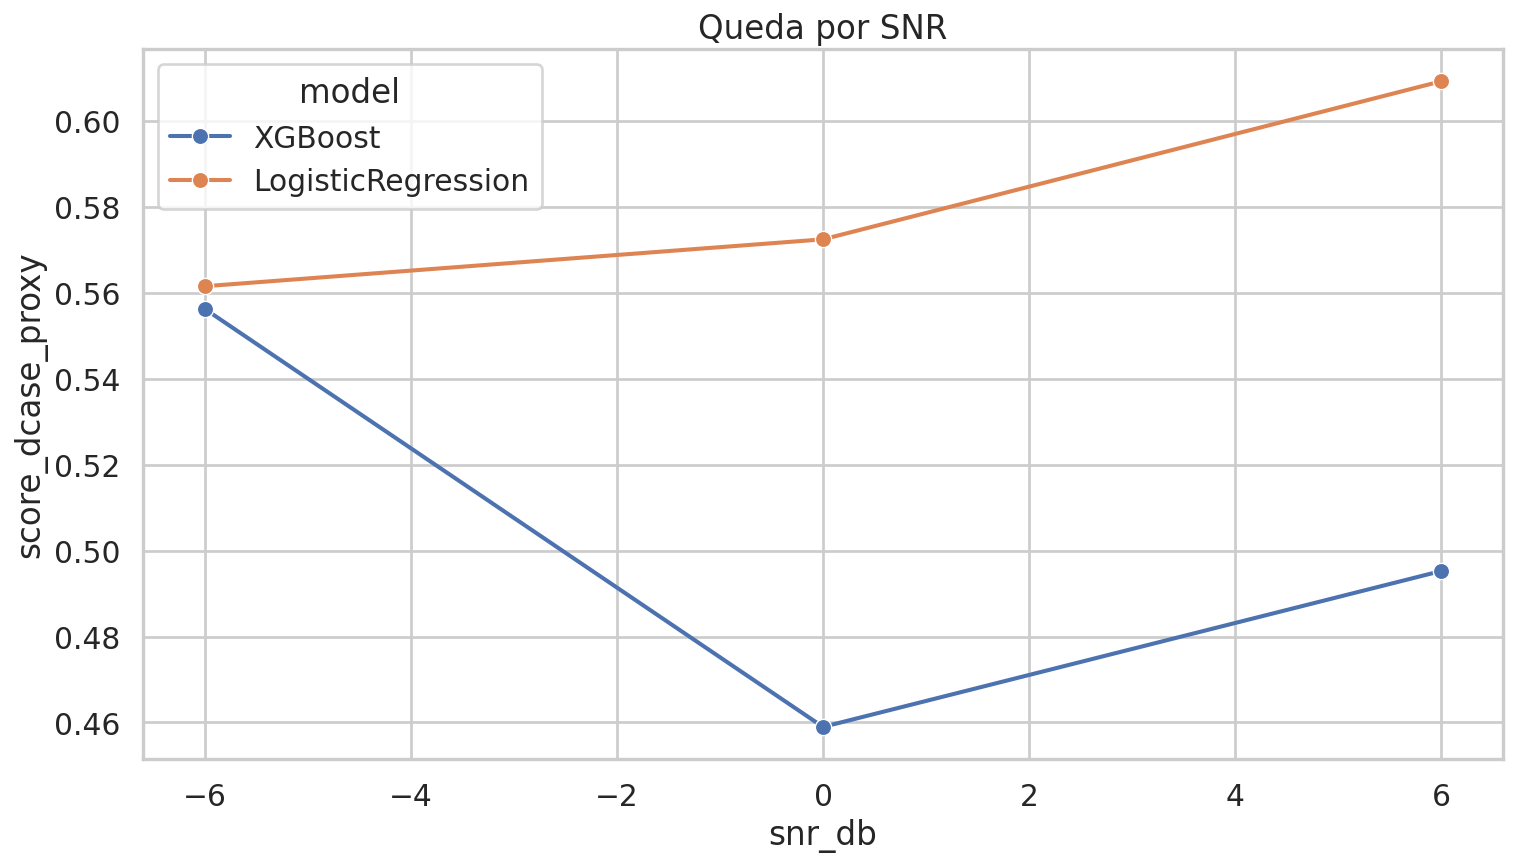

Figura salva: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/plots/ablation_comparison.png


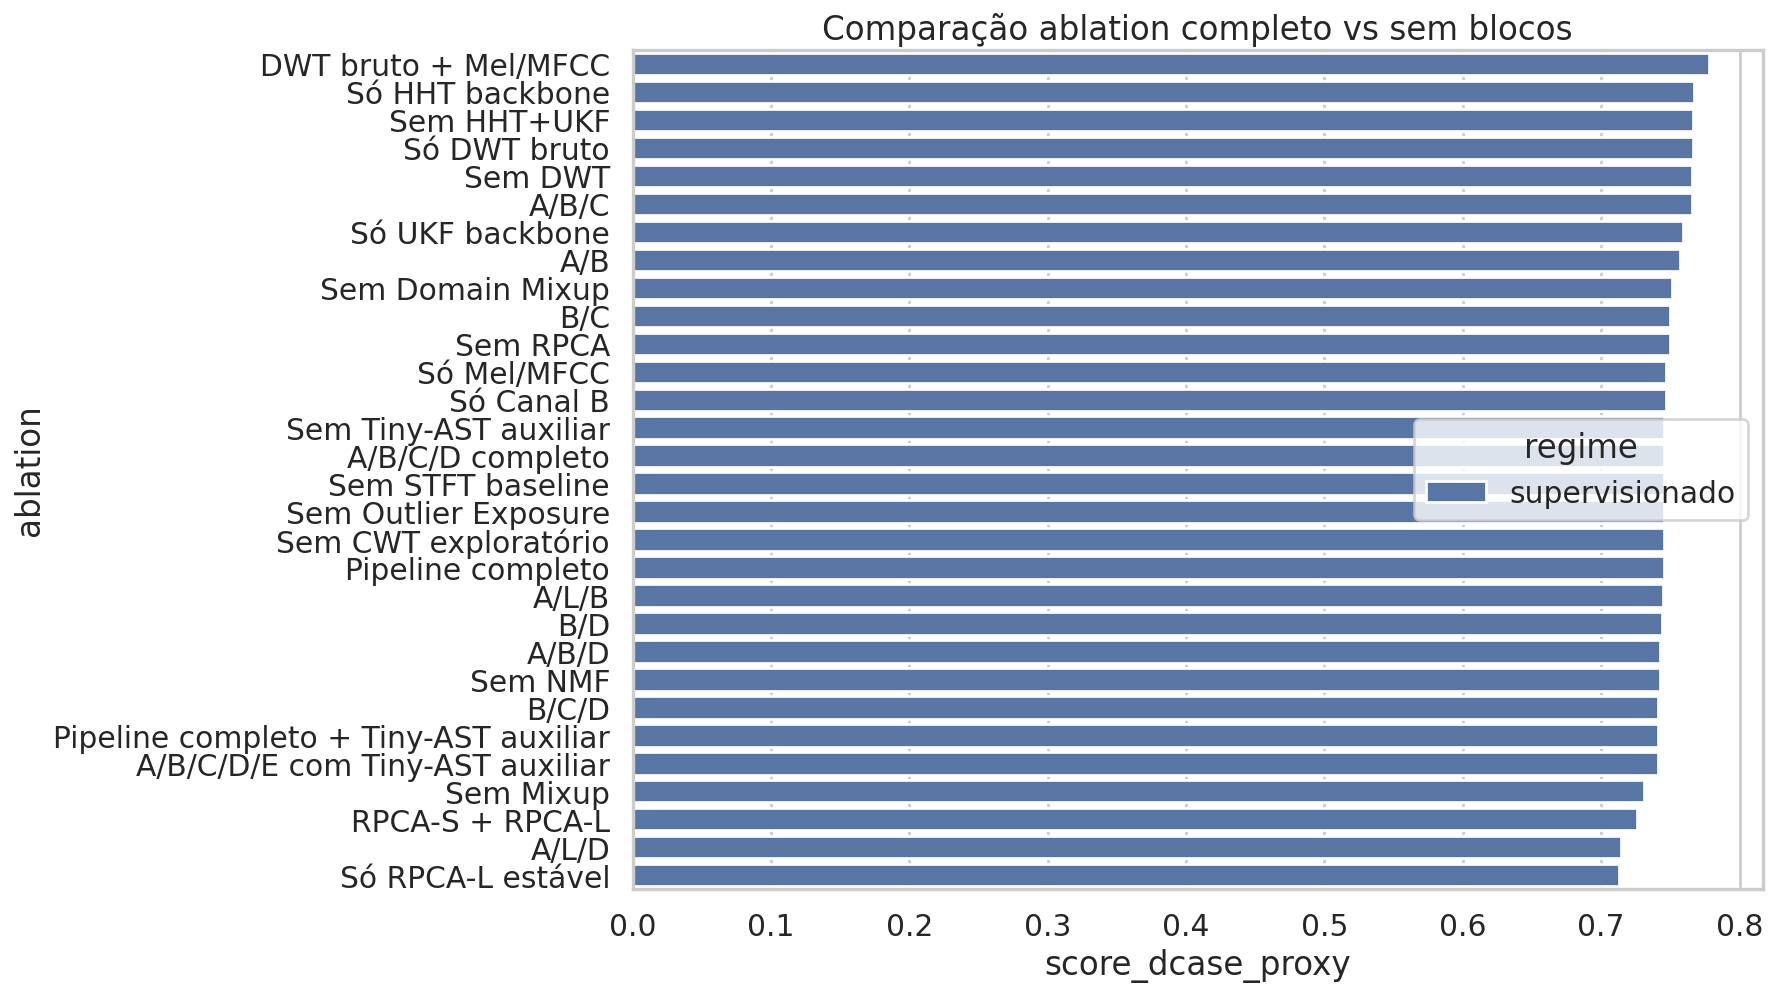

Figura salva: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/plots/channel_importance.png


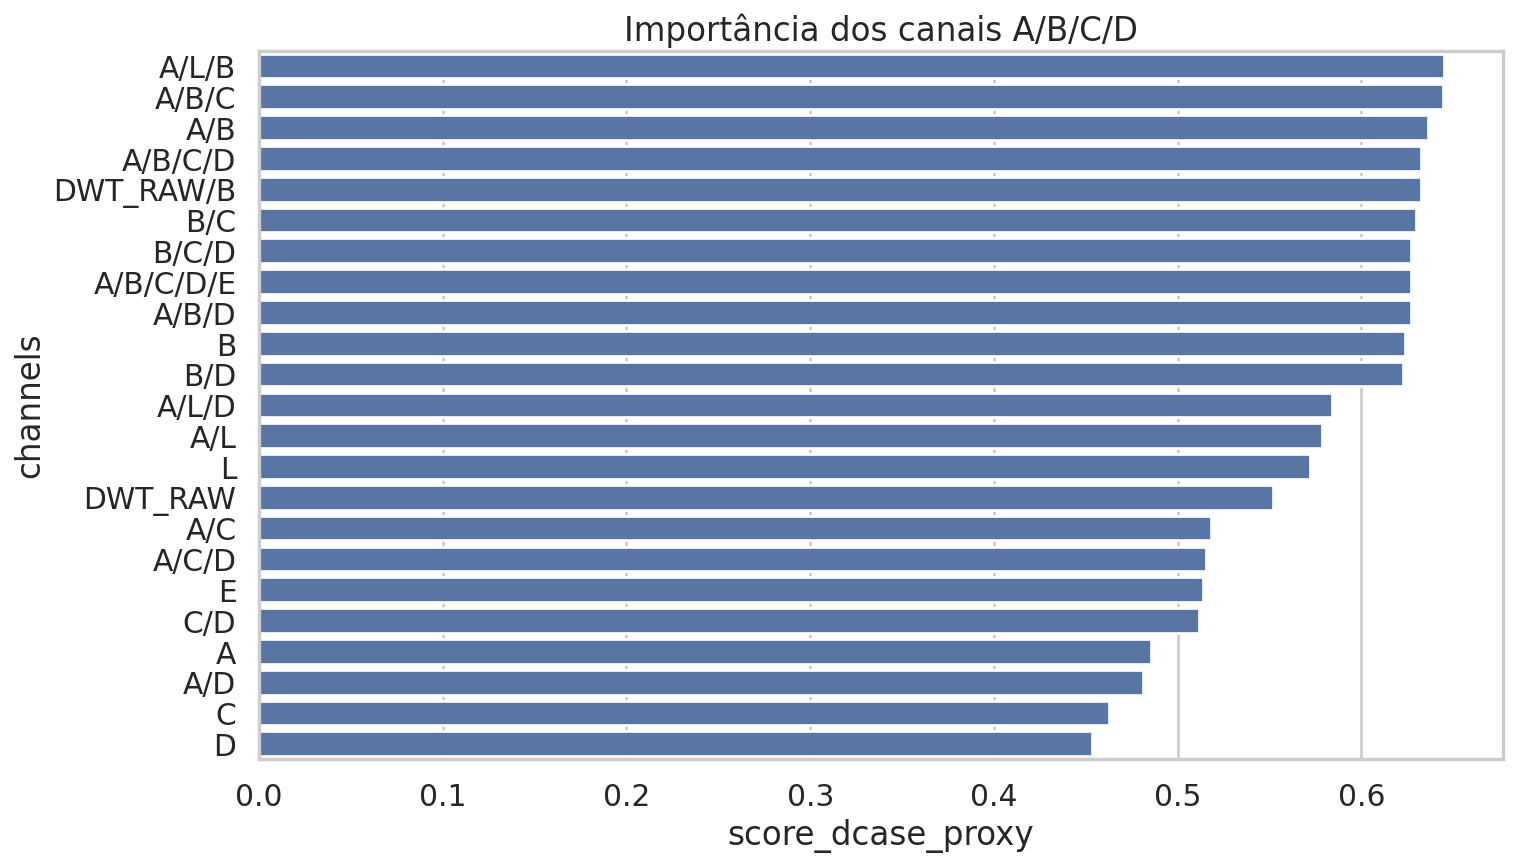

Figura salva: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/plots/final_decision_matrix.png


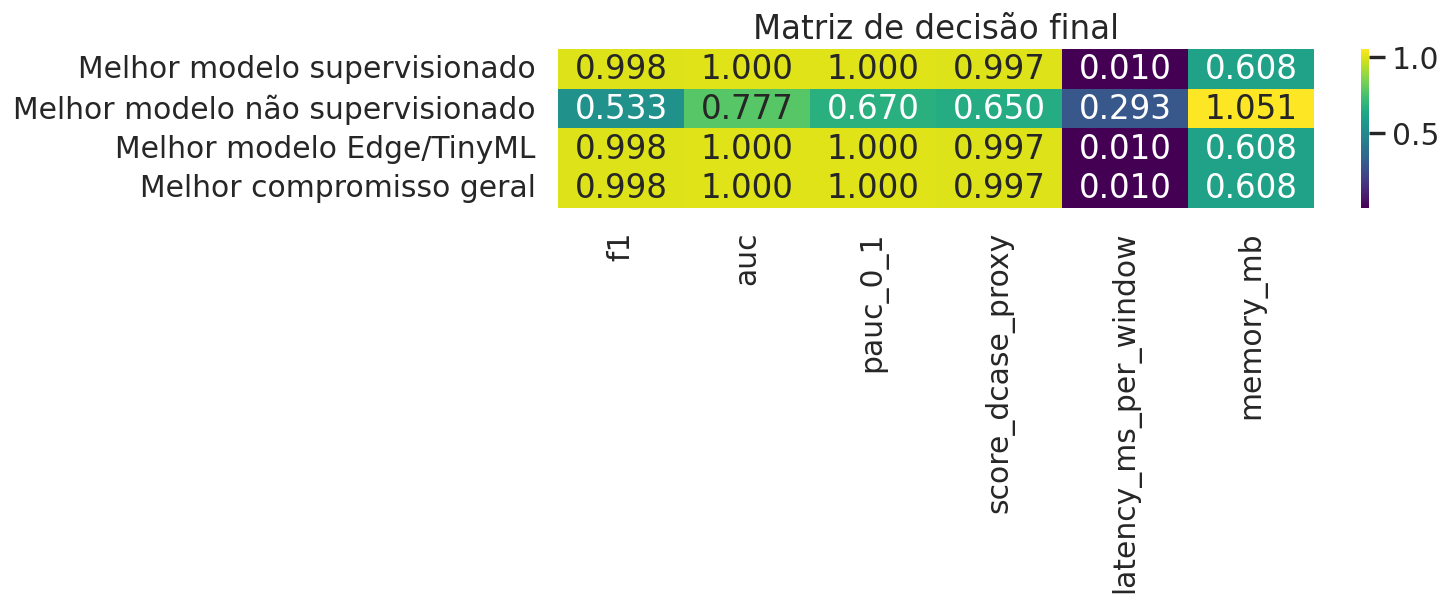

Figura salva: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/plots/domain_confrontation_by_arena.png


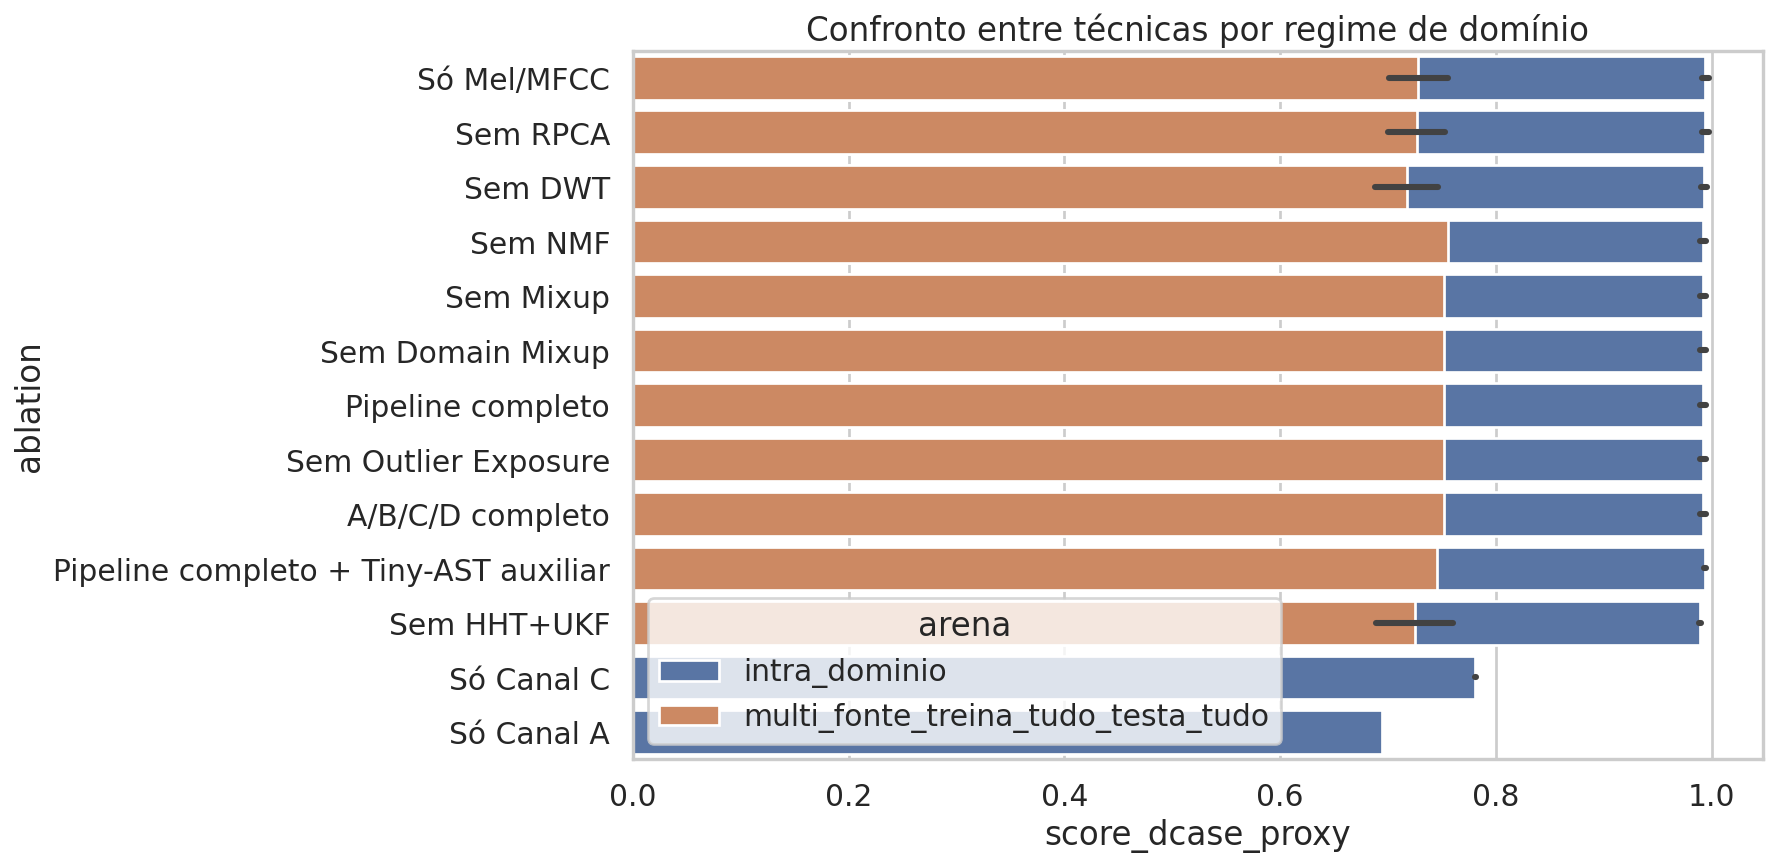

CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/xai_channel_contribution.csv
Figura salva: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/plots/xai_channel_contribution.png


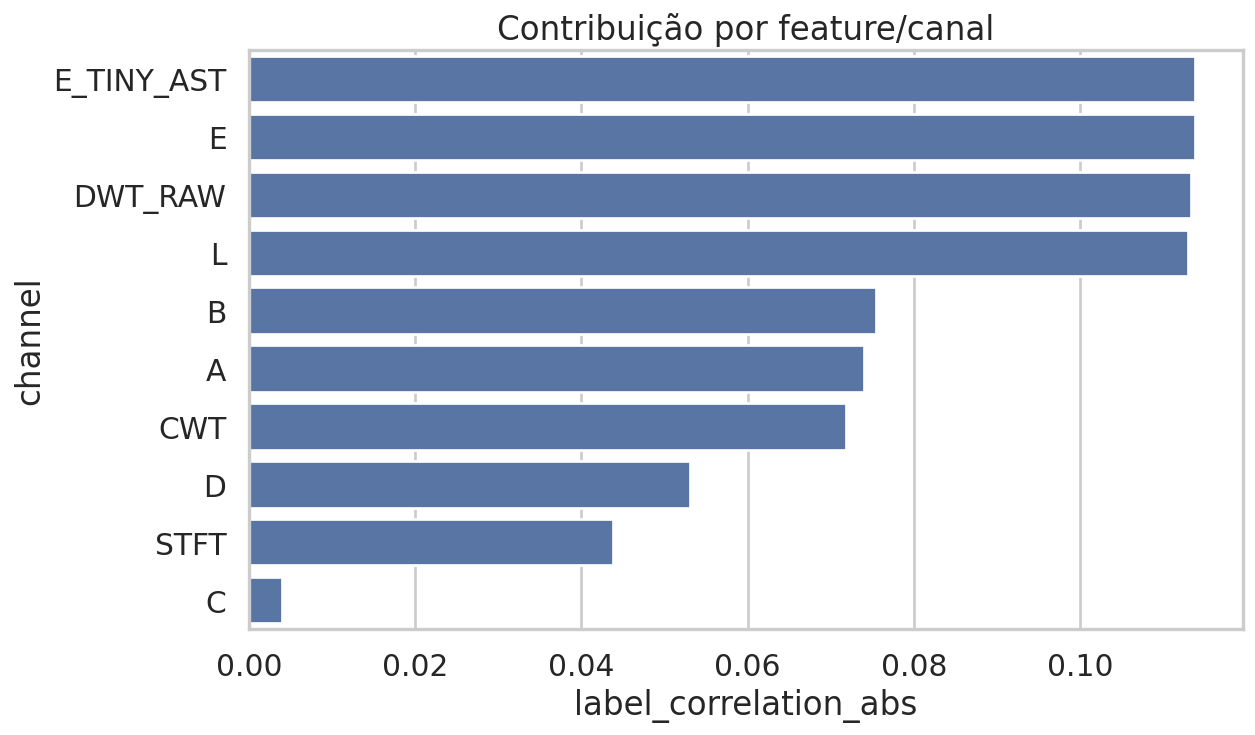

Figura salva: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/plots/xai_heatmap_best_model.png


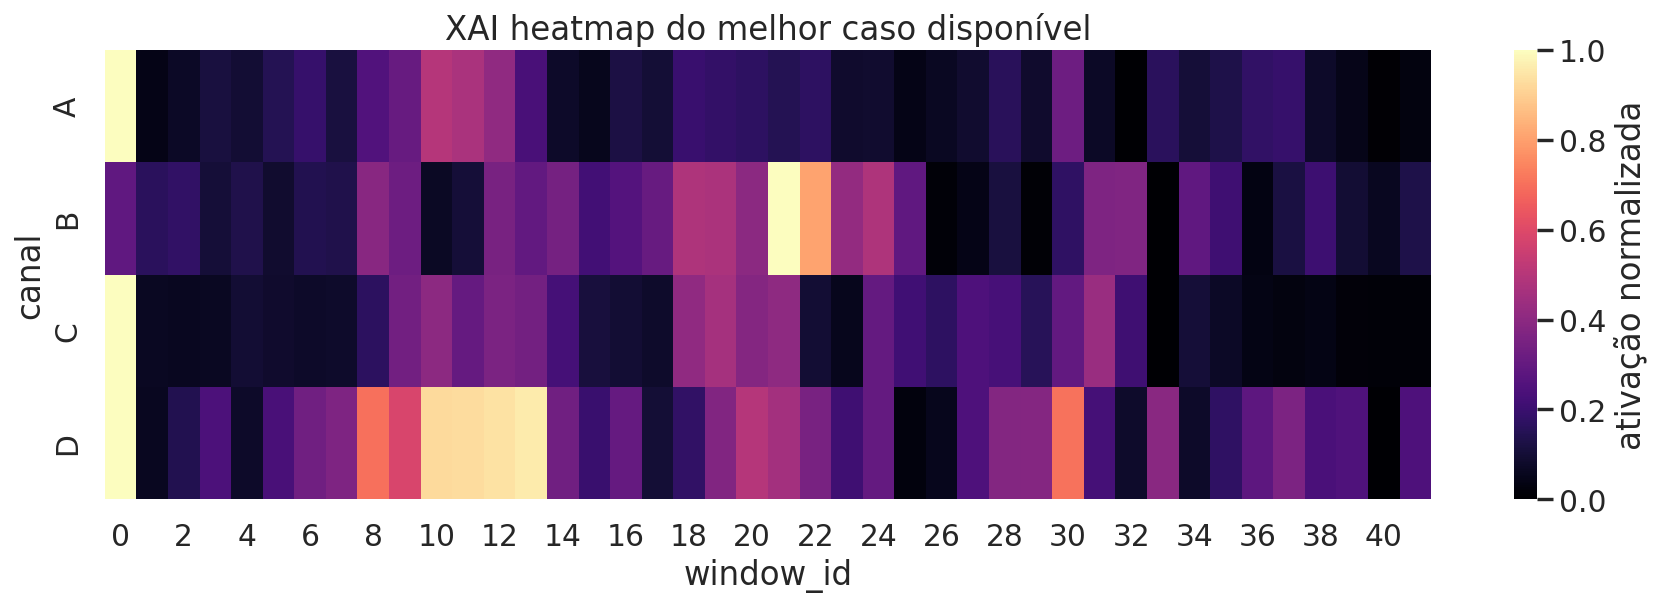

CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/xai_hotspots_h1_h2_h3.csv
CSV salvo: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/xai_frequency_bands.csv
Figura salva: /content/aad_arquitetura_campea/outputs/diamond_cristal_clean/plots/xai_frequency_bands.png


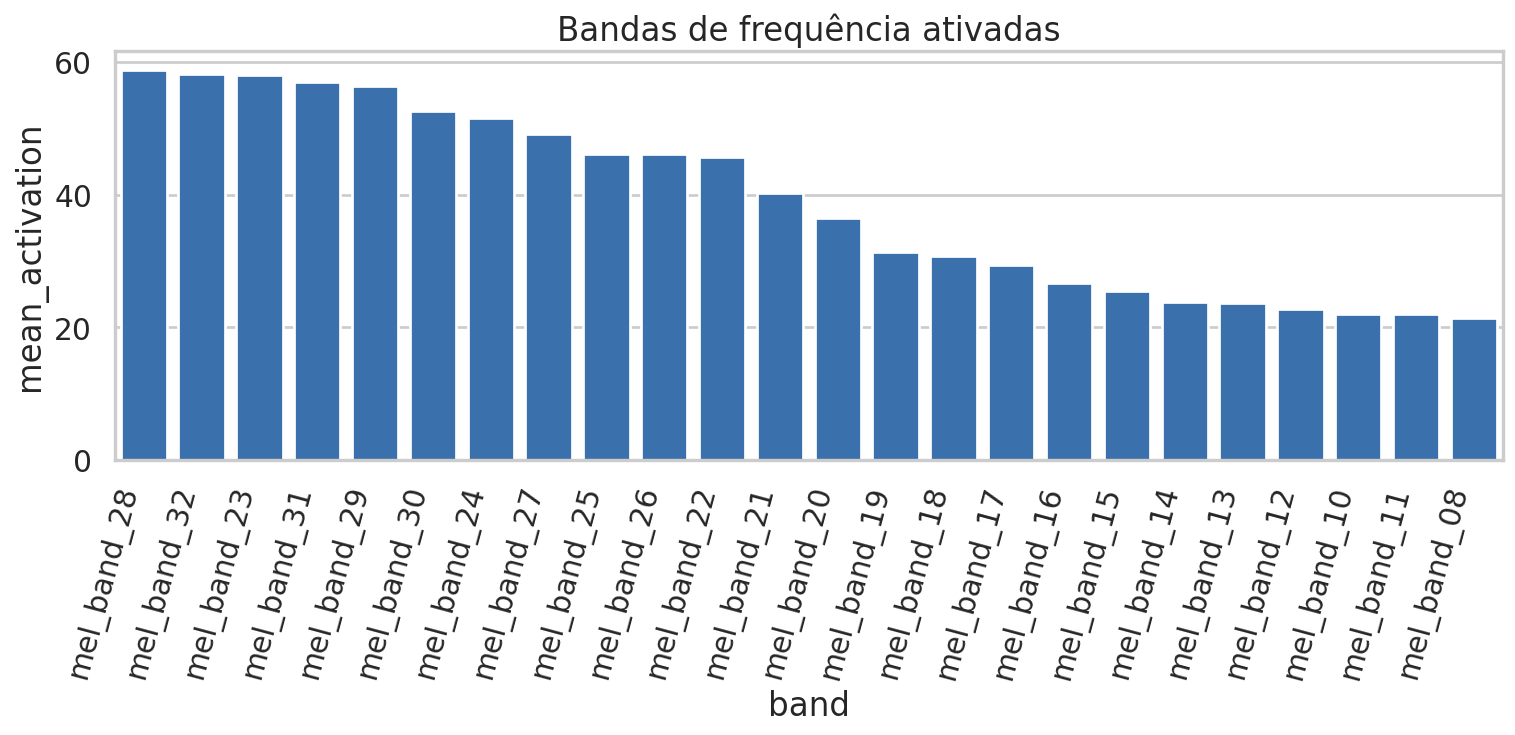

## VEREDITO DIAMOND


### 1. Modelo final escolhido

O modelo final recomendado deve ser a linha vencedora em `decision_table.csv`, priorizando o **melhor compromisso geral** e verificando se a diferença para o melhor Edge/TinyML justifica o custo.

### 2. Pipeline final

`áudio bruto -> HHT+UKF -> janelas 1.0s/hop 0.5s -> Canal A RPCA-S + Canal B Mel/MFCC + Canal C NMF + Canal D DWT-RPCA + Canal E Tiny-AST auxiliar -> modelo calibrado -> XAI`.

### 3. Tabela de evidências

Consulte:

- `decision_table.csv`
- `technique_confrontation_manifest.csv`
- `ablation_protocol_grid.csv`
- `loso_protocol_grid.csv`
- `intra_domain_grid.csv`
- `domain_shift_loso_grid.csv`
- `multisource_all_grid.csv`
- `domain_confrontation_grid.csv`
- `robustness_snr_grid.csv`
- `threshold_calibration_grid.csv`
- `final_blind_test_report.csv`
- `edge_cost_grid.csv`
- `tiny_ast_aux_grid.csv`

### 4. Por que ele venceu

Ele só deve vencer se sustentar simultaneamente `F1`, `AUC`, `pAUC@0.1`, baixo custo Edge, robustez por SNR, teste cego separado e ablação favorável dos canais.

### 5. Limitações

- CWT é referência exploratória quando a implementação local falhar.
- EVT/POT exige cauda estatística suficiente.
- Tiny-AST/CNN são opcionais e só devem entrar se o custo for compatível com Edge/TinyML.
- Canal E em modo `proxy` não deve ser vendido como Tiny-AST real; use `AAD_TINY_AST_EMBEDDINGS_CSV` para prova forte.
- O teste cego não pode ser usado para calibrar limiar.

### 6. Texto pronto para artigo

> A decisão final foi conduzida por um protocolo multi-fonte sem vazamento, com separação por arquivo/grupo/fonte, avaliação supervisionada e não supervisionada, LOSO, teste cego, ablação de canais, robustez por SNR e métricas orientadas a baixo falso alarme. A hipótese central testada foi que a decomposição DWT aplicada à componente esparsa da RPCA poderia capturar assinaturas impulsivas relevantes com custo computacional menor que alternativas tempo-frequência mais pesadas. O modelo final foi selecionado pelo Score DCASE Proxy, que combina F1, AUC-ROC e pAUC@0.1 penalizados por latência e memória, priorizando viabilidade em Edge AI/TinyML.

### 7. Próximos passos mínimos antes da submissão

1. Reexecutar o notebook com todos os dados e sem caps.
2. Conferir `leakage_audit.csv` com overlap zero.
3. Revisar `final_blind_test_report.csv` por origem.
4. Congelar versões de pacotes, seeds e caminhos de dados.
5. Incluir os CSVs finais como material suplementar.


,criterion,label,n_samples,accuracy,precision,recall,f1,auc,pauc_0_1,latency_ms_per_window,...,channels,n_features_effective,calibration,threshold,fold_name,holdout_type,holdout_value,arena,train_sources,test_source
0,Melhor modelo supervisionado,LogisticRegression,450,0.997778,0.995575,1.000000,0.997783,1.000000,1.000000,0.010258,...,B,NaN,NaN,NaN,NaN,NaN,NaN,intra_dominio,Kaggle,Kaggle
1,Melhor modelo não supervisionado,GMM+gamma,450,0.657778,0.838095,0.391111,0.533333,0.776691,0.670227,0.293226,...,A/B/C,146.0,gamma,80.433865,NaN,NaN,NaN,NaN,NaN,NaN
2,Melhor modelo Edge/TinyML,LogisticRegression,450,0.997778,0.995575,1.000000,0.997783,1.000000,1.000000,0.010258,...,B,NaN,NaN,NaN,NaN,NaN,NaN,intra_dominio,Kaggle,Kaggle
3,Melhor compromisso geral,LogisticRegression,450,0.997778,0.995575,1.000000,0.997783,1.000000,1.000000,0.010258,...,B,NaN,NaN,NaN,NaN,NaN,NaN,intra_dominio,Kaggle,Kaggle


In [ ]:
def cols_for_channels(channels: str, base_cols: Optional[list[str]] = None) -> list[str]:
    if channels == "ALL":
        return list(base_cols or FEATURE_COLUMNS)
    cols = []
    for ch in channels.split("/"):
        cols.extend(FEATURE_FAMILIES.get(ch, []))
    return sorted(dict.fromkeys([c for c in cols if c in FEATURE_COLUMNS]))


ABLATION_CONFIGS = [
    ("Pipeline completo", "A/B/C/D", {}),
    ("Pipeline completo + Tiny-AST auxiliar", "A/B/C/D/E", {}),
    ("Sem HHT+UKF", "A/B/C/D", {"dsp_variant": "raw"}),
    ("Só HHT backbone", "A/B/C/D", {"dsp_variant": "hht"}),
    ("Só UKF backbone", "A/B/C/D", {"dsp_variant": "ukf"}),
    ("Sem RPCA", "B/C", {"remove_prefix": ["A_sparse", "L_low_rank", "D_dwt_rpca", "rpca_"]}),
    ("Só RPCA-S física", "A", {}),
    ("Só RPCA-L estável", "L", {}),
    ("RPCA-S + RPCA-L", "A/L", {}),
    ("Sem NMF", "A/B/D", {}),
    ("Sem DWT", "A/B/C", {}),
    ("Só DWT bruto", "DWT_RAW", {}),
    ("DWT bruto + Mel/MFCC", "DWT_RAW/B", {}),
    ("DWT-RPCA vs bruto | só D", "D", {}),
    ("Sem CWT exploratório", "A/B/C/D", {"remove_prefix": ["cwt"]}),
    ("Sem STFT baseline", "A/B/C/D", {"remove_prefix": ["stft"]}),
    ("Sem Tiny-AST auxiliar", "A/B/C/D", {}),
    ("Sem Domain Mixup", "A/B/C/D", {"use_domain_mixup": False}),
    ("Sem Mixup", "A/B/C/D", {"use_mixup": False}),
    ("Sem Outlier Exposure", "A/B/C/D", {"use_oe": False}),
    ("Só Mel/MFCC", "B", {}),
    ("Só Canal A", "A", {}),
    ("Só Canal B", "B", {}),
    ("Só Canal C", "C", {}),
    ("Só Canal DWT-RPCA", "D", {}),
    ("Só Tiny-AST auxiliar", "E", {}),
    ("A/L/B", "A/L/B", {}),
    ("A/L/D", "A/L/D", {}),
    ("A/B", "A/B", {}),
    ("A/C", "A/C", {}),
    ("A/D", "A/D", {}),
    ("B/C", "B/C", {}),
    ("B/D", "B/D", {}),
    ("C/D", "C/D", {}),
    ("A/B/C", "A/B/C", {}),
    ("A/B/D", "A/B/D", {}),
    ("A/C/D", "A/C/D", {}),
    ("B/C/D", "B/C/D", {}),
    ("A/B/C/D completo", "A/B/C/D", {}),
    ("A/B/C/D/E com Tiny-AST auxiliar", "A/B/C/D/E", {}),
]

technique_confrontation_manifest = pd.DataFrame([
    {"notebook_or_phase": "1", "technique": "Supervisionado inicial", "confronted_as": "XGBoost/RandomForest/Logistic em ablation, intra-domínio, LOSO e multi-fonte"},
    {"notebook_or_phase": "2", "technique": "Não supervisionado inicial", "confronted_as": "Mahalanobis, GMM, Isolation Forest, One-Class SVM opcional"},
    {"notebook_or_phase": "3", "technique": "Baseline sintético/primeiro controle", "confronted_as": "modelos lineares e STFT/Mel/MFCC baseline"},
    {"notebook_or_phase": "4", "technique": "Mel/log-Mel", "confronted_as": "Só Mel/log-Mel, Canal B, macro_representation_grid"},
    {"notebook_or_phase": "5", "technique": "CWT", "confronted_as": "CWT exploratório e Sem CWT exploratório"},
    {"notebook_or_phase": "6", "technique": "STFT", "confronted_as": "STFT baseline e Sem STFT baseline"},
    {"notebook_or_phase": "7-10", "technique": "Mel/MFCC/CWT híbrido + NMF + Kaggle + teste cego", "confronted_as": "A/B/C/D, Só Canal B, Só Canal C, teste cego e arenas de domínio"},
    {"notebook_or_phase": "11-12", "technique": "L2/Gamma, CNN/GMM", "confronted_as": "XGBoost regularizado, GMM+Gamma, threshold_calibration_grid"},
    {"notebook_or_phase": "13", "technique": "HHT+UKF", "confronted_as": "Sem HHT+UKF, Só HHT, Só UKF, macro_dsp_grid"},
    {"notebook_or_phase": "14", "technique": "Mixup", "confronted_as": "Sem Mixup e training_recipe_grid"},
    {"notebook_or_phase": "15-16", "technique": "pAUC@0.1, Score DCASE, Gamma/FPR alvo", "confronted_as": "métrica central e calibração Gamma/Percentil/EVT"},
    {"notebook_or_phase": "17", "technique": "Outlier Exposure DCASE", "confronted_as": "Sem Outlier Exposure e OE em receitas"},
    {"notebook_or_phase": "18", "technique": "Mahalanobis/GMM/Isolation Forest", "confronted_as": "unsupervised_detector_grid"},
    {"notebook_or_phase": "19", "technique": "Pretrain/Tiny-AST", "confronted_as": "Canal E Tiny-AST auxiliar, Sem Tiny-AST, Só Tiny-AST"},
    {"notebook_or_phase": "20", "technique": "XAI", "confronted_as": "hotspots H1/H2/H3, bandas e contribuição por canal"},
    {"notebook_or_phase": "21-25", "technique": "Arena final, regimes, MIMII multi-SNR", "confronted_as": "intra_domain, domain_shift_loso, multisource_all e robustness_snr_grid"},
    {"notebook_or_phase": "26-27", "technique": "Síntese e Masterpiece ablation", "confronted_as": "decision_table, final_model_card, ablation_protocol_grid"},
    {"notebook_or_phase": "novo", "technique": "DWT-RPCA na componente S", "confronted_as": "Só DWT-RPCA, Só DWT bruto, DWT bruto + Mel/MFCC, A/B/C/D"},
])
save_df(technique_confrontation_manifest, "technique_confrontation_manifest.csv")


def remove_prefix_cols(cols: list[str], prefixes: list[str]) -> list[str]:
    return [c for c in cols if not any(c.startswith(p) for p in prefixes)]


def run_supervised_suite(base_df: pd.DataFrame, feature_cols: list[str], recipe: dict, scope: str) -> tuple[list[dict], list[pd.DataFrame], dict]:
    rows, preds = [], []
    if base_df.empty or not has_split_schema(base_df):
        log_step(f"Suite supervisionada pulada em {scope}: feature store vazio ou sem schema de split ({missing_columns(base_df, REQUIRED_SPLIT_COLUMNS)}).")
        return rows, preds, {}
    feature_cols = [c for c in feature_cols if c in base_df.columns]
    if not feature_cols:
        log_step(f"Suite supervisionada pulada em {scope}: sem features numéricas disponíveis.")
        return rows, preds, {}
    train, test, sw = prepare_supervised_training(
        base_df, feature_cols,
        use_mixup=recipe.get("use_mixup", True),
        use_domain_mixup=recipe.get("use_domain_mixup", True),
        use_oe=recipe.get("use_oe", True),
    )
    fitted = {}
    for name, model in supervised_model_registry(recipe.get("model_set")).items():
        pipe, row, pred = fit_predict_supervised(train, test, feature_cols, name, model, sample_weight=sw)
        if row:
            row.update({"scope": scope, **recipe})
            rows.append(row)
            pred["scope"] = scope
            preds.append(pred)
            fitted[name] = pipe
    return rows, preds, fitted


def run_unsup_suite(base_df: pd.DataFrame, feature_cols: list[str], scope: str, model_set: Optional[str] = None) -> tuple[list[dict], list[pd.DataFrame], dict]:
    rows, preds, fitted = [], [], {}
    if base_df.empty or not has_split_schema(base_df):
        log_step(f"Suite não supervisionada pulada em {scope}: feature store vazio ou sem schema de split ({missing_columns(base_df, REQUIRED_SPLIT_COLUMNS)}).")
        return rows, preds, fitted
    feature_cols = [c for c in feature_cols if c in base_df.columns]
    if not feature_cols:
        log_step(f"Suite não supervisionada pulada em {scope}: sem features numéricas disponíveis.")
        return rows, preds, fitted
    active_model_set = (model_set or CFG.unsup_model_set or "all").lower()
    if active_model_set in {"core", "light"}:
        model_names = ["Mahalanobis", "GMM"]
        calibrations = ["gamma"]
    else:
        model_names = ["Mahalanobis", "GMM", "IsolationForest", "OneClassSVM"]
        calibrations = ["gamma", "percentile_95", "evt_pot"]
    for model_name in model_names:
        if model_name == "OneClassSVM" and not CFG.enable_optional_heavy:
            continue
        for cal in calibrations:
            model, row, pred = evaluate_unsupervised(base_df, feature_cols, model_name, calibration=cal)
            if row:
                row.update({"scope": scope})
                rows.append(row)
                pred["scope"] = scope
                preds.append(pred)
                fitted[f"{model_name}+{cal}"] = model
    return rows, preds, fitted


# Ablação principal
ablation_rows, all_pred_parts, fitted_models = [], [], {}
for label, channels, opts in ABLATION_CONFIGS:
    df_used = feature_df
    dsp_variant = opts.get("dsp_variant")
    if dsp_variant and dsp_variant != "hht_ukf":
        df_used, _ = build_feature_store(catalog, dsp_variant=dsp_variant, cache_name=f"feature_store_{dsp_variant}")
    cols = cols_for_channels(channels)
    if opts.get("remove_prefix"):
        cols = remove_prefix_cols(cols, opts["remove_prefix"])
    recipe = {
        "use_mixup": opts.get("use_mixup", True),
        "use_domain_mixup": opts.get("use_domain_mixup", True),
        "use_oe": opts.get("use_oe", True),
    }
    srows, spreds, sfitted = run_supervised_suite(df_used, cols, recipe, label)
    urows, upreds, ufitted = run_unsup_suite(df_used, cols, label)
    for r in srows + urows:
        r["ablation"] = label
        r["channels"] = channels
        r["n_features_effective"] = len(cols)
        ablation_rows.append(r)
    all_pred_parts.extend(spreds + upreds)
    fitted_models.update({f"{label}::{k}": v for k, v in {**sfitted, **ufitted}.items()})

ablation_protocol_grid = pd.DataFrame(ablation_rows)
save_df(ablation_protocol_grid, "ablation_protocol_grid.csv")


# Grade de receitas de treino
training_rows = []
full_recipe_grid = [
    {"use_mixup": m, "use_domain_mixup": d, "use_oe": o}
    for m in [False, True] for d in [False, True] for o in [False, True]
]
recipe_grid = (
    [
        {"use_mixup": True, "use_domain_mixup": True, "use_oe": True},
        {"use_mixup": False, "use_domain_mixup": True, "use_oe": True},
        {"use_mixup": True, "use_domain_mixup": False, "use_oe": True},
        {"use_mixup": True, "use_domain_mixup": True, "use_oe": False},
    ]
    if FAST_COMPLETE else full_recipe_grid
)
for recipe in recipe_grid:
    rows, _, _ = run_supervised_suite(feature_df, FEATURE_COLUMNS, recipe, f"recipe_{recipe}")
    for r in rows:
        training_rows.append(r)
training_recipe_grid = pd.DataFrame(training_rows)
save_df(training_recipe_grid, "training_recipe_grid.csv")


# Grade conjunta supervisionada: família x receita
joint_rows = []
channel_combos = [
    "A", "L", "B", "C", "D", "E", "DWT_RAW",
    "A/L", "A/B", "A/C", "A/D", "L/B", "L/D", "B/C", "B/D", "C/D", "B/E", "D/E", "DWT_RAW/B",
    "A/L/B", "A/B/C", "A/B/D", "A/C/D", "B/C/D", "A/L/D",
    "A/B/C/D", "A/B/C/D/E",
]
for channels in channel_combos:
    cols = cols_for_channels(channels)
    for recipe in recipe_grid:
        rows, _, _ = run_supervised_suite(feature_df, cols, recipe, f"joint_{channels}_{recipe}")
        for r in rows:
            r["channels"] = channels
            joint_rows.append(r)
supervised_joint_grid = pd.DataFrame(joint_rows)
save_df(supervised_joint_grid, "supervised_joint_grid.csv")


# LOSO com métricas: uma fonte/máquina inteira fora do treino.
def run_loso_supervised_grid(base_df: pd.DataFrame, folds: list[dict], feature_cols: list[str], channels_label: str) -> pd.DataFrame:
    rows = []
    if base_df.empty or not folds:
        return pd.DataFrame()
    feature_cols = [c for c in feature_cols if c in base_df.columns]
    if not feature_cols:
        return pd.DataFrame()
    for fold in folds:
        train = base_df[base_df["source_id"].isin(fold["train_source_ids"]) & base_df["label"].isin([0, 1])].copy()
        test = base_df[base_df["source_id"].isin(fold["test_source_ids"]) & base_df["label"].isin([0, 1])].copy()
        if train.empty or test.empty or train["label"].nunique() < 2 or test["label"].nunique() < 2:
            continue
        weights = np.ones(len(train))
        for model_name, model in supervised_model_registry().items():
            _, row, _ = fit_predict_supervised(train, test, feature_cols, model_name, model, sample_weight=weights)
            if row:
                row.update({
                    "fold_name": fold["fold_name"],
                    "holdout_type": fold["holdout_type"],
                    "holdout_value": fold["holdout_value"],
                    "channels": channels_label,
                    "scope": "LOSO",
                })
                rows.append(row)
    return pd.DataFrame(rows)


loso_parts = []
for channels in ["A/B/C/D", "A/B/C/D/E", "B", "D", "DWT_RAW"]:
    loso_cols = cols_for_channels(channels)
    part = run_loso_supervised_grid(feature_df, LOSO_SOURCE_FOLDS + LOSO_MACHINE_FOLDS, loso_cols, channels)
    if not part.empty:
        loso_parts.append(part)
loso_protocol_grid = pd.concat(loso_parts, ignore_index=True) if loso_parts else pd.DataFrame()
save_df(loso_protocol_grid, "loso_protocol_grid.csv")


# Três arenas de domínio pedidas:
# 1) intra-domínio; 2) multi-fonte com fonte deixada fora; 3) multi-fonte all-to-all.
def ablation_feature_view(label: str, channels: str, opts: dict) -> tuple[pd.DataFrame, list[str]]:
    dsp_variant = opts.get("dsp_variant")
    df_used = feature_df
    if dsp_variant and dsp_variant != "hht_ukf":
        df_used, _ = build_feature_store(catalog, dsp_variant=dsp_variant, cache_name=f"feature_store_{dsp_variant}")
    cols = cols_for_channels(channels)
    if opts.get("remove_prefix"):
        cols = remove_prefix_cols(cols, opts["remove_prefix"])
    cols = [c for c in cols if c in df_used.columns]
    return df_used, cols


def augment_arena_train(train: pd.DataFrame, base_df: pd.DataFrame, feature_cols: list[str], recipe: dict) -> tuple[pd.DataFrame, np.ndarray]:
    parts = [train]
    weights = [np.ones(len(train))]
    if recipe.get("use_mixup", True):
        mdf, mw = mixup_supervised(train, feature_cols)
        if not mdf.empty:
            parts.append(mdf); weights.append(mw)
    if recipe.get("use_domain_mixup", True):
        ddf, dw = domain_mixup_normals(train, feature_cols)
        if not ddf.empty:
            parts.append(ddf); weights.append(dw)
    if recipe.get("use_oe", True):
        odf, ow = oe_samples(base_df, feature_cols)
        if not odf.empty:
            parts.append(odf); weights.append(ow)
    return pd.concat(parts, ignore_index=True), np.concatenate(weights)


def evaluate_arena_split(
    base_df: pd.DataFrame,
    feature_cols: list[str],
    train_ids: set[int],
    test_ids: set[int],
    arena: str,
    train_sources: str,
    test_source: str,
    ablation_label: str,
    channels: str,
    recipe: dict,
) -> list[dict]:
    rows = []
    if base_df.empty or not feature_cols:
        return rows
    blind_mask = base_df["role_blind_test"].astype(bool) if "role_blind_test" in base_df.columns else pd.Series(False, index=base_df.index)
    oe_mask = base_df["role_oe_train"].astype(bool) if "role_oe_train" in base_df.columns else pd.Series(False, index=base_df.index)
    pool = base_df[(base_df["label"].isin([0, 1])) & (~blind_mask) & (~oe_mask)].copy()
    train = pool[pool["source_id"].isin(train_ids)].copy()
    test = pool[pool["source_id"].isin(test_ids)].copy()
    if train.empty or test.empty or train["label"].nunique() < 2 or test["label"].nunique() < 2:
        return rows
    train_aug, weights = augment_arena_train(train, base_df, feature_cols, recipe)
    for model_name, model in supervised_model_registry().items():
        _, row, _ = fit_predict_supervised(train_aug, test, feature_cols, model_name, model, sample_weight=weights)
        if row:
            row.update({
                "arena": arena,
                "train_sources": train_sources,
                "test_source": test_source,
                "ablation": ablation_label,
                "channels": channels,
                "use_mixup": recipe.get("use_mixup", True),
                "use_domain_mixup": recipe.get("use_domain_mixup", True),
                "use_oe": recipe.get("use_oe", True),
            })
            rows.append(row)
    return rows


def source_pool_for_domain(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    return df[
        (df["label"].isin([0, 1])) &
        (~df["role_blind_test"].astype(bool)) &
        (~df["role_oe_train"].astype(bool))
    ].copy()


def build_intra_domain_splits(df: pd.DataFrame) -> list[dict]:
    splits = []
    pool = source_pool_for_domain(df)
    for source_name, part in pool.groupby("source", dropna=False):
        if part["label"].nunique() < 2 or part["_group_key"].nunique() < 3:
            continue
        splitter = GroupShuffleSplit(n_splits=1, test_size=SUP_TEST_SIZE, random_state=RANDOM_STATE + 401)
        tr, te = next(splitter.split(part, part["label"], groups=part["_group_key"]))
        splits.append({
            "arena": "intra_dominio",
            "train_sources": str(source_name),
            "test_source": str(source_name),
            "train_ids": set(part.iloc[tr]["source_id"]),
            "test_ids": set(part.iloc[te]["source_id"]),
        })
    return splits


def build_domain_shift_splits(df: pd.DataFrame) -> list[dict]:
    splits = []
    pool = source_pool_for_domain(df)
    sources = sorted(pool["source"].dropna().unique())
    for holdout in sources:
        test = pool[pool["source"].eq(holdout)]
        train = pool[~pool["source"].eq(holdout)]
        if train["label"].nunique() < 2 or test["label"].nunique() < 2:
            continue
        splits.append({
            "arena": "multi_fonte_domain_shift_loso",
            "train_sources": " + ".join(sorted(train["source"].dropna().unique())),
            "test_source": str(holdout),
            "train_ids": set(train["source_id"]),
            "test_ids": set(test["source_id"]),
        })
    return splits


def build_multisource_all_split(df: pd.DataFrame) -> list[dict]:
    pool = source_pool_for_domain(df)
    if pool.empty or pool["label"].nunique() < 2 or pool["_group_key"].nunique() < 3:
        return []
    splitter = GroupShuffleSplit(n_splits=1, test_size=SUP_TEST_SIZE, random_state=RANDOM_STATE + 503)
    tr, te = next(splitter.split(pool, pool["label"], groups=pool["_group_key"]))
    return [{
        "arena": "multi_fonte_treina_tudo_testa_tudo",
        "train_sources": " + ".join(sorted(pool.iloc[tr]["source"].dropna().unique())),
        "test_source": " + ".join(sorted(pool.iloc[te]["source"].dropna().unique())),
        "train_ids": set(pool.iloc[tr]["source_id"]),
        "test_ids": set(pool.iloc[te]["source_id"]),
    }]


def run_domain_arena_grid(splits: list[dict], arena_name: str) -> pd.DataFrame:
    rows = []
    recipe = {"use_mixup": True, "use_domain_mixup": True, "use_oe": True}
    domain_fast_labels = [
        "Pipeline completo",
        "Pipeline completo + Tiny-AST auxiliar",
        "Sem HHT+UKF",
        "Sem RPCA",
        "Sem NMF",
        "Sem DWT",
        "Sem Domain Mixup",
        "Sem Mixup",
        "Sem Outlier Exposure",
        "Só Mel/MFCC",
        "Só Canal A",
        "Só Canal C",
        "Só Canal DWT-RPCA",
        "A/B/C/D completo",
    ]
    if CFG.domain_arena_max_configs and CFG.domain_arena_max_configs > 0:
        wanted = set(domain_fast_labels[:CFG.domain_arena_max_configs])
        configs = [cfg for cfg in ABLATION_CONFIGS if cfg[0] in wanted]
    else:
        configs = ABLATION_CONFIGS
    for ablation_label, channels, opts in configs:
        df_used, cols = ablation_feature_view(ablation_label, channels, opts)
        if not cols:
            continue
        for split in splits:
            rows.extend(evaluate_arena_split(
                df_used, cols,
                train_ids=split["train_ids"],
                test_ids=split["test_ids"],
                arena=arena_name,
                train_sources=split["train_sources"],
                test_source=split["test_source"],
                ablation_label=ablation_label,
                channels=channels,
                recipe=recipe,
            ))
    return pd.DataFrame(rows)


intra_domain_grid = run_domain_arena_grid(build_intra_domain_splits(feature_df), "intra_dominio")
domain_shift_loso_grid = run_domain_arena_grid(build_domain_shift_splits(feature_df), "multi_fonte_domain_shift_loso")
multisource_all_grid = run_domain_arena_grid(build_multisource_all_split(feature_df), "multi_fonte_treina_tudo_testa_tudo")
save_df(intra_domain_grid, "intra_domain_grid.csv")
save_df(domain_shift_loso_grid, "domain_shift_loso_grid.csv")
save_df(multisource_all_grid, "multisource_all_grid.csv")
domain_confrontation_grid = pd.concat(
    [df for df in [intra_domain_grid, domain_shift_loso_grid, multisource_all_grid] if not df.empty],
    ignore_index=True,
) if any(not df.empty for df in [intra_domain_grid, domain_shift_loso_grid, multisource_all_grid]) else pd.DataFrame()
save_df(domain_confrontation_grid, "domain_confrontation_grid.csv")


# Detectores não supervisionados
unsup_rows, unsup_pred_parts, _ = run_unsup_suite(feature_df, FEATURE_COLUMNS, "unsup_full", model_set="all")
unsupervised_detector_grid = pd.DataFrame(unsup_rows)
save_df(unsupervised_detector_grid, "unsupervised_detector_grid.csv")


# Macro DSP, representação e janela
macro_dsp_rows = []
for dsp in ["raw", "hht", "ukf", "hht_ukf"]:
    df_dsp, _ = build_feature_store(catalog, dsp_variant=dsp, cache_name=f"feature_store_{dsp}")
    rows, _, _ = run_supervised_suite(df_dsp, numeric_feature_cols(df_dsp), {"use_mixup": True, "use_domain_mixup": True, "use_oe": True}, f"macro_dsp_{dsp}")
    for r in rows:
        r["dsp_variant"] = dsp
        macro_dsp_rows.append(r)
macro_dsp_grid = pd.DataFrame(macro_dsp_rows)
save_df(macro_dsp_grid, "macro_dsp_grid.csv")

macro_representation_rows = []
repr_hht_df, _ = build_feature_store(catalog, dsp_variant="hht", cache_name="feature_store_hht")
repr_hht_ukf_df = feature_df
representation_map = {
    "STFT": (feature_df, FEATURE_FAMILIES.get("STFT", [])),
    "Mel/log-Mel": (feature_df, [c for c in FEATURE_FAMILIES.get("B", []) if c.startswith("mel")]),
    "MFCC": (feature_df, [c for c in FEATURE_FAMILIES.get("B", []) if c.startswith("mfcc") or c.startswith("delta_mfcc")]),
    "CWT": (feature_df, FEATURE_FAMILIES.get("CWT", [])),
    "DWT bruto": (feature_df, FEATURE_FAMILIES.get("DWT_RAW", [])),
    "DWT na S do RPCA": (feature_df, FEATURE_FAMILIES.get("D", [])),
    "RPCA componente L": (feature_df, FEATURE_FAMILIES.get("L", [])),
    "RPCA componente S": (feature_df, FEATURE_FAMILIES.get("A", [])),
    "Tiny-AST auxiliar": (feature_df, FEATURE_FAMILIES.get("E", [])),
    "HHT": (repr_hht_df, numeric_feature_cols(repr_hht_df)),
    "HHT+UKF": (repr_hht_ukf_df, numeric_feature_cols(repr_hht_ukf_df)),
    "HHT+UKF+RPCA": (feature_df, cols_for_channels("A/B/C")),
    "HHT+UKF+RPCA+DWT": (feature_df, cols_for_channels("A/B/C/D")),
    "HHT+UKF+RPCA+DWT+Tiny-AST": (feature_df, cols_for_channels("A/B/C/D/E")),
}
for repr_name, (repr_df, cols) in representation_map.items():
    cols = [c for c in cols if c in repr_df.columns] if not repr_df.empty else []
    if not cols:
        continue
    rows, _, _ = run_supervised_suite(repr_df, cols, {"use_mixup": True, "use_domain_mixup": True, "use_oe": True}, f"repr_{repr_name}")
    for r in rows:
        r["representation"] = repr_name
        macro_representation_rows.append(r)
macro_representation_grid = pd.DataFrame(macro_representation_rows)
save_df(macro_representation_grid, "macro_representation_grid.csv")

macro_window_rows = []
if CFG.run_macro_window_grid:
    for win_sec, hop_sec, label in [(None, None, "config_padrao"), (0.5, 0.25, "janela_0p5s"), (1.0, 0.5, "janela_1s"), (2.0, 1.0, "janela_2s")]:
        df_window, _ = build_feature_store(
            catalog,
            dsp_variant="hht_ukf",
            cache_name=f"feature_store_window_{label}",
            window_sec=CFG.window_sec if win_sec is None else win_sec,
            hop_sec=CFG.hop_sec if hop_sec is None else hop_sec,
        )
        rows, _, _ = run_supervised_suite(df_window, numeric_feature_cols(df_window), {"use_mixup": True, "use_domain_mixup": True, "use_oe": True}, f"macro_window_{label}")
        for r in rows:
            r["window_variant"] = label
            r["window_sec"] = CFG.window_sec if win_sec is None else win_sec
            r["hop_sec"] = CFG.hop_sec if hop_sec is None else hop_sec
            macro_window_rows.append(r)
else:
    macro_window_rows.append({
        "window_variant": "skipped_fast_complete",
        "scope": "macro_window_grid",
        "note": "Desativado no preset fast_complete; use AAD_RUN_MACRO_WINDOW_GRID=1 ou AAD_EXECUTION_PRESET=full para medir todas as janelas.",
    })
macro_window_grid = pd.DataFrame(macro_window_rows)
save_df(macro_window_grid, "macro_window_grid.csv")


# Robustez por SNR
def evaluate_snr_grid(best_channels: str = "A/B/C/D") -> pd.DataFrame:
    rows = []
    cols = cols_for_channels(best_channels)
    if catalog.empty:
        return pd.DataFrame()
    # Por padrão usa todos os arquivos. Para depuração rápida, use AAD_SNR_MAX_FILES_PER_SOURCE_LABEL > 0.
    base_files = catalog[(catalog["label"].isin([0, 1])) & (~catalog["role_blind_test"])].copy()
    if CFG.snr_max_files_per_source_label and CFG.snr_max_files_per_source_label > 0:
        base_files = (
            base_files
            .groupby(["source", "label"], group_keys=False, dropna=False)
            .apply(lambda x: x.sample(n=min(len(x), CFG.snr_max_files_per_source_label), random_state=RANDOM_STATE))
            .reset_index(drop=True)
        )
    for snr in CFG.snr_grid:
        noisy_rows = []
        mel_vectors = []
        rng = np.random.default_rng(RANDOM_STATE + int(snr) + 123)
        for _, row in base_files.iterrows():
            y, sr = read_signal(row["path"])
            y = add_noise_at_snr(y, float(snr), rng)
            for w_idx, win in enumerate(sliding_windows(y, sr)):
                feats, mel = extract_window_features(
                    win, sr, dsp_variant="hht_ukf",
                    path=row.get("path", ""), file_name=row.get("file_name", ""),
                    file_stem=row.get("file_stem", ""), window_id=w_idx,
                    allow_precomputed_tiny_ast=False,
                    include_cwt=CFG.include_cwt_features,
                )
                base = {col: row.get(col) for col in catalog.columns if col in NON_FEATURE_COLUMNS or col == "_group_key"}
                base.update({"source_id": int(row["source_id"]), "window_id": int(w_idx), "feature_extraction_time_ms": 0.0})
                base.update(feats)
                noisy_rows.append(base)
                mel_vectors.append(mel.reshape(-1))
        noisy_df = pd.DataFrame(noisy_rows)
        if noisy_df.empty:
            continue
        fit_nmf_from_mel(noisy_df, mel_vectors)
        noisy_df["C_nmf_reconstruction_error"] = nmf_reconstruction_errors(mel_vectors)
        srows, _, _ = run_supervised_suite(noisy_df, [c for c in cols if c in noisy_df.columns], {"use_mixup": True, "use_domain_mixup": True, "use_oe": True}, f"snr_{snr}")
        for r in srows:
            r["snr_db"] = snr
            rows.append(r)
    return pd.DataFrame(rows)

robustness_snr_grid = evaluate_snr_grid("A/B/C/D") if CFG.run_snr_grid else pd.DataFrame(columns=["snr_db", "model", "f1", "auc", "pauc_0_1", "score_dcase_proxy"])
save_df(robustness_snr_grid, "robustness_snr_grid.csv")


# Teste cego final com melhor linha disponível
decision_pool = pd.concat([
    ablation_protocol_grid,
    training_recipe_grid,
    unsupervised_detector_grid,
    loso_protocol_grid,
    domain_confrontation_grid,
], ignore_index=True)
for required_col in ["regime", "latency_ms_per_window", "memory_mb", "score_dcase_proxy", "f1", "auc", "pauc_0_1", "n_features", "label"]:
    if required_col not in decision_pool.columns:
        decision_pool[required_col] = np.nan
decision_pool = decision_pool.sort_values("score_dcase_proxy", ascending=False) if not decision_pool.empty else decision_pool
save_df(decision_pool, "edge_cost_grid.csv")

final_blind_rows = []
blind_df = feature_df[feature_df["role_blind_test"].astype(bool)].copy() if not feature_df.empty and "role_blind_test" in feature_df else pd.DataFrame()
if not blind_df.empty and not decision_pool.empty:
    # Relatório cego conservador: reaplica detectores não supervisionados, pois não precisam de rótulo cego para inferência.
    for model_name in ["Mahalanobis", "GMM", "IsolationForest"]:
        model, row, pred = evaluate_unsupervised(feature_df.assign(role_external_eval=feature_df["role_blind_test"]), FEATURE_COLUMNS, model_name, calibration="gamma")
        if row:
            row["blind_protocol"] = "final_blind_never_tuned"
            final_blind_rows.append(row)
final_blind_test_report = pd.DataFrame(final_blind_rows)
save_df(final_blind_test_report, "final_blind_test_report.csv")


# Tabela de decisão final
def best_or_empty(df: pd.DataFrame, filter_expr: Optional[Callable[[pd.DataFrame], pd.Series]] = None) -> dict:
    if df.empty:
        return {}
    x = df[filter_expr(df)].copy() if filter_expr else df.copy()
    if x.empty or "score_dcase_proxy" not in x.columns:
        return {}
    return x.sort_values("score_dcase_proxy", ascending=False).iloc[0].to_dict()

best_supervised = best_or_empty(decision_pool, lambda d: d["regime"].astype(str).str.contains("supervisionado", na=False) & ~d["regime"].astype(str).str.contains("não", na=False))
best_unsup = best_or_empty(decision_pool, lambda d: d["regime"].astype(str).str.contains("não_supervisionado", na=False))
best_edge = best_or_empty(decision_pool.sort_values(["latency_ms_per_window", "memory_mb", "score_dcase_proxy"], ascending=[True, True, False]) if not decision_pool.empty else decision_pool)
best_general = best_or_empty(decision_pool)

decision_table = pd.DataFrame([
    {"criterion": "Melhor modelo supervisionado", **best_supervised},
    {"criterion": "Melhor modelo não supervisionado", **best_unsup},
    {"criterion": "Melhor modelo Edge/TinyML", **best_edge},
    {"criterion": "Melhor compromisso geral", **best_general},
])
save_df(decision_table, "decision_table.csv")

final_model_card = pd.DataFrame([
    {"field": "scientific_hypothesis", "value": "DWT-RPCA na componente esparsa S captura transientes impulsivos com custo Edge competitivo."},
    {"field": "recommended_pipeline", "value": "áudio bruto -> HHT+UKF -> janelas -> canais A/B/C/D + Canal E Tiny-AST auxiliar opcional -> calibração -> XAI"},
    {"field": "execution_preset", "value": f"{CFG.execution_preset}; fast_complete mantém os áudios descobertos e acelera principalmente as últimas grades de ablação/modelos. Para a prova final do artigo, usar AAD_EXECUTION_PRESET=full."},
    {"field": "tiny_ast_auxiliary_policy", "value": "Canal E entra como auxiliar; precomputed é prova forte se vier de Tiny-AST documentado, proxy é controle leve."},
    {"field": "domain_protocols", "value": "intra-domínio; multi-fonte com fonte deixada fora; multi-fonte treina tudo/testa tudo."},
    {"field": "primary_metric", "value": "Score DCASE Proxy com F1, AUC, pAUC@0.1, latência e memória"},
    {"field": "data_leakage_policy", "value": "separação por arquivo/grupo/fonte; blind nunca usado em tuning; LOSO reportado"},
    {"field": "cwt_caveat", "value": "CWT é referência exploratória; se scipy.signal.cwt falhar, não usar como prova final forte."},
    {"field": "limitations", "value": "Resultados dependem da cobertura real multi-fonte; EVT/POT exige cauda suficiente; Tiny-AST é opcional."},
])
save_df(final_model_card, "final_model_card.csv")


# Gráficos obrigatórios
if plt is not None and not decision_pool.empty:
    plot_df = decision_pool.sort_values("score_dcase_proxy", ascending=False).head(20)
    plt.figure(figsize=(14, 8))
    sns.barplot(data=plot_df, y="label", x="score_dcase_proxy", hue="regime", dodge=False)
    plt.title("Ranking geral por Score DCASE Proxy")
    save_plot("ranking_score_dcase_proxy.png"); plt.show()

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=decision_pool, x="latency_ms_per_window", y="f1", hue="regime", size="n_features", sizes=(40, 400))
    plt.title("Pareto F1 vs latência")
    save_plot("pareto_f1_latency.png"); plt.show()

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=decision_pool, x="memory_mb", y="pauc_0_1", hue="regime", size="n_features", sizes=(40, 400))
    plt.title("Pareto pAUC@0.1 vs memória")
    save_plot("pareto_pauc_memory.png"); plt.show()

if plt is not None and not robustness_snr_grid.empty:
    plt.figure(figsize=(12, 7))
    sns.lineplot(data=robustness_snr_grid, x="snr_db", y="score_dcase_proxy", hue="model", marker="o")
    plt.title("Queda por SNR")
    save_plot("robustness_snr_drop.png"); plt.show()

if plt is not None and not ablation_protocol_grid.empty:
    plt.figure(figsize=(14, 8))
    top_ab = ablation_protocol_grid.sort_values("score_dcase_proxy", ascending=False).head(30)
    sns.barplot(data=top_ab, y="ablation", x="score_dcase_proxy", hue="regime", dodge=False)
    plt.title("Comparação ablation completo vs sem blocos")
    save_plot("ablation_comparison.png"); plt.show()

    channel_importance = ablation_protocol_grid.groupby("channels", dropna=False)[["f1", "auc", "pauc_0_1", "score_dcase_proxy"]].mean().reset_index()
    plt.figure(figsize=(12, 7))
    sns.barplot(data=channel_importance.sort_values("score_dcase_proxy", ascending=False), y="channels", x="score_dcase_proxy")
    plt.title("Importância dos canais A/B/C/D")
    save_plot("channel_importance.png"); plt.show()

if plt is not None and not decision_table.empty:
    numeric_cols = ["f1", "auc", "pauc_0_1", "score_dcase_proxy", "latency_ms_per_window", "memory_mb"]
    numeric = decision_table.reindex(columns=numeric_cols).apply(pd.to_numeric, errors="coerce")
    plt.figure(figsize=(12, 5))
    sns.heatmap(numeric.fillna(0), annot=True, fmt=".3f", yticklabels=decision_table["criterion"], cmap="viridis")
    plt.title("Matriz de decisão final")
    save_plot("final_decision_matrix.png"); plt.show()

if plt is not None and not domain_confrontation_grid.empty:
    plt.figure(figsize=(14, 7))
    plot_domain = domain_confrontation_grid.sort_values("score_dcase_proxy", ascending=False).head(40)
    sns.barplot(data=plot_domain, y="ablation", x="score_dcase_proxy", hue="arena", dodge=False)
    plt.title("Confronto entre técnicas por regime de domínio")
    save_plot("domain_confrontation_by_arena.png"); plt.show()


# XAI final: contribuição por canal, hotspots temporais H1/H2/H3 e bandas ativadas.
channel_xai_rows = []
if not feature_df.empty and FEATURE_COLUMNS:
    test_df = feature_df[feature_df["label"].isin([0, 1])].copy()
    for ch, cols in FEATURE_FAMILIES.items():
        cols = [c for c in cols if c in test_df.columns]
        if cols:
            signal = test_df[cols].replace([np.inf, -np.inf], np.nan).fillna(0).abs().mean(axis=1)
            corr = np.corrcoef(signal, test_df["label"].astype(float))[0, 1] if test_df["label"].nunique() > 1 else np.nan
            channel_xai_rows.append({"channel": ch, "n_features": len(cols), "label_correlation_abs": abs(float(corr)) if np.isfinite(corr) else 0.0})
channel_xai = pd.DataFrame(channel_xai_rows)
save_df(channel_xai, "xai_channel_contribution.csv")
if plt is not None and not channel_xai.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=channel_xai.sort_values("label_correlation_abs", ascending=False), y="channel", x="label_correlation_abs")
    plt.title("Contribuição por feature/canal")
    save_plot("xai_channel_contribution.png"); plt.show()

xai_hotspots = pd.DataFrame()
if not feature_df.empty:
    xai_pool = feature_df[feature_df["label"].eq(1)].copy()
    if xai_pool.empty:
        xai_pool = feature_df.copy()
    if not xai_pool.empty and "path" in xai_pool:
        target_path = xai_pool.groupby("path").size().sort_values(ascending=False).index[0]
        one_file = feature_df[feature_df["path"].eq(target_path)].sort_values("window_id").copy()
        heat = pd.DataFrame(index=one_file["window_id"].astype(int).values)
        for ch in ["A", "B", "C", "D"]:
            cols = [c for c in FEATURE_FAMILIES.get(ch, []) if c in one_file.columns]
            if cols:
                values = one_file[cols].replace([np.inf, -np.inf], np.nan).fillna(0).abs().mean(axis=1).to_numpy(dtype=float)
                scale = np.nanmax(values) - np.nanmin(values)
                heat[ch] = (values - np.nanmin(values)) / scale if scale > 1e-12 else values
        if not heat.empty:
            heat["xai_score"] = heat.mean(axis=1)
            xai_hotspots = heat.reset_index().rename(columns={"index": "window_id"}).sort_values("xai_score", ascending=False).head(3).copy()
            xai_hotspots["hotspot"] = [f"H{i + 1}" for i in range(len(xai_hotspots))]
            xai_hotspots["file"] = str(target_path)
            xai_hotspots["time_start_sec"] = xai_hotspots["window_id"].astype(float) * CFG.hop_sec
            xai_hotspots["time_end_sec"] = xai_hotspots["time_start_sec"] + CFG.window_sec
            if plt is not None:
                plt.figure(figsize=(14, 5))
                sns.heatmap(heat.drop(columns=["xai_score"]).T, cmap="magma", cbar_kws={"label": "ativação normalizada"})
                plt.xlabel("window_id")
                plt.ylabel("canal")
                plt.title("XAI heatmap do melhor caso disponível")
                save_plot("xai_heatmap_best_model.png"); plt.show()
save_df(xai_hotspots, "xai_hotspots_h1_h2_h3.csv")

band_cols = [c for c in FEATURE_COLUMNS if c.startswith("mel_band_")]
xai_bands = pd.DataFrame()
if not feature_df.empty and band_cols:
    xai_bands = pd.DataFrame({
        "band": band_cols,
        "mean_activation": feature_df[band_cols].replace([np.inf, -np.inf], np.nan).fillna(0).abs().mean(axis=0).values,
    }).sort_values("mean_activation", ascending=False)
save_df(xai_bands, "xai_frequency_bands.csv")
if plt is not None and not xai_bands.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=xai_bands.head(24), x="band", y="mean_activation", color="#276FBF")
    plt.xticks(rotation=75, ha="right")
    plt.title("Bandas de frequência ativadas")
    save_plot("xai_frequency_bands.png"); plt.show()


display(Markdown("## VEREDITO DIAMOND"))
display(Markdown(f'''
### 1. Modelo final escolhido

O modelo final recomendado deve ser a linha vencedora em `decision_table.csv`, priorizando o **melhor compromisso geral** e verificando se a diferença para o melhor Edge/TinyML justifica o custo.

### 2. Pipeline final

`áudio bruto -> HHT+UKF -> janelas {CFG.window_sec:.1f}s/hop {CFG.hop_sec:.1f}s -> Canal A RPCA-S + Canal B Mel/MFCC + Canal C NMF + Canal D DWT-RPCA + Canal E Tiny-AST auxiliar -> modelo calibrado -> XAI`.

### 3. Tabela de evidências

Consulte:

- `decision_table.csv`
- `technique_confrontation_manifest.csv`
- `ablation_protocol_grid.csv`
- `loso_protocol_grid.csv`
- `intra_domain_grid.csv`
- `domain_shift_loso_grid.csv`
- `multisource_all_grid.csv`
- `domain_confrontation_grid.csv`
- `robustness_snr_grid.csv`
- `threshold_calibration_grid.csv`
- `final_blind_test_report.csv`
- `edge_cost_grid.csv`
- `tiny_ast_aux_grid.csv`

### 4. Por que ele venceu

Ele só deve vencer se sustentar simultaneamente `F1`, `AUC`, `pAUC@0.1`, baixo custo Edge, robustez por SNR, teste cego separado e ablação favorável dos canais.

### 5. Limitações

- CWT é referência exploratória quando a implementação local falhar.
- EVT/POT exige cauda estatística suficiente.
- Tiny-AST/CNN são opcionais e só devem entrar se o custo for compatível com Edge/TinyML.
- Canal E em modo `proxy` não deve ser vendido como Tiny-AST real; use `AAD_TINY_AST_EMBEDDINGS_CSV` para prova forte.
- O teste cego não pode ser usado para calibrar limiar.

### 6. Texto pronto para artigo

> A decisão final foi conduzida por um protocolo multi-fonte sem vazamento, com separação por arquivo/grupo/fonte, avaliação supervisionada e não supervisionada, LOSO, teste cego, ablação de canais, robustez por SNR e métricas orientadas a baixo falso alarme. A hipótese central testada foi que a decomposição DWT aplicada à componente esparsa da RPCA poderia capturar assinaturas impulsivas relevantes com custo computacional menor que alternativas tempo-frequência mais pesadas. O modelo final foi selecionado pelo Score DCASE Proxy, que combina F1, AUC-ROC e pAUC@0.1 penalizados por latência e memória, priorizando viabilidade em Edge AI/TinyML.

### 7. Próximos passos mínimos antes da submissão

1. Reexecutar o notebook com todos os dados e sem caps.
2. Conferir `leakage_audit.csv` com overlap zero.
3. Revisar `final_blind_test_report.csv` por origem.
4. Congelar versões de pacotes, seeds e caminhos de dados.
5. Incluir os CSVs finais como material suplementar.
'''))

display(decision_table)